In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("BIKE DETAILS.csv")
df.sample(5)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
218,Bajaj Pulsar 150,70000,2019,Individual,1st owner,6500,NaN
693,Yamaha FZ S [2012-2016],40000,2011,Individual,1st owner,82000,79432.0
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
567,Bajaj Super,6000,1991,Individual,1st owner,35000,NaN
625,Hero Karizma 2014,45000,2014,Individual,1st owner,5555,86744.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [4]:
# 1. What is the range of selling prices in the dataset?
price_range = (df["selling_price"].max() - df["selling_price"].min())
price_range

755000

In [5]:
# 2. What is the median selling price for bikes in the dataset?
median_price = df["selling_price"].median()
median_price

45000.0

In [6]:
# 3. What is the most common seller type?
common_seller = df["seller_type"].mode()[0]
common_seller

'Individual'

In [7]:
# 4. How many bikes have driven more than 50,000 kilometers?
km_driven = df[df["km_driven"] > 50000]
len(km_driven)

170

In [8]:
# 5. What is the average km_driven value for each ownership type?
avg_km_driven = df.groupby("owner")["km_driven"].mean()
avg_km_driven

,km_driven
owner,
1st owner,32816.583333
2nd owner,39288.991870
3rd owner,33292.181818
4th owner,311500.000000


In [9]:
# 6.  What proportion of bikes are from the year 2015 or older?
bike_age = df[df["year"] >= 2015]
bike_age_prop = round((len(bike_age) * 100) / len(df), 2)
bike_age_prop

52.78

In [10]:
# 7. What is the trend of missing values across the dataset?
df.isna().sum()
# 435 missing values in ex_showroom_price column

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,435


In [11]:
# 8. What is the highest ex_showroom_price recorded, and for which bike?
highest_showroom_price = df.loc[df["ex_showroom_price"].idxmax()]
highest_showroom_price

,134
name,Harley-Davidson Street Bob
selling_price,750000
year,2013
seller_type,Individual
owner,2nd owner
km_driven,12000
ex_showroom_price,1278000.0


In [12]:
# 9. What is the total number of bikes listed by each seller type?
df["seller_type"].value_counts()

,count
seller_type,
Individual,1055
Dealer,6


In [13]:
# 10. What is the relationship between selling_price and km_driven for first-owner bikes?
df_first_owners = df[df["owner"] == "1st owner"][["selling_price", "km_driven"]]
df_first_owners.corr()
# selling_price and km_driven has negative corelationship

,selling_price,km_driven
selling_price,1.000000,-0.243482
km_driven,-0.243482,1.000000


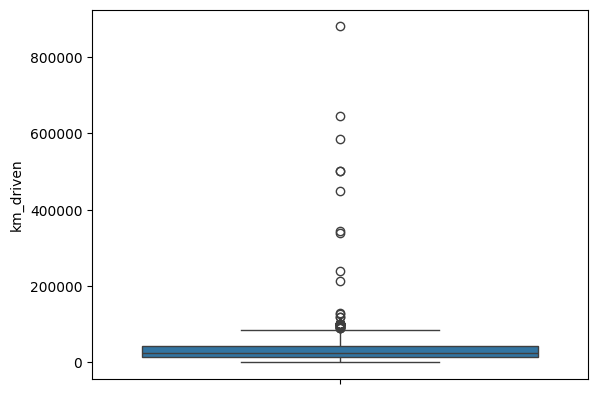

In [14]:
# 11. Identify and remove outliers in the km_driven column using the IQR method
sns.boxplot(df["km_driven"])
plt.show()

In [71]:
Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["km_driven"] >= Q1 - 1.5 * IQR) & (df["km_driven"] <= Q3 + 1.5 * IQR)]

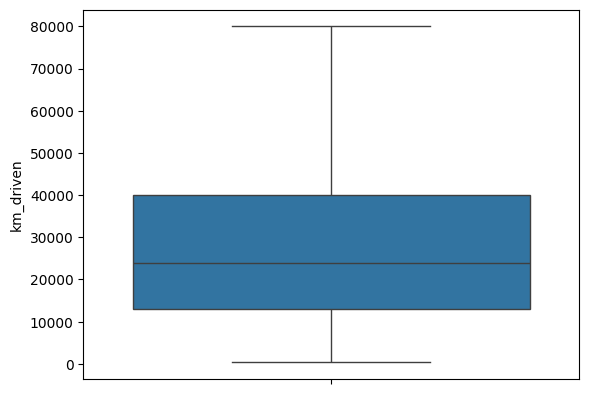

In [72]:
sns.boxplot(df["km_driven"])
plt.show()

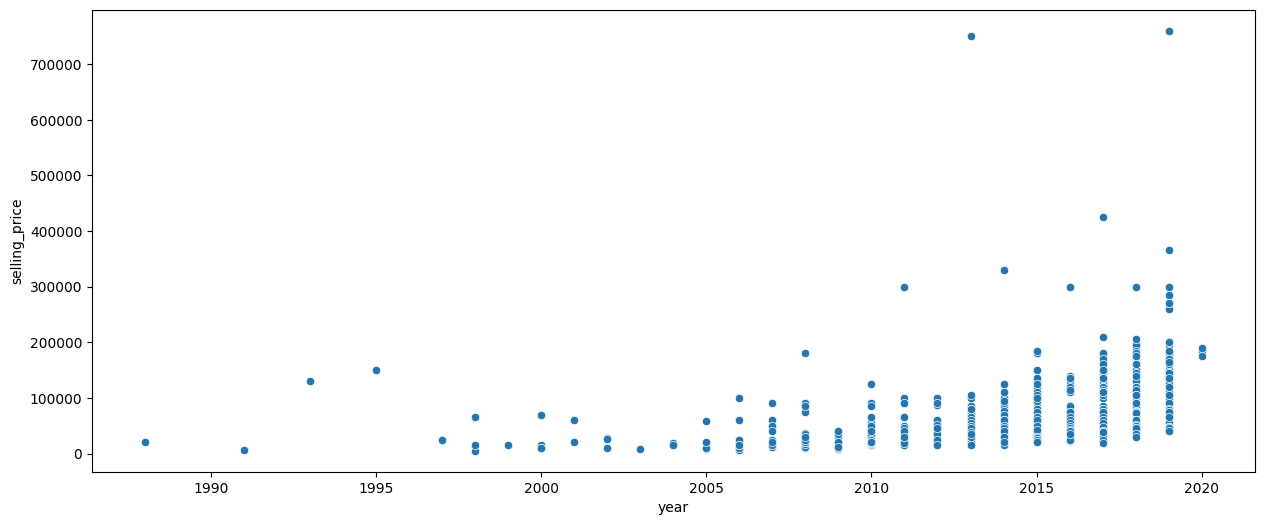

In [73]:
# 12. Perform a bivariate analysis to visualize the relationship between year and selling_price
plt.figure(figsize=(15, 6))
sns.scatterplot(x="year", y="selling_price", data=df)
plt.show()
# Year increases, selling_price increases

In [74]:
# 13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['year']
avg_depreciation = df.groupby('age')['selling_price'].mean().reset_index()

avg_depreciation

,age,selling_price
0,5,183333.333333
1,6,119689.511628
2,7,87660.374046
3,8,78962.121212
4,9,57924.126214
5,10,56313.131313
6,11,49121.348315
7,12,51802.816901
8,13,36720.619048
9,14,35859.631579


In [75]:
# 14. Which bike names are priced significantly above the average price for their manufacturing year?
df['year_avg'] = df.groupby('year')['selling_price'].transform('mean')
above_avg = df[df['selling_price'] > df['year_avg']]

above_avg["name"].unique()

array(['Royal Enfield Classic 350', 'Royal Enfield Classic Gunmetal Grey',
       'Yamaha Fazer FI V 2.0 [2016-2018]',
       'Royal Enfield Bullet 350 [2007-2011]', 'Yamaha YZF R3', 'Jawa 42',
       'Hero Honda Glamour', 'Yamaha YZF R15 S', 'Yamaha FZ25',
       'Jawa Standard', 'Royal Enfield Thunderbird 350', 'Honda CBR-250R',
       'Bajaj Dominar 400', 'KTM 390 Duke', 'Yamaha FZ16',
       'Royal Enfield Electra 5 S', 'Hero Honda Passion Plus',
       'Royal Enfield Bullet 350', 'Bajaj Pulsar 150 [2001-2011]',
       'Hero Xtreme Sports', 'Honda CB Hornet 160R',
       'Royal Enfield Electra 4 S', 'Mahindra Mojo XT300',
       'Bajaj Pulsar AS200', 'Royal Enfield Thunderbird 350X',
       'Suzuki Intruder 150', 'Hero Honda Karizma ZMR [2010]',
       'Honda CB Unicorn 150', 'Hero Honda CD Deluxe',
       'Royal Enfield Classic Desert Storm', 'TVS Apache RTR 200 4V',
       'UM Renegade Commando', 'Royal Enfield Continental GT 650',
       'Honda Activa 3G', 'Harley-Davidson Stree

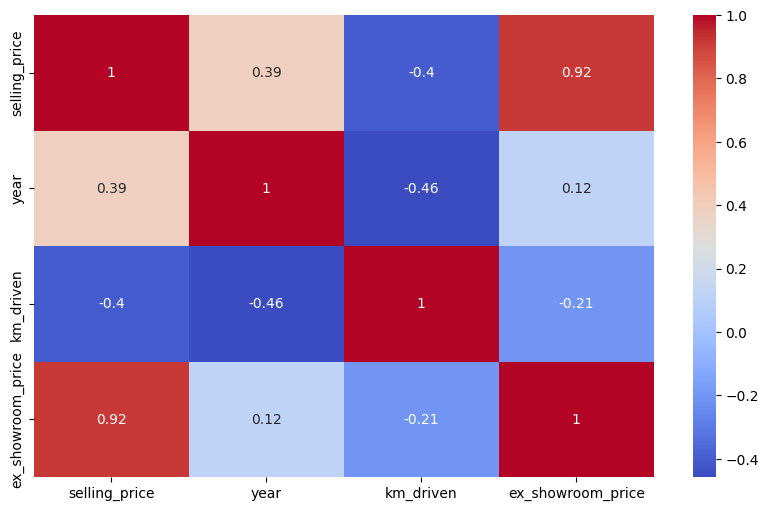

In [76]:
# 15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.
num_cols = ["selling_price", "year", "km_driven", "ex_showroom_price"]
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap = "coolwarm")
plt.show()

In [21]:
car_df = pd.read_csv("Car Sale.csv")
car_df.sample(5)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
14513,C_CND_014514,6/6/2023,Devin,Male,603500,Star Enterprises Inc,BMW,323i,DoubleÂ Overhead Camshaft,Auto,Black,9500,99301-3882,Hatchback,6807682,Pasco
14089,C_CND_014090,5/26/2023,Matheo,Male,800000,Capitol KIA,BMW,328i,Overhead Camshaft,Manual,Black,69001,38701-8047,Sedan,6523986,Middletown
16674,C_CND_016675,8/13/2023,Henny,Male,700000,Suburban Ford,Lincoln,Navigator,Overhead Camshaft,Manual,Pale White,33000,53546-9427,Sedan,8479738,Janesville
8125,C_CND_008126,11/14/2022,Magaly,Male,537000,Star Enterprises Inc,Ford,Taurus,Overhead Camshaft,Manual,Black,69000,99301-3882,SUV,8926444,Aurora
16917,C_CND_016918,8/22/2023,Lenaelle,Male,951000,Tri-State Mack Inc,Honda,Accord,Overhead Camshaft,Manual,Black,43001,85257-3102,Sedan,6234143,Scottsdale


In [22]:
# 1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?
avg_price = car_df.groupby("Dealer_Name")["Price ($)"].mean()
avg_price

,Price ($)
Dealer_Name,
Buddy Storbeck's Diesel Service Inc,27217.261563
C & M Motors Inc,28111.755200
Capitol KIA,28189.703822
Chrysler Plymouth,27555.526400
Chrysler of Tri-Cities,28123.091054
Classic Chevy,28602.014446
Clay Johnson Auto Sales,27816.027113
Diehl Motor CO Inc,27993.929487
Enterprise Rent A Car,28312.580800


In [23]:
# 2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?
brand_variation = car_df.groupby("Company")["Price ($)"].std()
brand_variation
# Brands have price variations between 8000 - 20000

,Price ($)
Company,
Acura,8183.046414
Audi,12904.243867
BMW,15065.578723
Buick,17142.232626
Cadillac,19517.120220
Chevrolet,13311.063223
Chrysler,11583.286811
Dodge,11187.592085
Ford,15849.090227


In [24]:
# 3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?
dist = car_df.groupby('Transmission')['Price ($)'].describe()
dist

,count,mean,std,min,25%,50%,75%,max
Transmission,,,,,,,,
Auto,12571.0,28248.525972,13747.070597,1200.0,19000.0,24000.0,35500.0,75700.0
Manual,11335.0,27914.710631,15862.871978,1700.0,17000.0,22001.0,34000.0,85800.0


In [25]:
iqr = car_df.groupby('Transmission')['Price ($)'].quantile(0.75) - \
      car_df.groupby('Transmission')['Price ($)'].quantile(0.25)
iqr = iqr.reset_index().rename(columns={0: 'IQR'})

iqr

,Transmission,Price ($)
0,Auto,16500.0
1,Manual,17000.0


In [26]:
# 4. What is the distribution of car prices across different regions?
dist_regions = car_df.groupby("Dealer_Region")["Price ($)"].describe()
dist_regions

,count,mean,std,min,25%,50%,75%,max
Dealer_Region,,,,,,,,
Aurora,3130.0,28334.626837,15026.207252,9000.0,18001.0,23000.0,35000.0,85800.0
Austin,4135.0,28341.603628,14903.884549,9000.0,18001.0,23801.0,35001.0,85601.0
Greenville,3128.0,28180.819054,15101.538328,1200.0,18001.0,22500.0,34500.0,85200.0
Janesville,3821.0,27833.350955,14344.995638,4300.0,18001.0,23000.0,34000.0,85400.0
Middletown,3128.0,27856.338875,14619.842395,1700.0,18000.0,22750.0,34000.0,85300.0
Pasco,3131.0,28119.039923,14659.315941,9000.0,18500.5,23000.0,34000.0,85600.0
Scottsdale,3433.0,27954.958928,14902.916820,1450.0,18000.0,22600.0,33500.0,85001.0


In [27]:
# 5. What is the distribution of cars based on body styles?
body_styles = car_df["Body Style"].value_counts()
body_styles

,count
Body Style,
SUV,6374
Hatchback,6128
Sedan,4488
Passenger,3945
Hardtop,2971


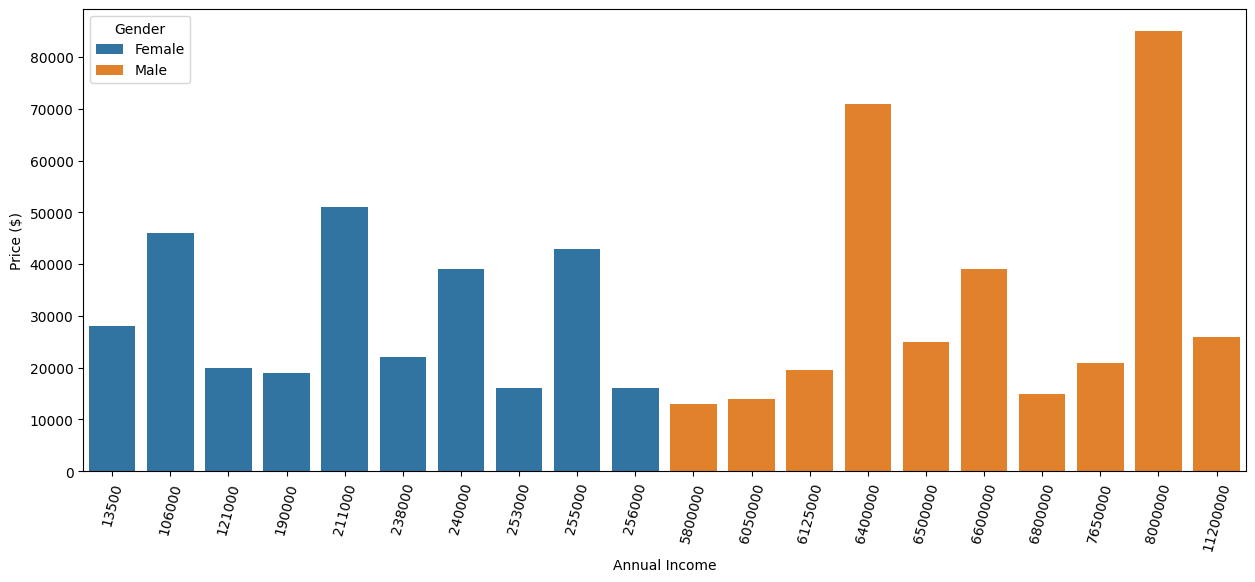

In [28]:
# 6. How does the average selling price of cars vary by customer gender and annual income?
avg_gender_price = car_df.groupby(['Gender', 'Annual Income'])['Price ($)'].mean().reset_index()
both_genders = pd.concat([avg_gender_price[:10], avg_gender_price[-10:]], axis=0).reset_index(drop=True)

plt.figure(figsize=(15, 6))
sns.barplot(data=both_genders, x='Annual Income', y='Price ($)', hue='Gender')
plt.xticks(rotation = 75)
plt.show()
# Female spends more money on car while having less income
# Male spends less money on car while having more income

In [29]:
# 7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?
dist_regions = car_df.groupby("Dealer_Region")["Price ($)"].describe()
dist_regions

,count,mean,std,min,25%,50%,75%,max
Dealer_Region,,,,,,,,
Aurora,3130.0,28334.626837,15026.207252,9000.0,18001.0,23000.0,35000.0,85800.0
Austin,4135.0,28341.603628,14903.884549,9000.0,18001.0,23801.0,35001.0,85601.0
Greenville,3128.0,28180.819054,15101.538328,1200.0,18001.0,22500.0,34500.0,85200.0
Janesville,3821.0,27833.350955,14344.995638,4300.0,18001.0,23000.0,34000.0,85400.0
Middletown,3128.0,27856.338875,14619.842395,1700.0,18000.0,22750.0,34000.0,85300.0
Pasco,3131.0,28119.039923,14659.315941,9000.0,18500.5,23000.0,34000.0,85600.0
Scottsdale,3433.0,27954.958928,14902.916820,1450.0,18000.0,22600.0,33500.0,85001.0


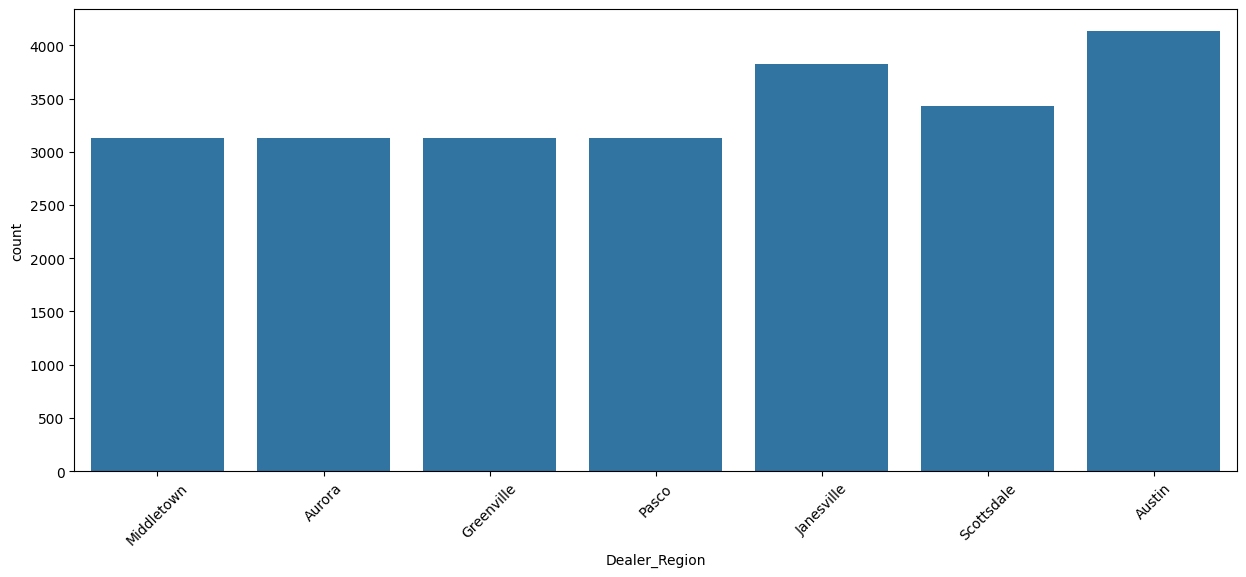

In [30]:
dist_regions_var = car_df["Dealer_Region"].value_counts().reset_index()
plt.figure(figsize=(15, 6))
sns.countplot(data=car_df, x='Dealer_Region')
plt.xticks(rotation = 45)
plt.show()

In [31]:
# 8. How does the average car price differ between cars with different engine sizes?
avg_engine_price = car_df.groupby('Engine')['Price ($)'].mean().reset_index()
avg_engine_price

,Engine,Price ($)
0,DoubleÂ Overhead Camshaft,28248.525972
1,Overhead Camshaft,27914.710631


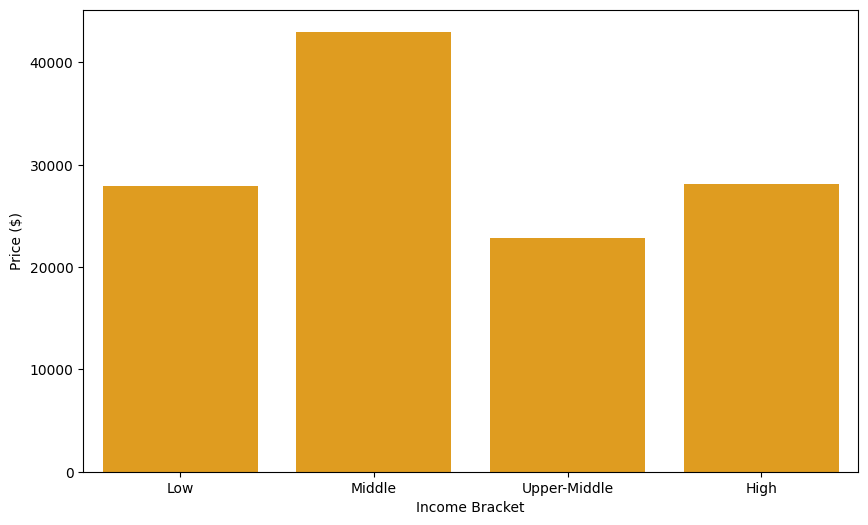

In [32]:
# 9. How do car prices vary based on the customer’s annual income bracket?
car_df['Income Bracket'] = pd.cut(
    car_df['Annual Income'],
    # bins=[0, 30000, 60000, 100000, 200000, float('inf')],
    # labels=['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']
    bins=[0, 60000, 100000, 200000, float('inf')],
    labels=['Low', 'Middle', 'Upper-Middle', 'High']
)

avg_price_by_bracket = (
    car_df.groupby('Income Bracket')['Price ($)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price_by_bracket, x="Income Bracket", y="Price ($)", color = "orange")
plt.show()

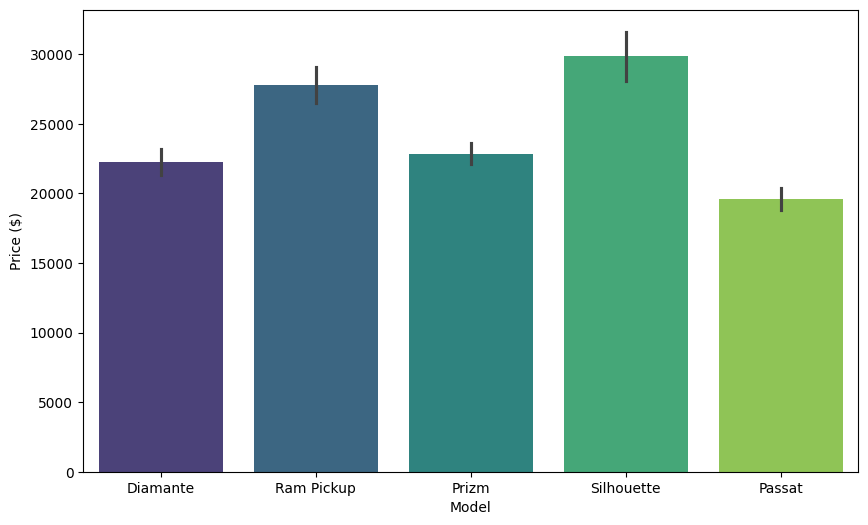

In [33]:
# 10. What are the top 5 car models with the highest number of sales, and how does their price distribution look?
top_models = car_df['Model'].value_counts().sort_values().tail(5).reset_index()
top5_df = car_df[car_df['Model'].isin(top_models["Model"])]
plt.figure(figsize=(10, 6))
sns.barplot(data=top5_df, x="Model", y="Price ($)", palette = "viridis")
plt.show()

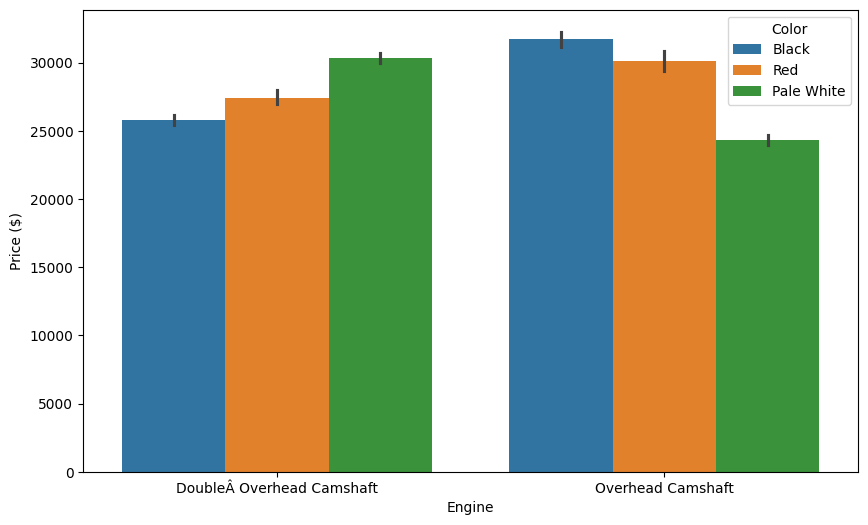

In [34]:
# 11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?
plt.figure(figsize=(10, 6))
sns.barplot(data=car_df, x="Engine", y="Price ($)", hue="Color")
plt.show()

In [35]:
# 12. Is there any seasonal trend in car sales based on the date of sale?
car_df["Date"] = pd.to_datetime(car_df["Date"])
car_df["Month_Year"] = car_df["Date"].dt.to_period("M")

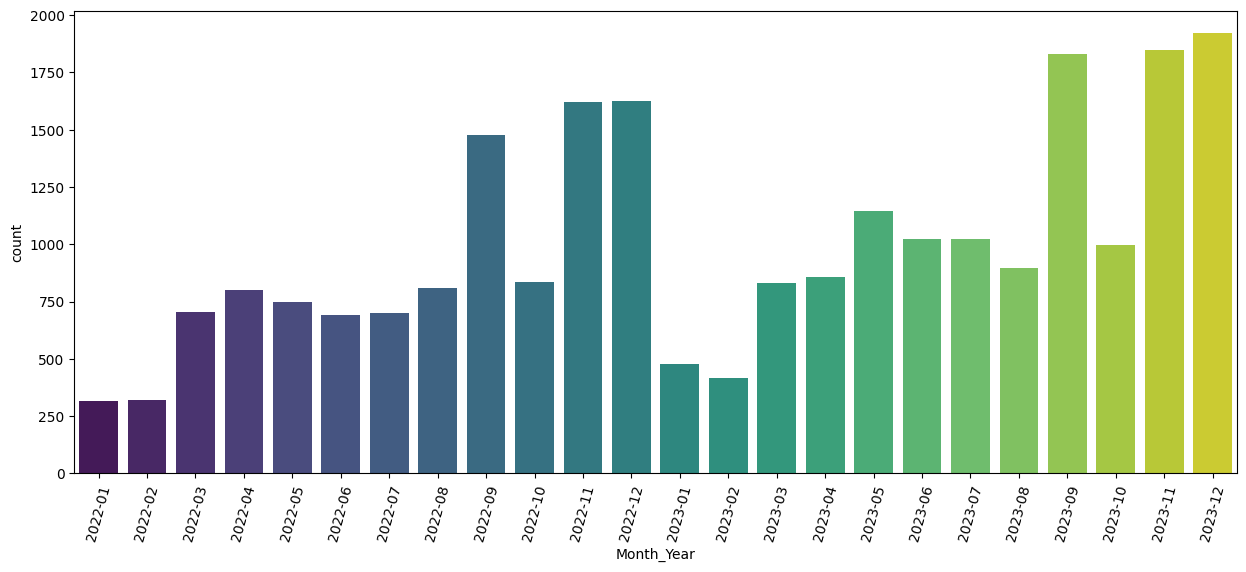

In [36]:
plt.figure(figsize=(15, 6))
sns.countplot(data=car_df, x="Month_Year", palette = "viridis")
plt.xticks(rotation = 75)
plt.show()

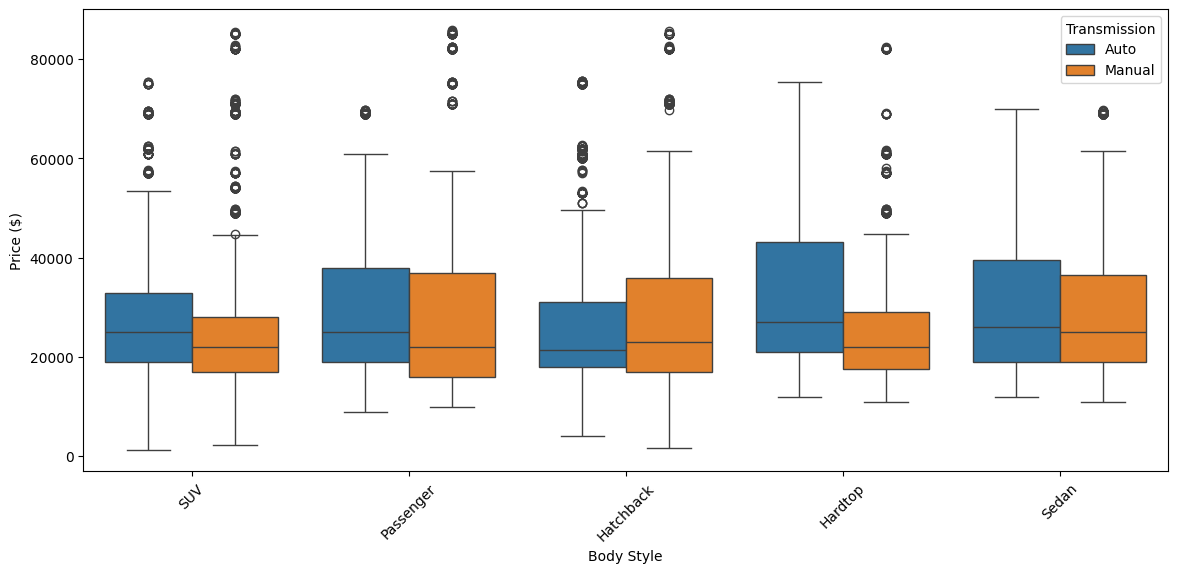

In [37]:
# 13. How does the car price distribution change when considering different combinations of body style and transmission type?
plt.figure(figsize=(14,6))
sns.boxplot(data=car_df, x="Body Style", y="Price ($)", hue="Transmission")

plt.xticks(rotation=45)
plt.show()

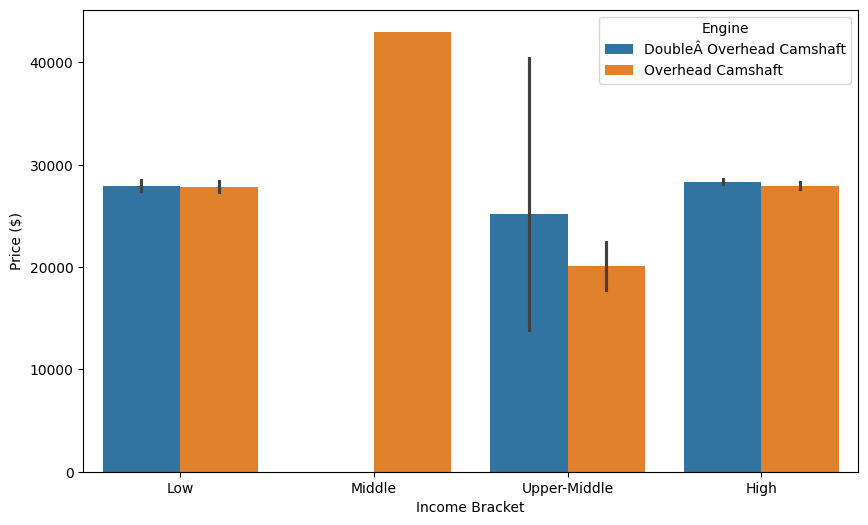

In [38]:
# 14.  What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?
# engine_encode = car_df["Engine"].map({"DoubleÂ\xa0Overhead Camshaft":0, "Overhead Camshaft":1})
# engine_encode
plt.figure(figsize=(10, 6))
sns.barplot(data=car_df, x="Income Bracket", y="Price ($)", hue = "Engine")
plt.show()

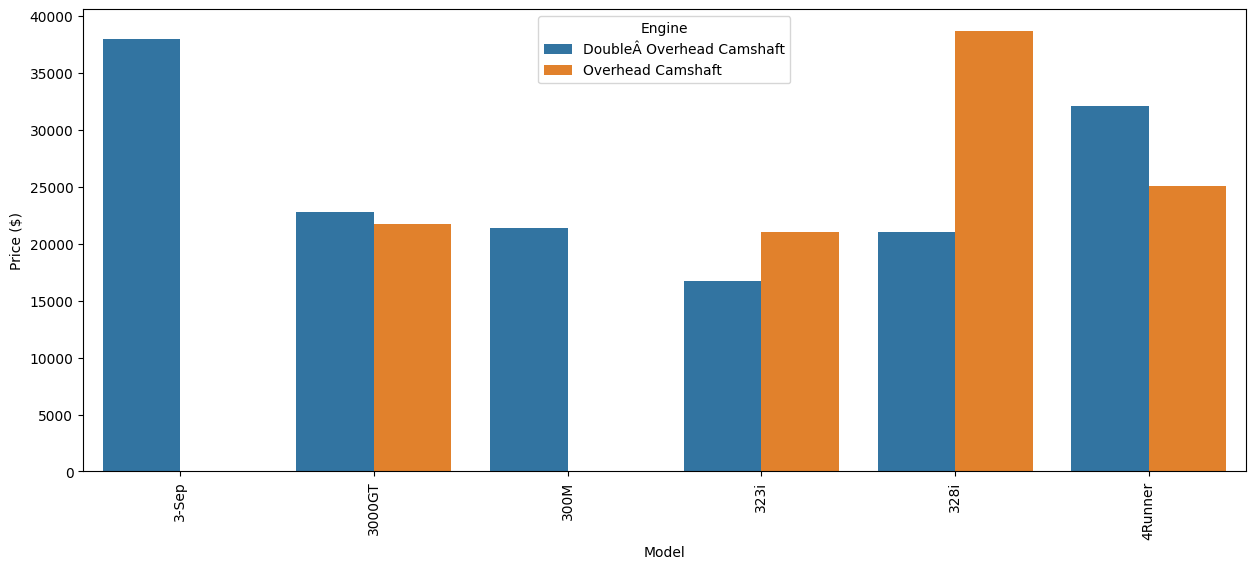

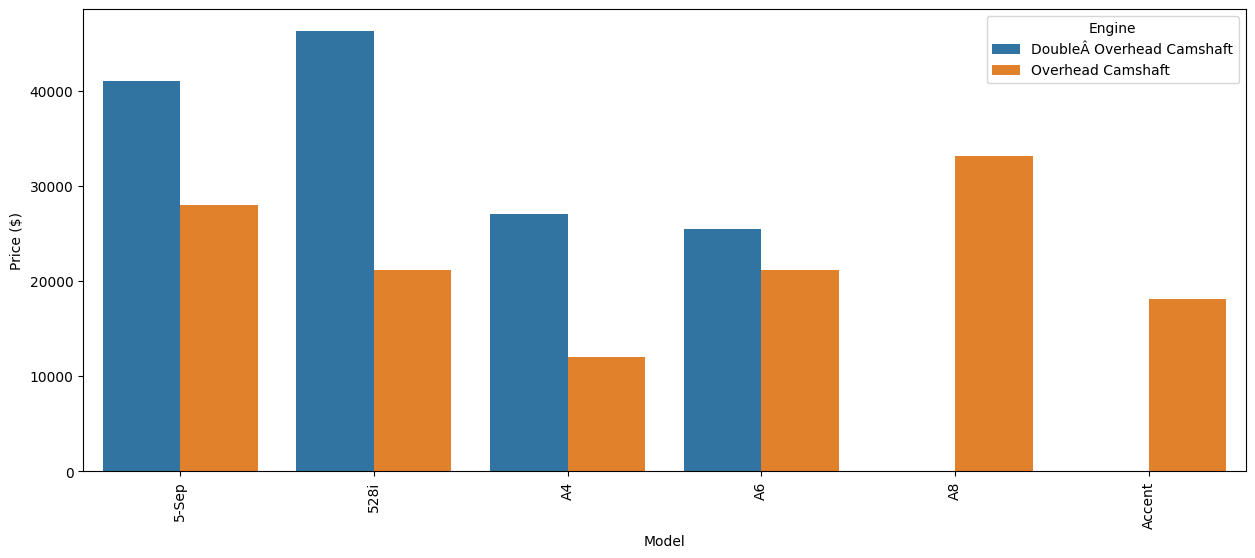

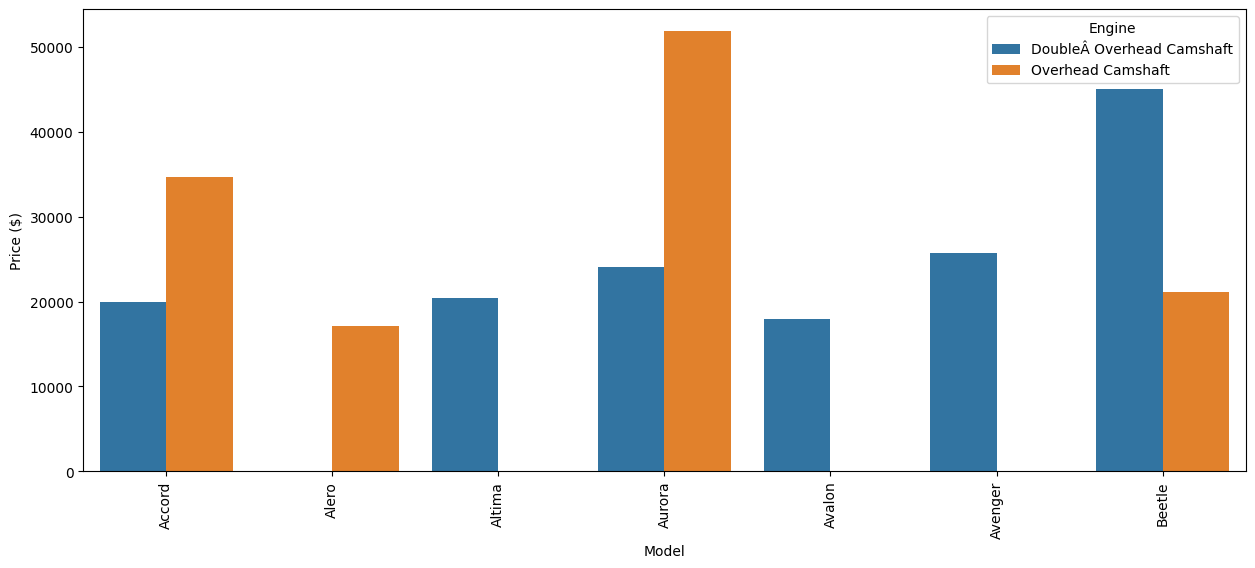

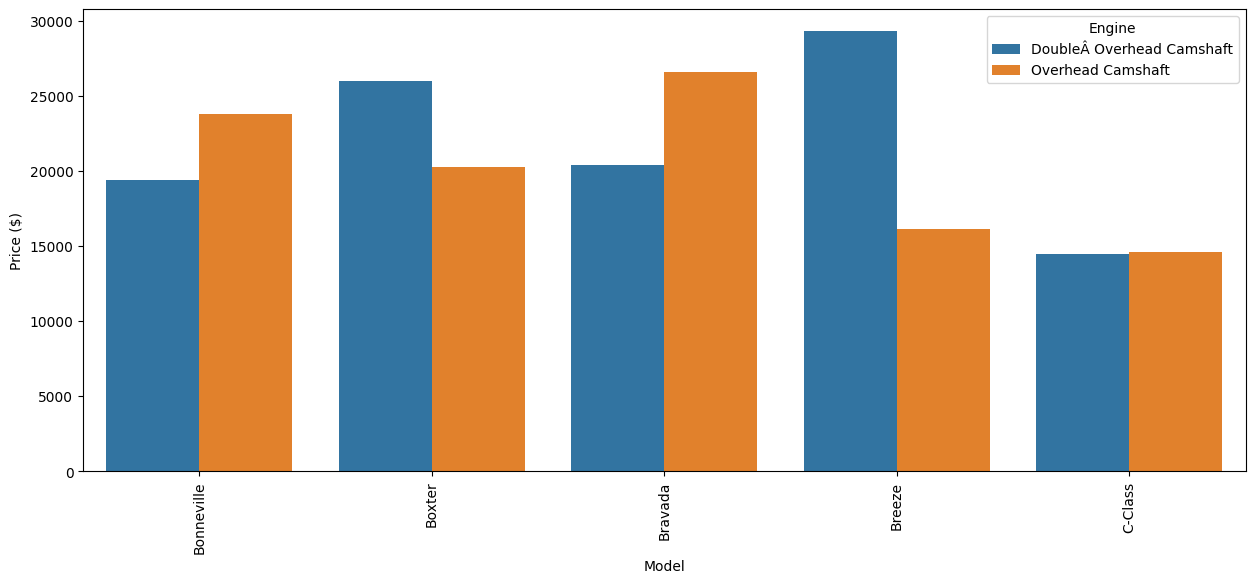

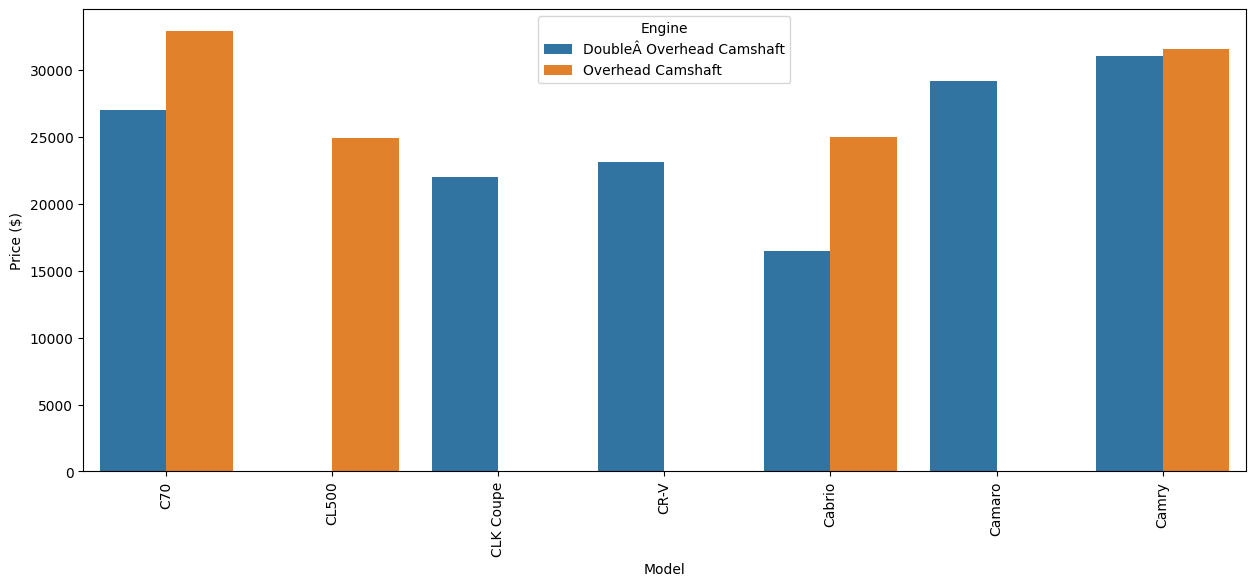

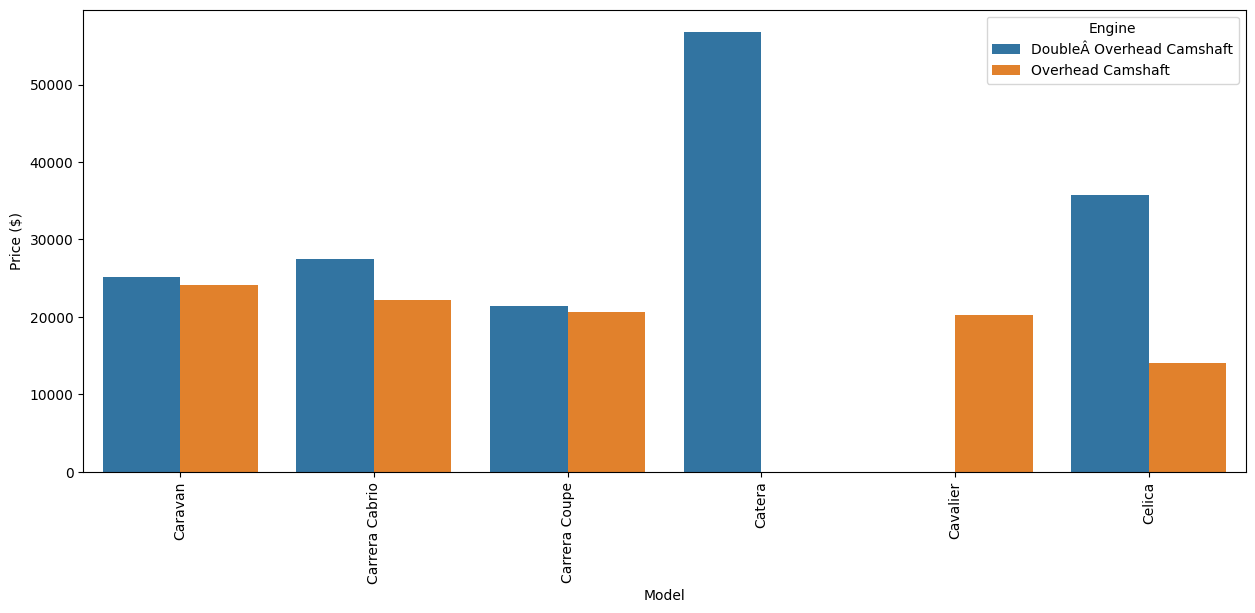

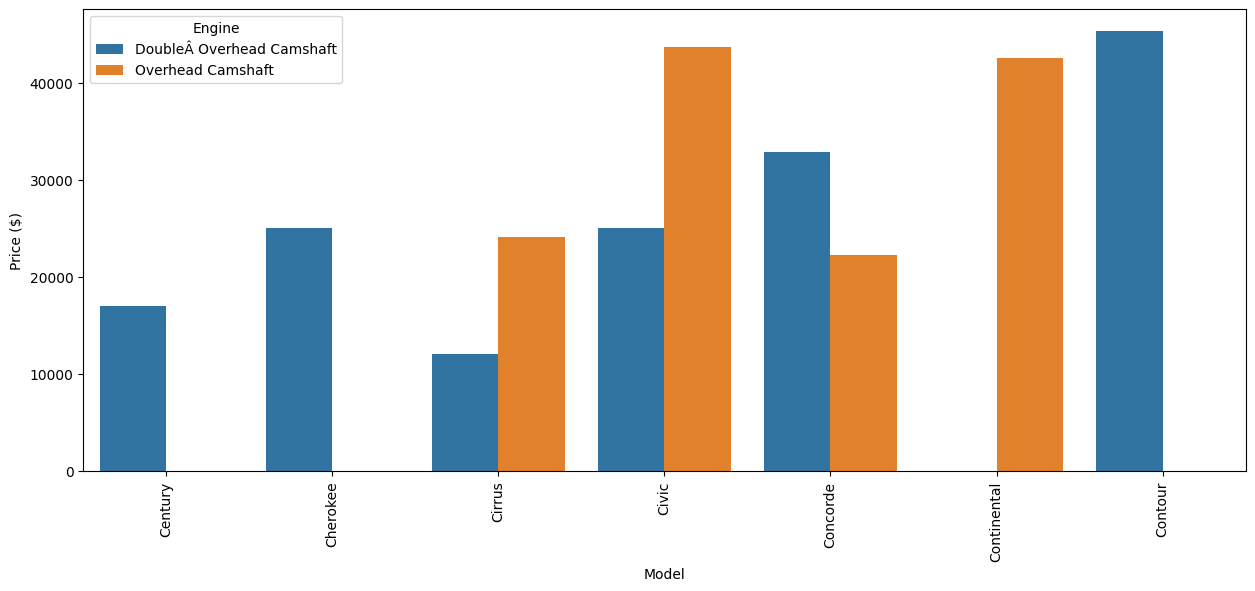

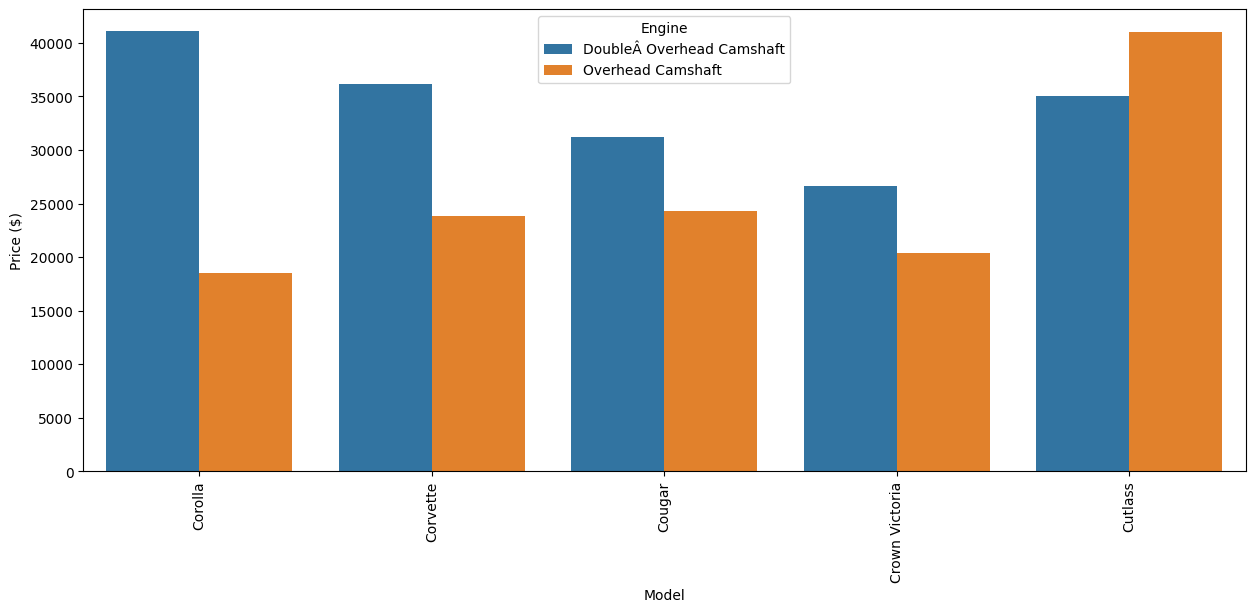

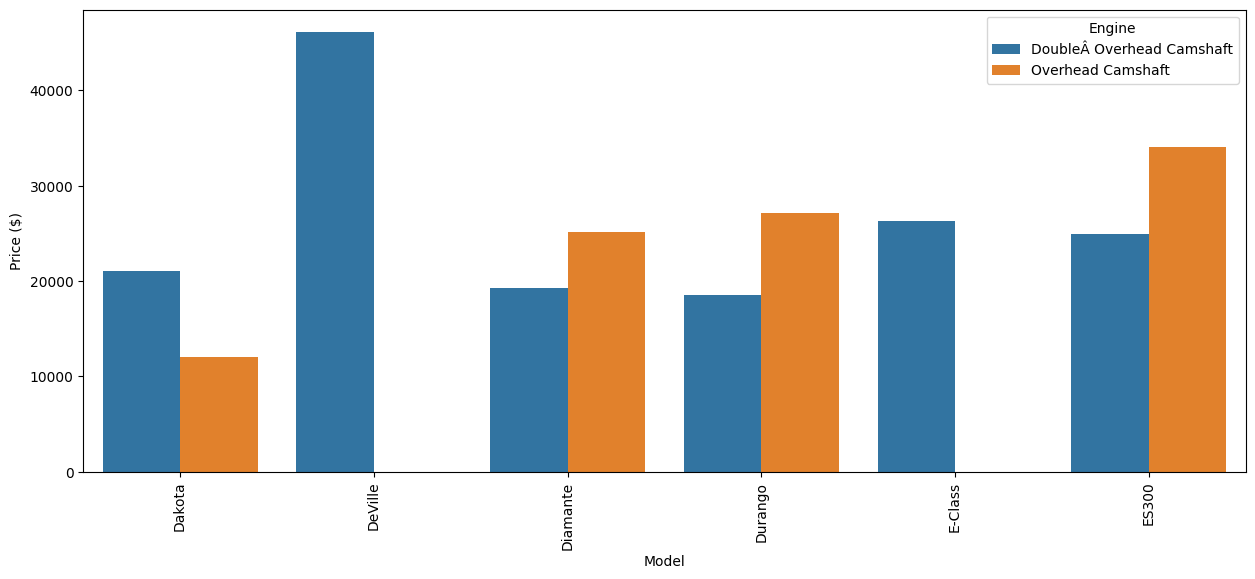

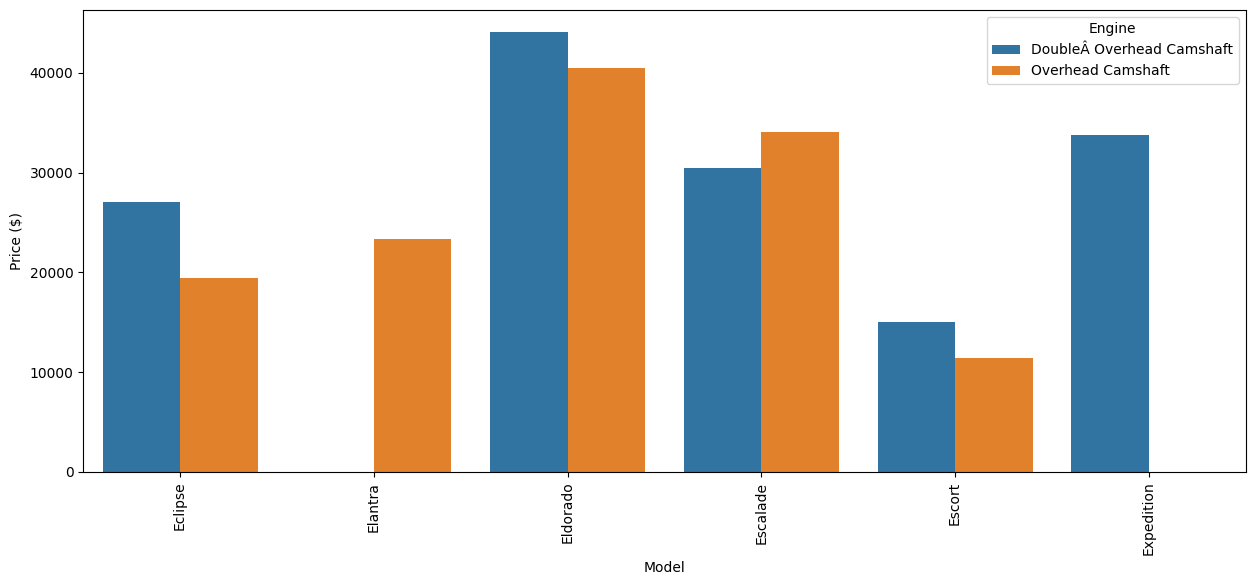

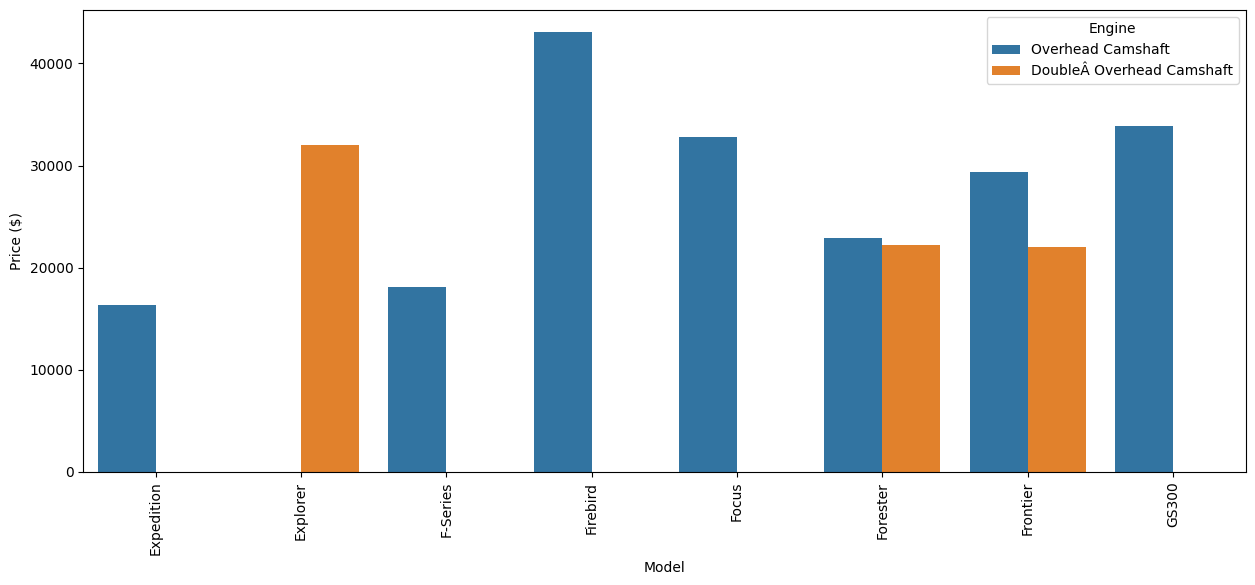

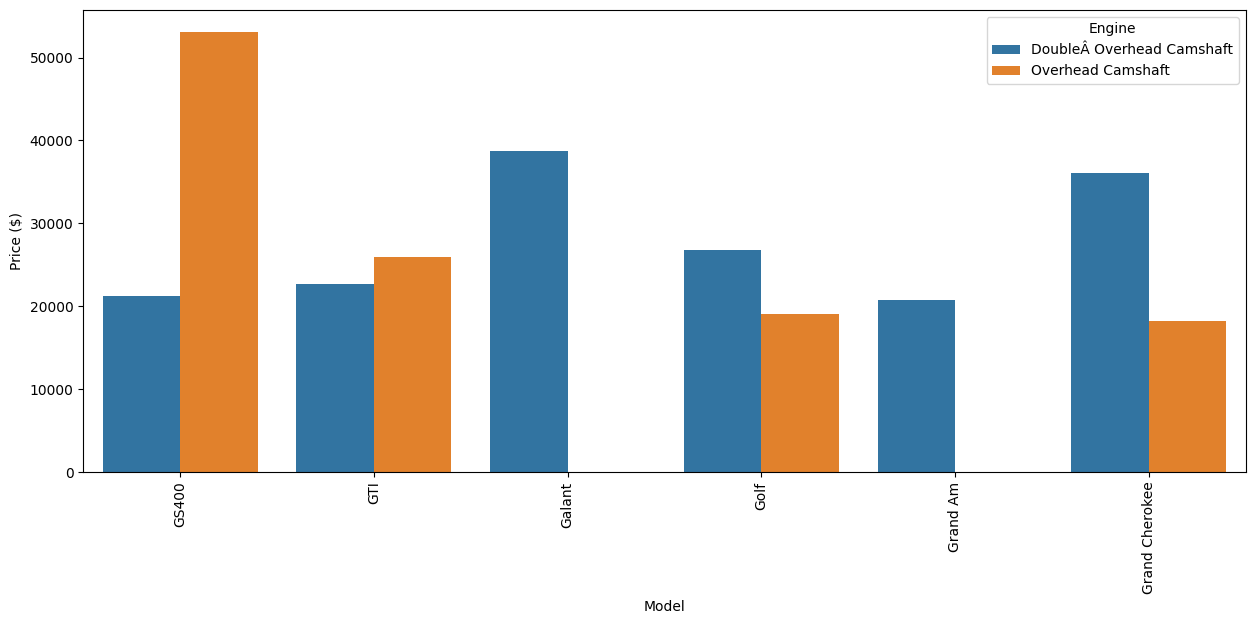

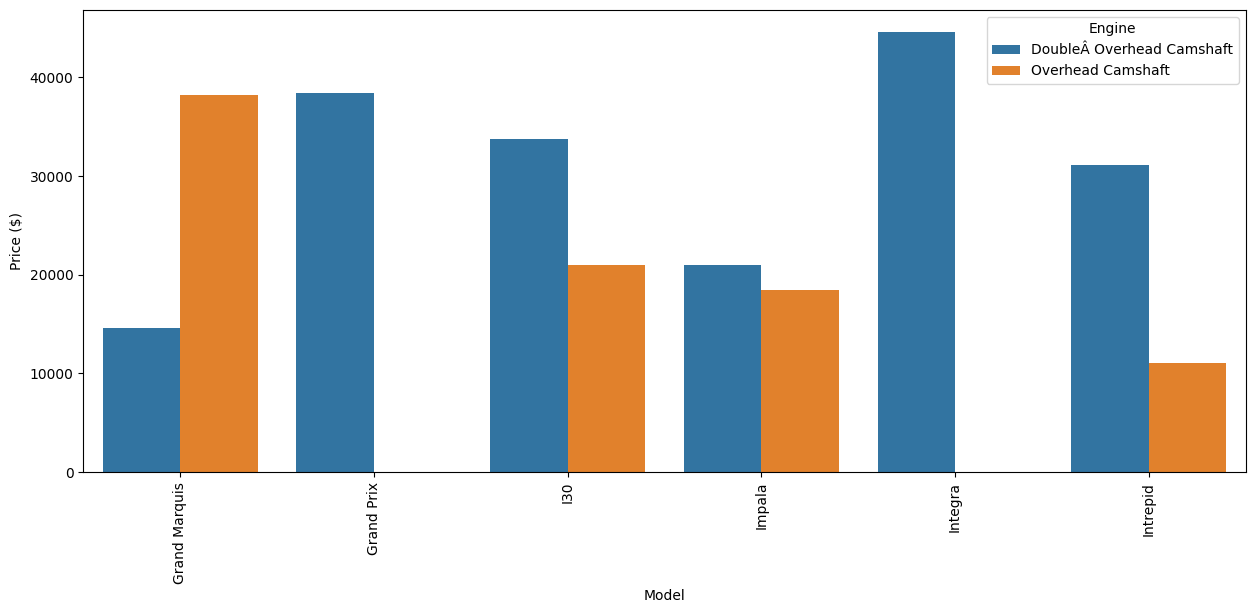

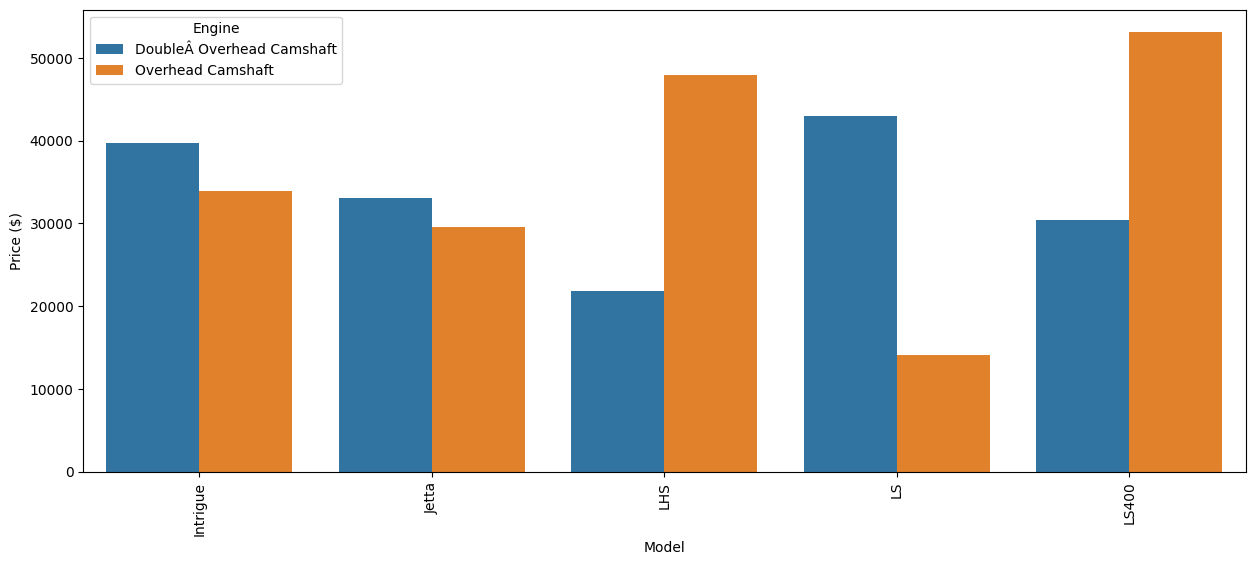

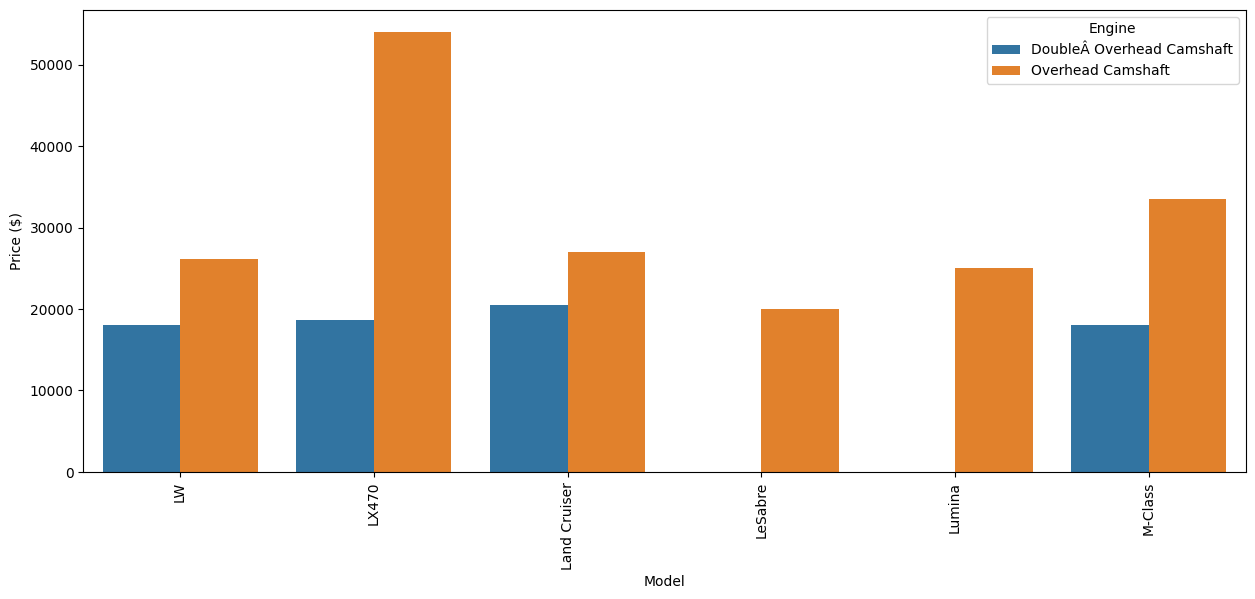

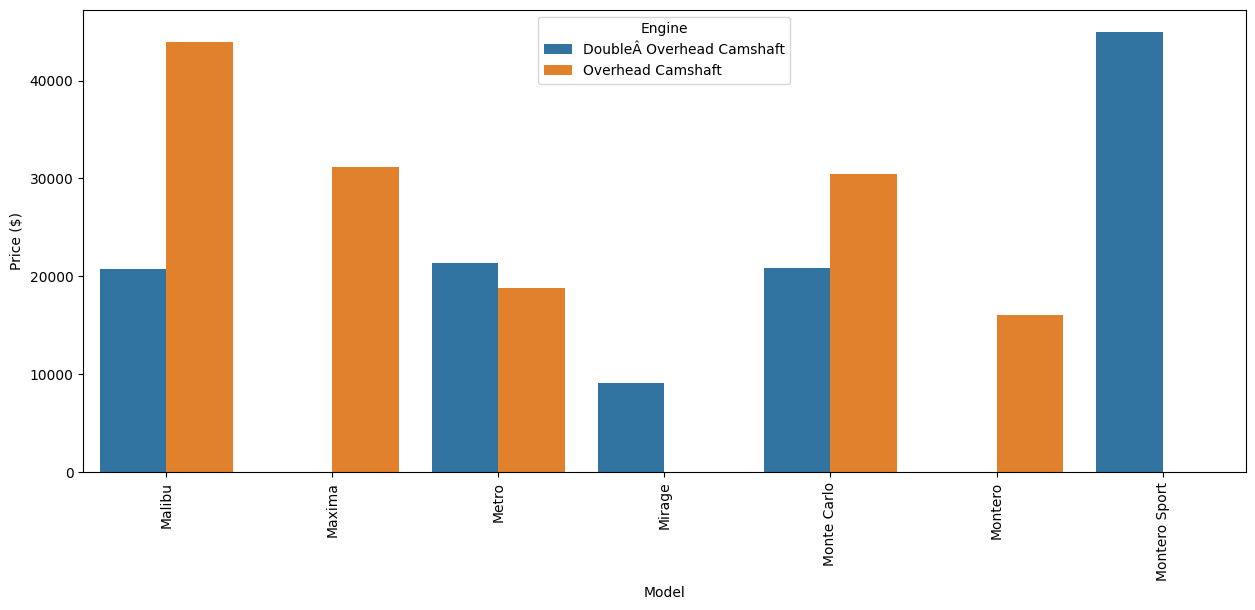

In [39]:
# 15. How does the average car price vary across different car models and engine types?
avg_price = (
    car_df.groupby(["Model", "Engine"])["Price ($)"]
    .mean()
    .reset_index()
)

for i in range(int(len( avg_price ) / 16 ) ):
  plt.figure(figsize=(15, 6))
  sns.barplot(data=avg_price[i*10:i*10+10], x="Model", y="Price ($)", hue = "Engine")
  plt.xticks(rotation = 90)
  plt.show()

In [40]:
sales_df = pd.read_csv("amazon.csv")
sales_df.sample(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
642,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹149,"₹1,000",85%,3.9,"24,870",Fast Charging & Data Sync: Solero TB301 Type-C...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...","It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",https://m.media-amazon.com/images/I/31wOPjcSxl...,https://www.amazon.in/Solero-TB301-Charging-48...
871,B07H8W9PB6,KLAM LCD Writing Tablet Screenwriting Toys Boa...,Computers&Accessories|Accessories&Peripherals|...,₹175,₹499,65%,4.1,21,Eye Protection: This Writing tablet easy viewi...,"AF63ZFTFFODG7SUOLW4HXHDUQPSA,AHCXNGYHWBSZ6FJZP...","🤘🏻🤘🏻,Kabi,Manoj kumar ware,om,Hemant Kumar,paw...","R2JX4PS0VEXLP8,R2Z993M5W7NJG7,R3IGL48GSRQXBK,R...","Fine🤘🏻🙏🏻,Good,Best for kids,Easy clean and use...",A little slippery to write but ok and after wr...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Writing-Screenwriting-Di...
1295,B07ZJND9B9,ACTIVA 1200 MM HIGH SPEED 390 RPM BEE APPROVED...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|C...","₹1,099","₹1,990",45%,3.9,"5,911","Box Contains: Fan Motor, Blade Set, Canopy Set...","AFCLVEPUPFSZU5KJMDBYKGARGQBQ,AEC4ACDLYBYYFG247...","Ravi,Pasala Eswararao,Verified User,Azarudeen,...","R1SWHPJDUW2G3M,R2RFQJDQF5BT8,RPGTYXQGC3TXI,R3T...","Decently priced fan,Power saving fan low super...","A good fan. Very sad no regulator, and had to ...",https://m.media-amazon.com/images/I/31hXo964hq...,https://www.amazon.in/ACTIVA-APSRA-Approved-Ce...
550,B0B82YGCF6,Tokdis MX-1 Pro Bluetooth Calling Smartwatch -...,Electronics|WearableTechnology|SmartWatches,₹899,"₹3,499",74%,3.0,681,【Bluetooth Calling Watch】- Tokdis MX-1 Pro ena...,"AFEMYJODFSKRPR4XTYKCPXMCO4YA,AH7PGDCSET6C5NOBB...","Gourav Choudhrani,Mustak ali,Amit,Pankaj solan...","RGEDIZCX7LB34,R19GGFEAAXAUKK,R3L3EFRRM8X2IY,RE...","Its is good but battery life is very poor,Hear...","Its is value for money,,Good product,Good, lik...",https://m.media-amazon.com/images/I/31M4nb0+JK...,https://www.amazon.in/Tokdis-MX-1-Bluetooth-Ca...
1228,B07W4HTS8Q,ACTIVA Instant 3 LTR 3 KVA SPECIAL Anti Rust C...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...","₹1,899","₹3,790",50%,3.8,"3,842",Manufactured under the guidance of highly qual...,"AH4ZZLZF5JO74MJ3E6WURPHAOKVA,AE4IRBIAL6D4FWUJD...","Gajendra Kumar sharma,Gagan,Lavi,Priyesh,Suket...","R371P01X49V8QV,R3MMP5A1MKKZZP,R1VI6TV1VNY0H6,R...","Value for money,Goods,Pipe is not dilevered wi...","Value for money,Like,Okk,Product is good but w...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/ACTIVA-Instant-SPCEIAL-W...


In [41]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [42]:
# 1. What is the average rating for each product category?
sales_df["rating"] = sales_df["rating"].str.replace("|", str(np.nan))
sales_df["rating"] = pd.to_numeric(sales_df["rating"], errors="coerce")
sales_df["rating"].fillna(sales_df["rating"].median(), inplace=True)
sales_df["rating"].unique()

array([4.2, 4. , 3.9, 4.1, 4.3, 4.4, 4.5, 3.7, 3.3, 3.6, 3.4, 3.8, 3.5,
       4.6, 3.2, 5. , 4.7, 3. , 2.8, 3.1, 4.8, 2.3, 2. , 2.6, 2.9])

In [43]:
avg_rating = sales_df.groupby("category")["rating"].mean()
round(avg_rating, 2)

,rating
category,
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,3.80
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,4.15
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,3.50
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,3.60
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,4.05
...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens",4.25
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens",4.15
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens",4.30


In [44]:
# 2. What are the top rating_count products by category?
top_rating_count = sales_df.groupby("category")["rating_count"].idxmax()
top_rating_count

,rating_count
category,
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,1157
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,695
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,906
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,772
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,844
...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens",616
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens",993
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens",765


In [45]:
# 3. What is the distribution of discounted prices vs. actual prices?
sales_df["actual_price"] = sales_df["actual_price"].replace({"₹":"", ",":""}, regex=True)
sales_df["discounted_price"] = sales_df["discounted_price"].replace({"₹":"", ",":""}, regex=True)
sales_df["actual_price"] = pd.to_numeric(sales_df["actual_price"])
sales_df["discounted_price"] = pd.to_numeric(sales_df["discounted_price"])

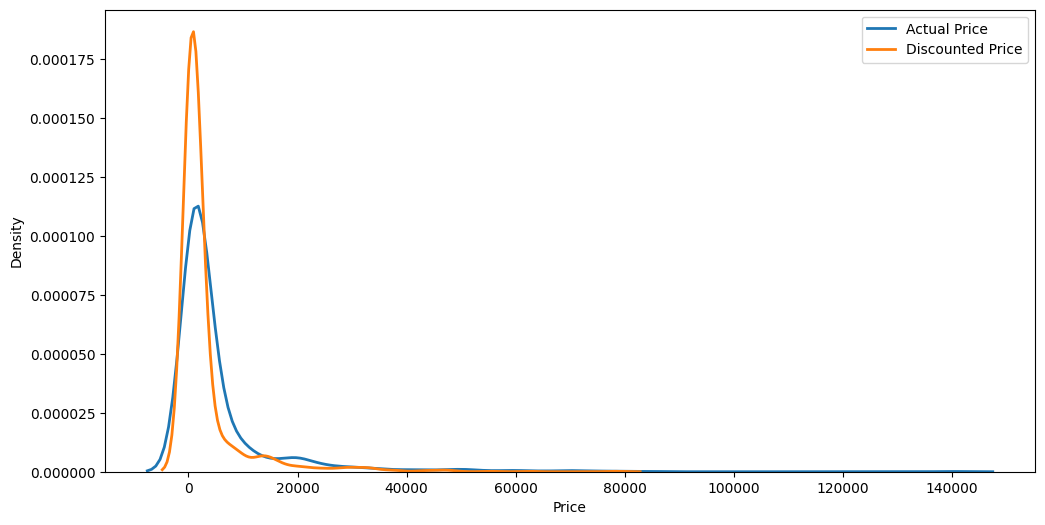

In [46]:
plt.figure(figsize=(12, 6))
sns.kdeplot(sales_df["actual_price"], label="Actual Price", linewidth=2)
sns.kdeplot(sales_df["discounted_price"], label="Discounted Price", linewidth=2)
plt.xlabel("Price")
plt.legend()
plt.show()

In [47]:
# 4. How does the average discount percentage vary across categories?
sales_df["discount_percentage"] = sales_df["discount_percentage"].str.replace("%", "")
sales_df["discount_percentage"] = pd.to_numeric(sales_df["discount_percentage"])

In [48]:
sales_df.groupby("category")["discount_percentage"].mean()

,discount_percentage
category,
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers,42.0
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters,78.5
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets,35.0
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones,56.5
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers,46.5
...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens",0.0
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidInkRollerballPens",5.0
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|RetractableBallpointPens",17.5


In [49]:
# 5. What are the most popular product names?
sales_df["product_name"].value_counts().sort_values(ascending=False).head(10)

,count
product_name,
"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution",5
"Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3"",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating",4
"Ambrane 60W / 3A Fast Charging Output Cable with Type-C to USB for Mobile, Neckband, True Wireless Earphone Charging, 480mbps Data Sync Speed, 1m Length (ACT - AZ10, Black)",3
"Duracell USB C To Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black",3
"Fire-Boltt India's No 1 Smartwatch Brand Talk 2 Bluetooth Calling Smartwatch with Dual Button, Hands On Voice Assistance, 60 Sports Modes, in Built Mic & Speaker with IP68 Rating",3
"AmazonBasics New Release Nylon USB-A to Lightning Cable Cord, Fast Charging MFi Certified Charger for Apple iPhone, iPad (6-Ft, Rose Gold)",3
"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, Laptops & other Type C devices, PD Technology, 480Mbps Data Sync, Quick Charge 3.0 (RCT15A, Black)",3
"Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13, 12,11, X, 8, 7, 6, 5, iPad Air, Pro, Mini (3 FT Pack of 1, Grey)",3
"Amazon Basics USB Type-C to USB-A 2.0 Male Fast Charging Cable for Laptop - 3 Feet (0.9 Meters), Black",3


In [50]:
# 6. What are the most popular product keywords
sales_df["about_product"].value_counts().sort_values(ascending=False).head(10)

,count
about_product,
"[CHARGE & SYNC FUNCTION]- This cable comes with charging & Data sync function|[HIGH QUALITY MATERIAL]- TPE + Nylon Material to make sure that the life of the cable is enhanced significantly|[LONG CORD]- The Cable is extra thick 1.2 meter long, optimized for an easy use for your comfort at home or office|[MORE DURABLE]-This cable is unique interms of design and multi-use and is positioned to provide the best comfort and performance while using|[UNIVERSAL COMPATIBILITY]- Compatible with all devices like iPhone XS, X, XR, 8, 7, 6S, 6, 5S, iPad Pro, iPad mini and iPad Air",6
"Bluetooth Calling- Wave Call comes with a premium built-in speaker and bluetooth calling via which you can stay connected to your friends, family, and colleagues|Dial Pad- Its dial pad is super responsive and convenient. You can also save upto 10 contacts in this smart watch|Screen Size- Wave Call comes with a 1.69” HD Display that features a bold, bright, and highly responsive 2.5D curved touch interface|Resolution- With 550 nits of brightness get sharper color resolution that brightens your virtual world exponentially.|Design- The ultra slim and lightweight design of the watch is ideal to keep you surfing your wave all day!|Watch Faces- Wave Call comes with 150+ Cloud watchfaces for you to pick from, complementing your every mood and outfit|HR, SpO2 & Breathing- Monitor your heart rate and blood oxygen levels on-the-go with the heart rate and SpO2 monitor. It also comes with Guided Breathing to help you relax and embrace mindfulness.",5
Added Protection: An additional layer of protection has been added to the Lightning and USB ends to improve durability and reduce fraying;,5
"Fast Charging Cable - The cable can support upto a charging speed of 3A making it the optimal cable for Quick Charge / Rapid Charge and Turbo Charge devices.|Reversible Connector – It has reversible type c connector that can be plugged in any direction, upside or downside.|Durable Cable- Using only premium quality materials and a tough, durable PVC Coating, the Ambrane USB cable is built for connecting and disconnecting over and over again without signal loss.|High Speed Data Transfer- 480 Mbps data transfer speed allows you to sync the data to the computer or other USB devices within few seconds.|Genuine USB Connectors- We use only certified and high-quality connectors ensuring not only the safety of the connected device but also reliable charging and high-speed data transmission.",4
"Screen Size: The 1.69 inch HD full touch display with 500 nits of brightness will bring every detail to life!|Resolution: Get sharper color resolution that brightens your virtual world exponentially.|Slim Design: The ultra slim and lightweight design of the watch is ideal to keep you surfing your wave all day!|Sports Modes: Track your daily activity: calories burnt & steps taken. Choose from multiple sports modes which include Walking, Running, Cycling, Climbing, Yoga, Basketball, Football & many more|Google Fit & Apple Health: The watch supports Google and Apple Fit to seamlessly monitor your health.|IP Rating: Sweat freely while you work out with IP68 dust, sweat and splash resistance.|Watch Faces- Customize your style with 140+ based watch faces.",4
"Alexa- Alexa built-in Voice Assistant that sets reminders, alarms and answers questions from weather forecasts to live cricket scores at your command!|Screen Size- ;1.69"" big square colour LCD display with a round dial features complete capacitive touch experience to let you take control, effortlessly.|Watch Faces- Multiple watch faces with customizable options to match your OOTD, every day!|Brightness- The ambient light display allows automatic adjustment of brightness on the watch, suited to your environment|HR & SpO2- The watch comes with a stress monitor that reads your HR to indicate stress levels.It also monitors your heart rate and SpO2 (blood oxygen levels) to keep a tab on your overall health.|Sleep Monitor- Track all stag

In [51]:
# 7. What are the most popular product reviews?
sales_df["review_title"].value_counts().sort_values(ascending=False).head(10)

,count
review_title,
"Worked on iPhone 7 and didn’t work on XR,Good one,Dull Physical Looks,Just Buy it,Go for it,About the product,Get charging cable at the price,Working well.",10
"Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good Product,As of now seems good",8
"Phone, camera, heating - works for me, may not for all,Good Mobile,Good but not excellent under this budget,Worth the price at 9499,Ok type phone... but unable to make videocall within same service provider.,Phone review,Budget king,Battery backup is good",8
"A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Good quality,Good product,its good,Good quality for the price but one issue with my unit",7
"Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but could be better,Very nice it's charging like jet",7
"Fake Product,Costly but excellent quality,Storage good but don't know how to Activate warantee??,Good for use,5 stas nahi diya kyuki capacity 477gb hi rahta hai,Speed not as advertise,Good one,It's ok",6
"Above average phone,Worth For The Money 💰,Okie,Phone is excellent,Purchased in good budget at 12k,It can fulfill basic needs in affordable price range,Nice,About features",6
"The metal pin is losing it's strength,Sahi h bs 44 rupe ki and dilivery charge 40,Good Charging cable,Good sturdy micro usb cable with good charging speeds,Cheapest micro USB cable in the market,boat is better than this,I bought this for 199rs best charging cable for all mobiles,Good",5
"Wonderful TV and Awful installation service from amazon,Acer Television Review,It's a good product for that price.,Good for the price,Almost a complete package,Nice Product,Good product,Super designed",5


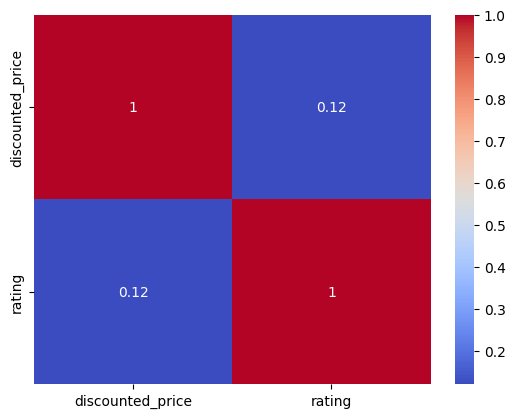

In [52]:
# 8. What is the correlation between discounted_price and rating
sns.heatmap(sales_df[["discounted_price", "rating"]].corr(), annot=True, cmap = "coolwarm")
plt.show()

In [53]:
# 9. What are the Top 5 categories based on the highest ratings?
top_ratings = sales_df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)
top_ratings

,rating
category,
Computers&Accessories|Tablets,4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters,4.5
Electronics|Cameras&Photography|Accessories|Film,4.5
Computers&Accessories|Components|Memory,4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients,4.5


In [54]:
# 10. Identify any potential areas for improvement or optimization based on the data analysis.
# I dont see any missing values, duplicate values and already converted numerical columns from object to number.

In [55]:
spotify_df = pd.read_csv("spotify.csv")
spotify_df.sample(5)

,Artist,Track Name,Popularity,Duration (ms),Track ID
200,David Guetta,Baby Don't Hurt Me,87,140017,3BKD1PwArikchz2Zrlp1qi
170,Metro Boomin,Trance (with Travis Scott & Young Thug),89,194786,5wG3HvLhF6Y5KTGlK0IW3J
330,Juice WRLD,Lucid Dreams (feat. Lil Uzi Vert) - Remix,64,240437,1jKlRcH7X78ps1yKBTWyUV
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
214,Arizona Zervas,ROXANNE - Remix,54,174548,5hC7h0yWVMkxhLbNXCscBR


In [56]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [57]:
# 1. Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.
spotify_df.isna().sum()

,0
Artist,0
Track Name,0
Popularity,0
Duration (ms),0
Track ID,0


In [58]:
spotify_df.duplicated().sum()

np.int64(27)

In [59]:
spotify_df = spotify_df.drop_duplicates(keep="first")

In [60]:
spotify_df.duplicated().sum()

np.int64(0)

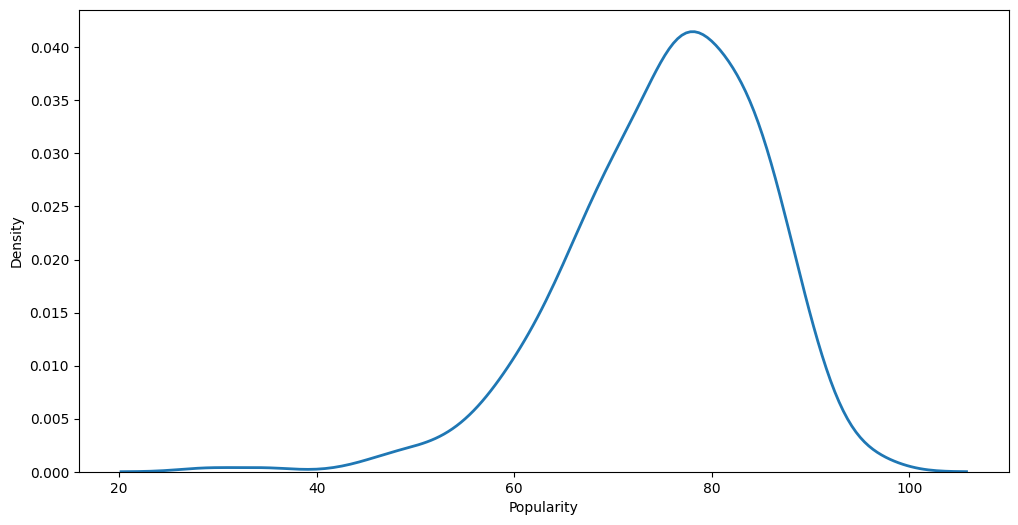

In [61]:
# 2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram?
plt.figure(figsize=(12, 6))
sns.kdeplot(spotify_df['Popularity'], linewidth=2)
plt.xlabel("Popularity")
plt.show()

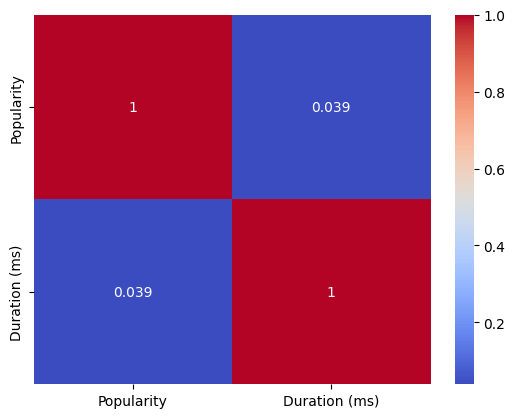

In [62]:
# 3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot?
sns.heatmap(spotify_df[["Popularity", "Duration (ms)"]].corr(), annot=True, cmap = "coolwarm")
plt.show()

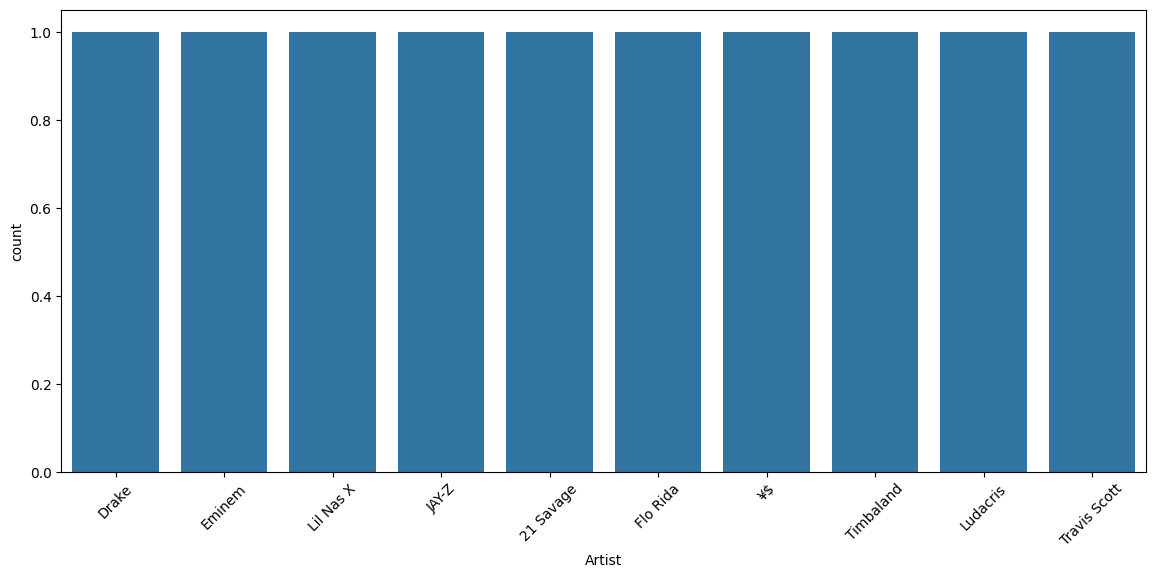

In [63]:
# 4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.
top_artists = spotify_df["Artist"].value_counts().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(14, 6))
sns.countplot(data=top_artists, x="Artist")
plt.xticks(rotation = 45)
plt.show()

In [64]:
# 5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each?
least_popular = spotify_df.sort_values(by="Popularity", ascending=True).head(5)
least_popular[["Artist", "Track Name"]]

,Artist,Track Name
207,Pressa,Attachments (feat. Coi Leray)
231,Justin Bieber,Intentions
413,French Montana,Splash Brothers
225,Lil Baby,On Me - Remix
407,Wyclef Jean,911 (feat. Mary J. Blige)


In [65]:
# 6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.
most_popular = spotify_df.sort_values(by="Popularity", ascending=False).head(5)
most_popular

,Artist,Track Name,Popularity,Duration (ms),Track ID
40,Jack Harlow,Lovin On Me,97,138411,4xhsWYTOGcal8zt0J161CU
260,¥$,CARNIVAL,96,264324,3w0w2T288dec0mgeZZqoNN
70,21 Savage,redrum,96,270697,52eIcoLUM25zbQupAZYoFh
30,Travis Scott,FE!N (feat. Playboi Carti),93,191700,42VsgItocQwOQC3XWZ8JNA
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6


In [66]:
avg_high_popular = spotify_df.groupby("Artist")["Popularity"].mean().sort_values(ascending=False)
avg_high_popular

,Popularity
Artist,
cassö,92.000000
Trueno,89.000000
David Guetta,87.000000
Travis Scott,86.555556
¥$,85.100000
...,...
RAYE,55.000000
Wyclef Jean,54.500000
Arizona Zervas,54.000000


In [67]:
# 7.  For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist?
most_popular[["Artist", "Track Name"]]

,Artist,Track Name
40,Jack Harlow,Lovin On Me
260,¥$,CARNIVAL
70,21 Savage,redrum
30,Travis Scott,FE!N (feat. Playboi Carti)
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA)


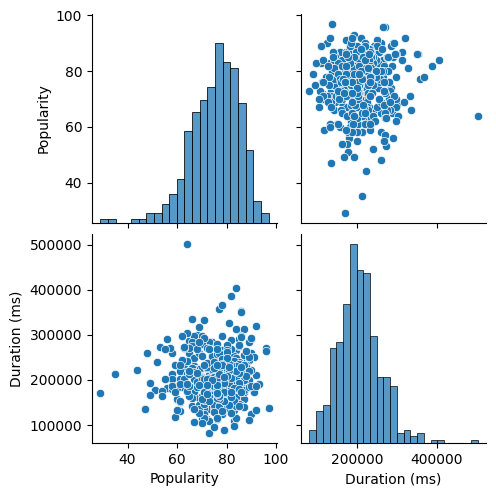

In [68]:
# 8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.
num_cols = spotify_df.select_dtypes(include=np.number)
sns.pairplot(num_cols)
plt.show()

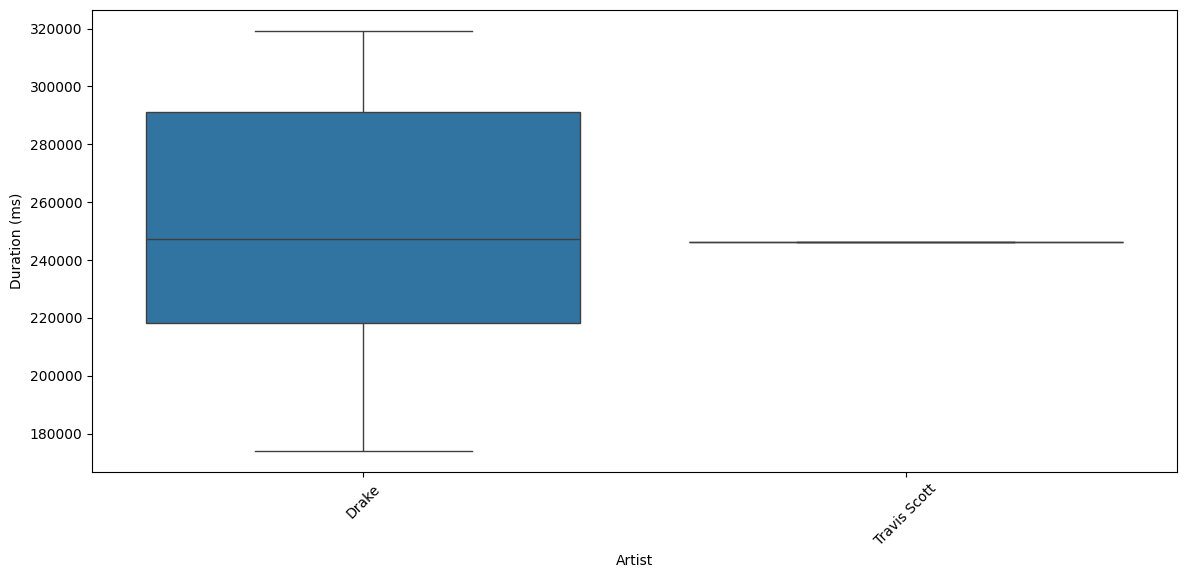

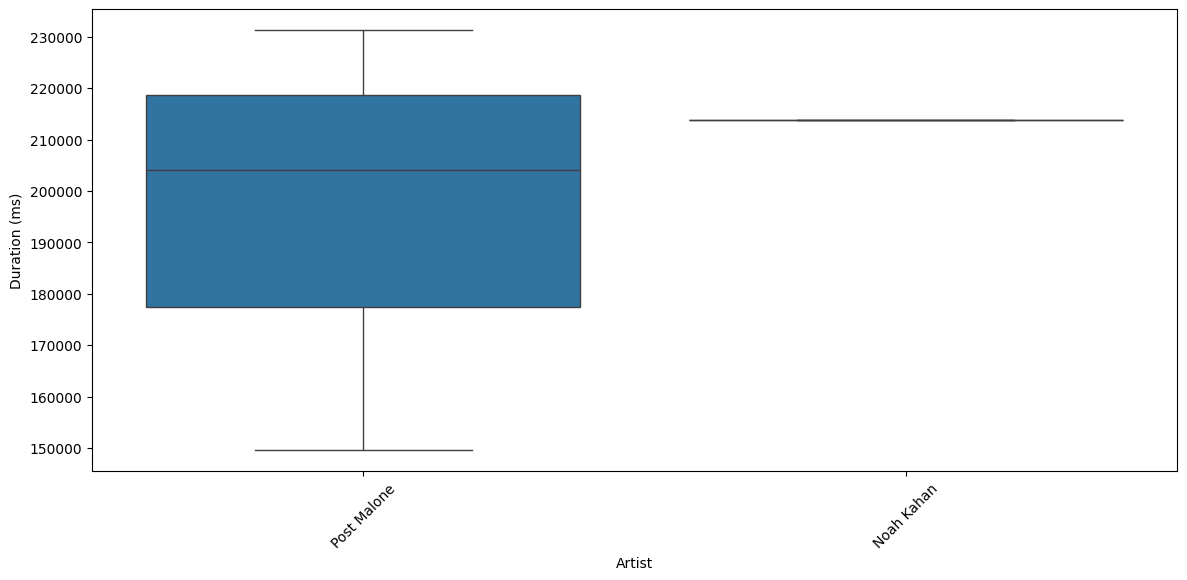

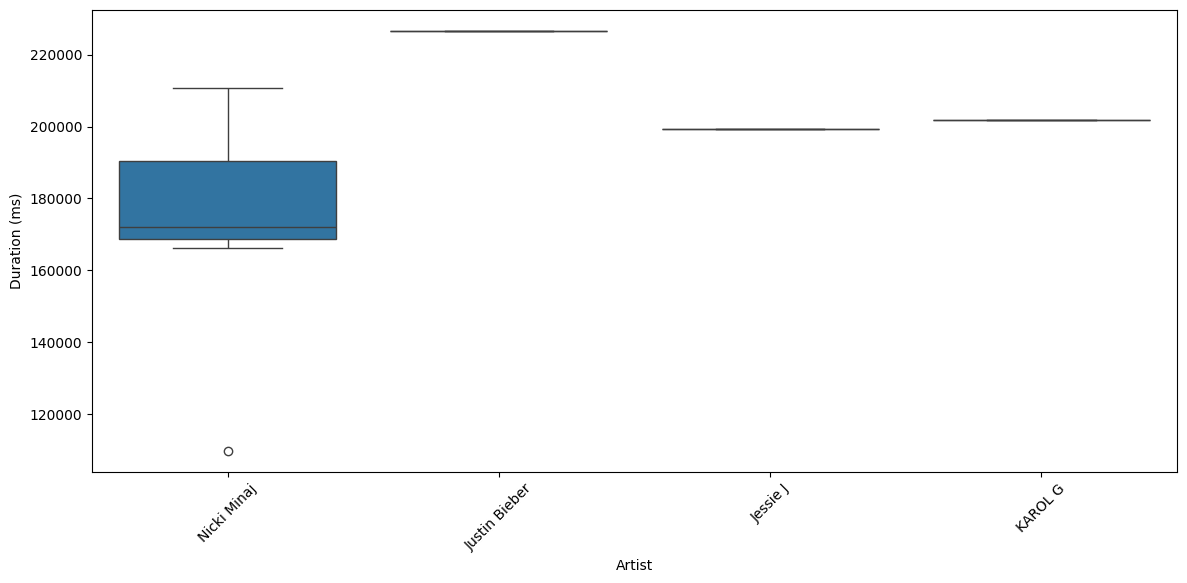

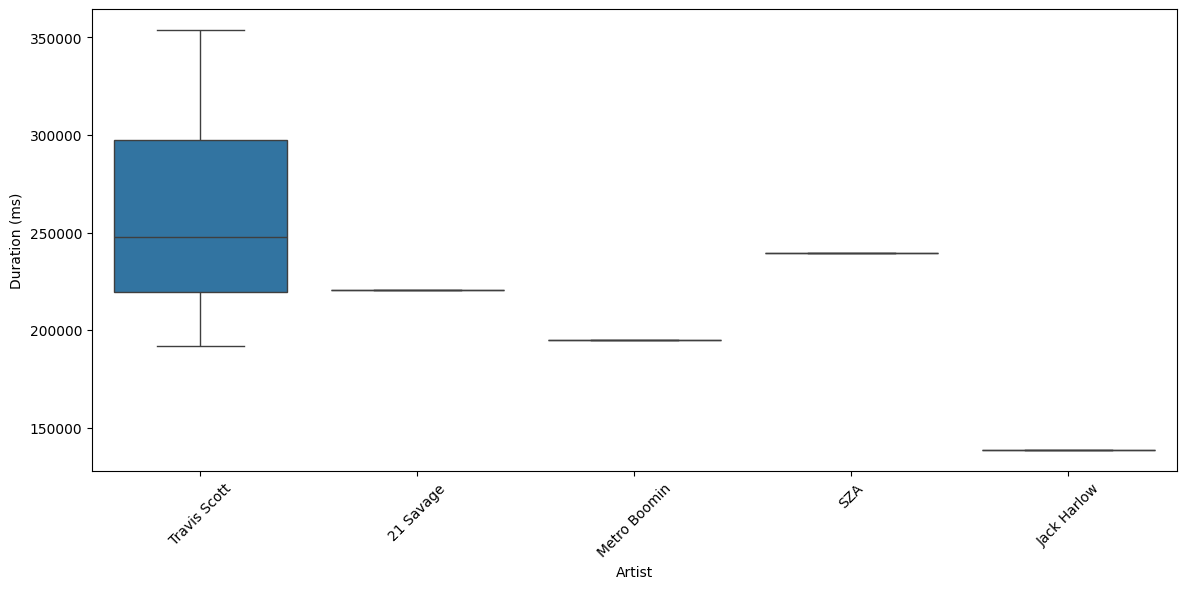

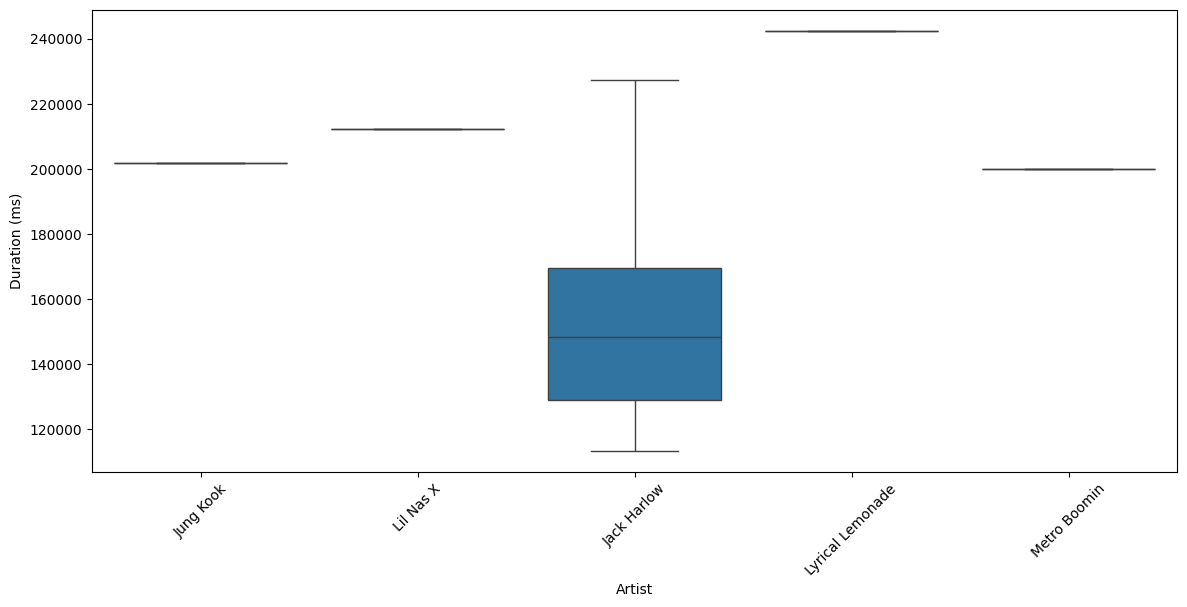

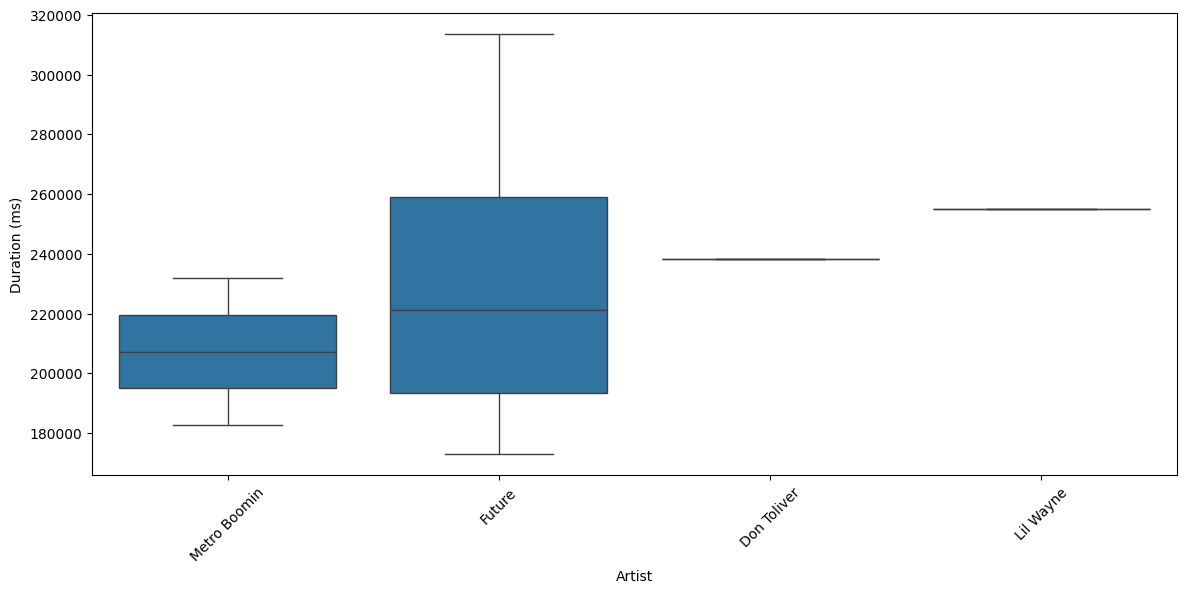

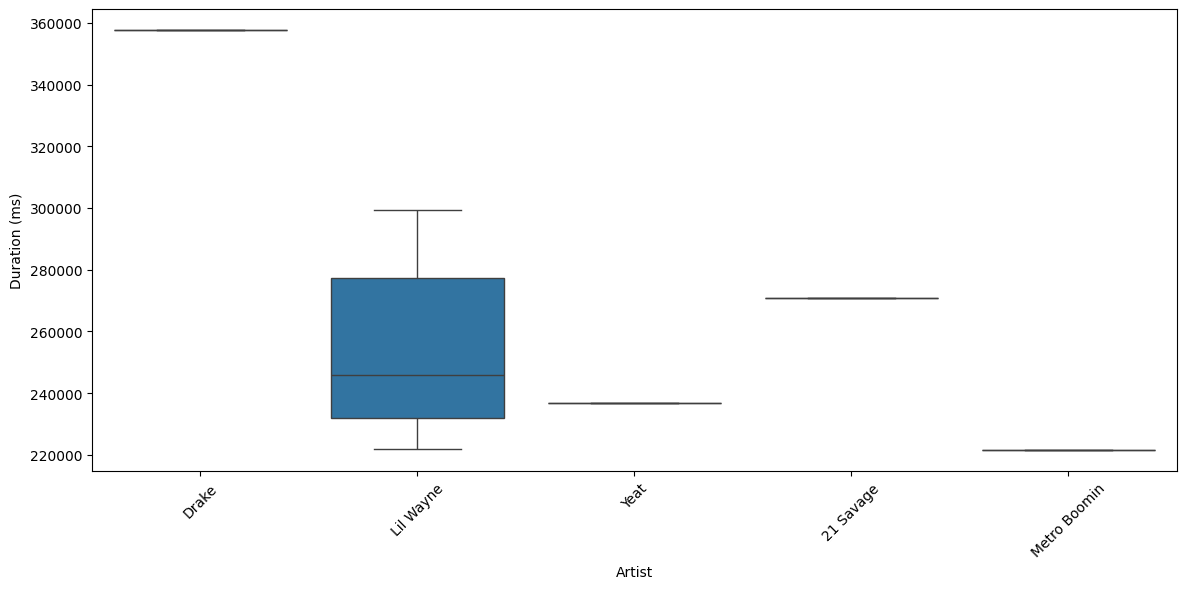

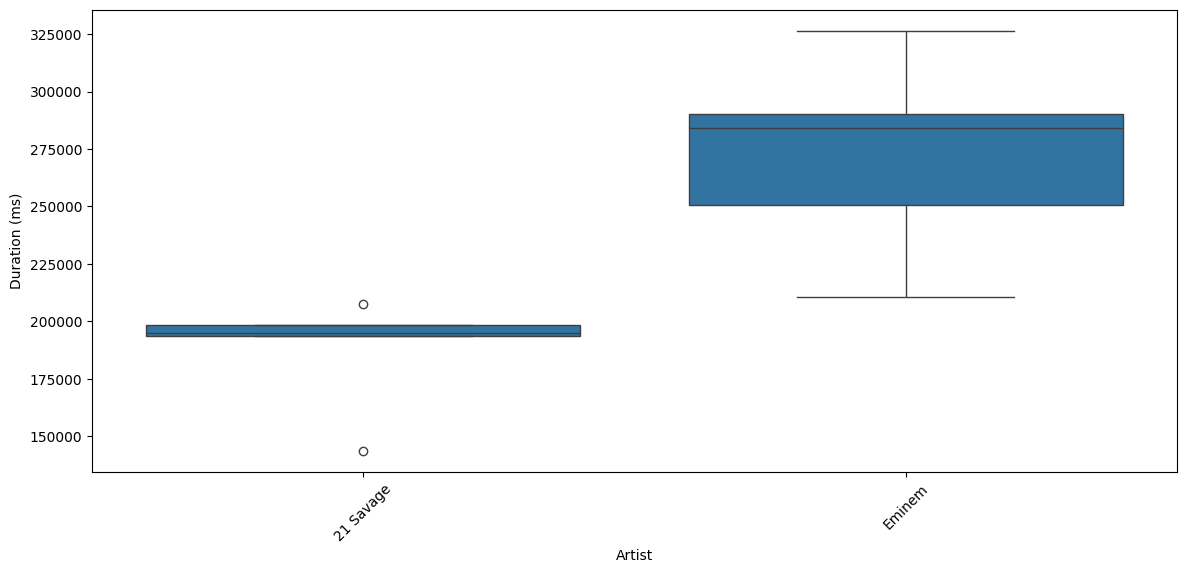

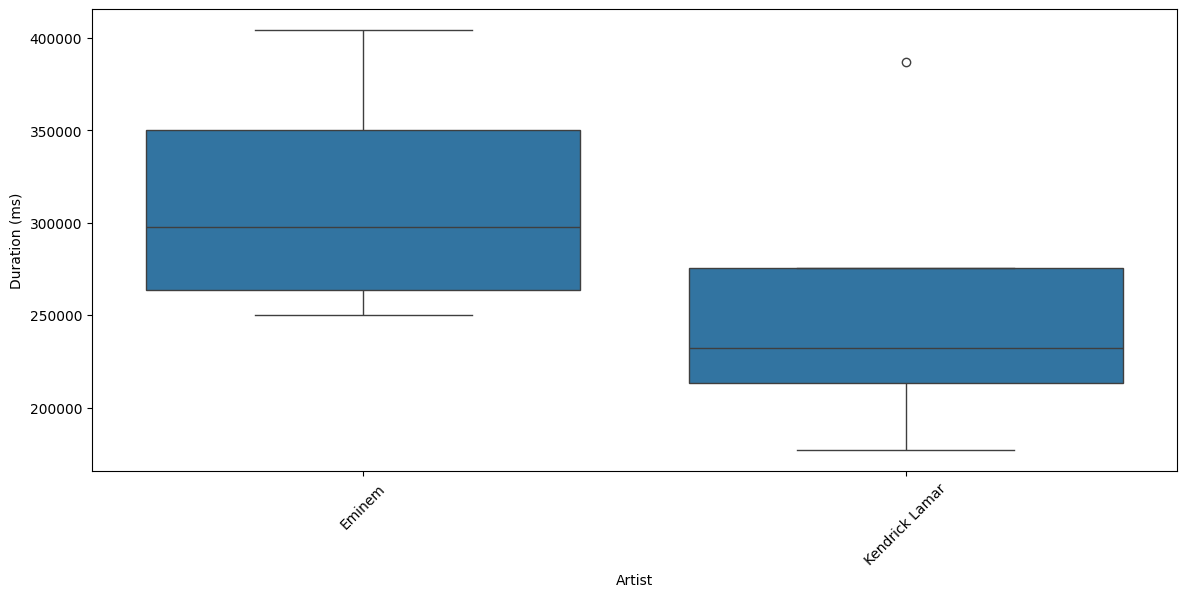

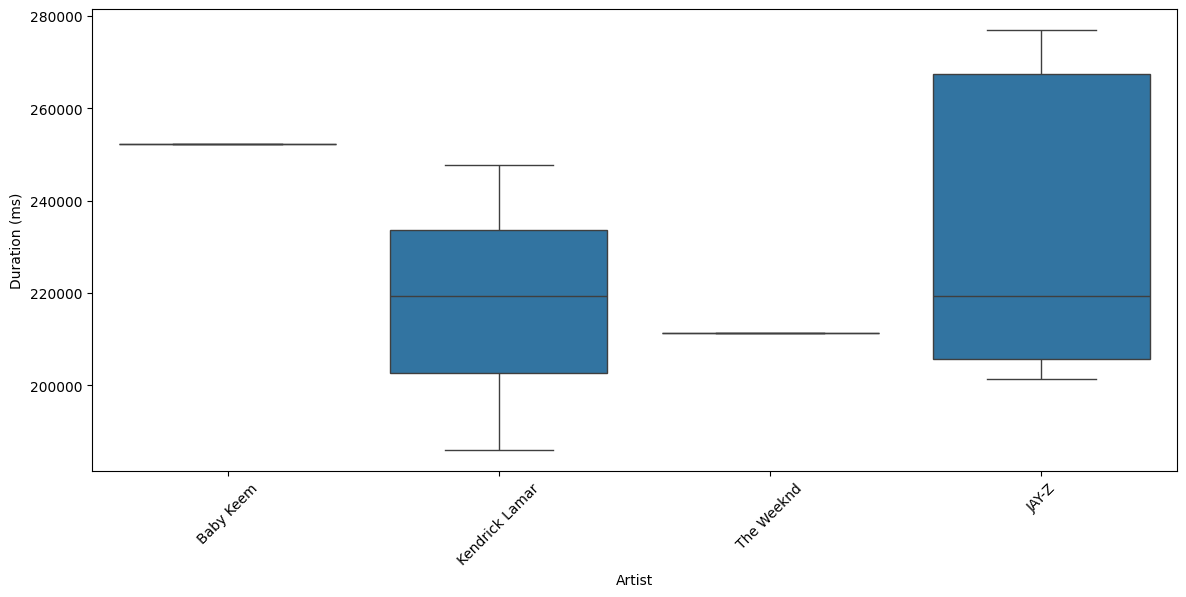

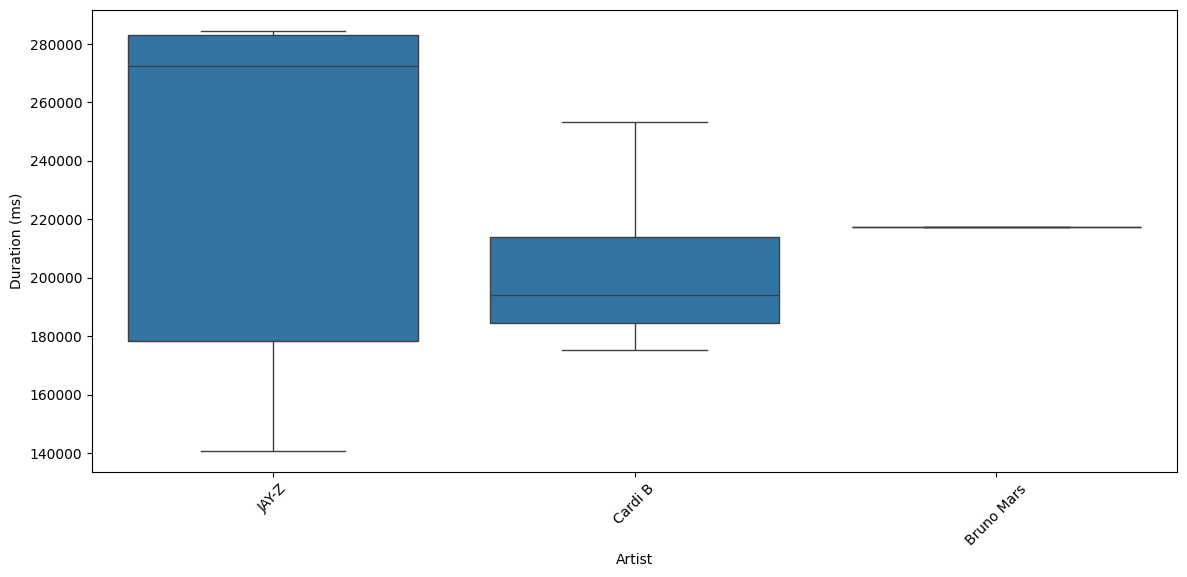

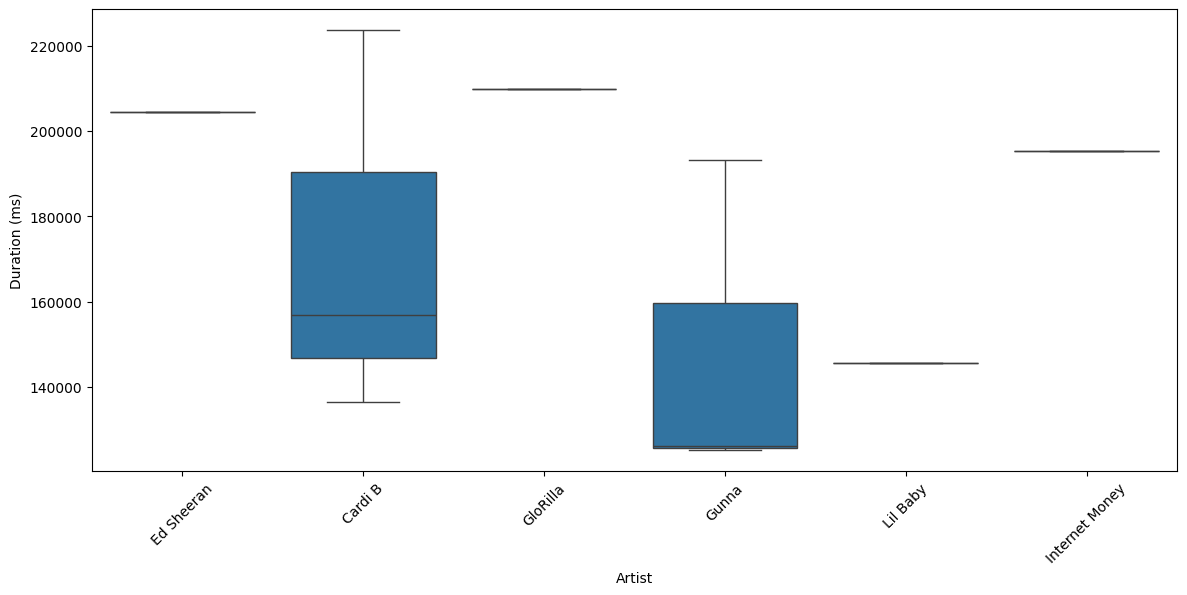

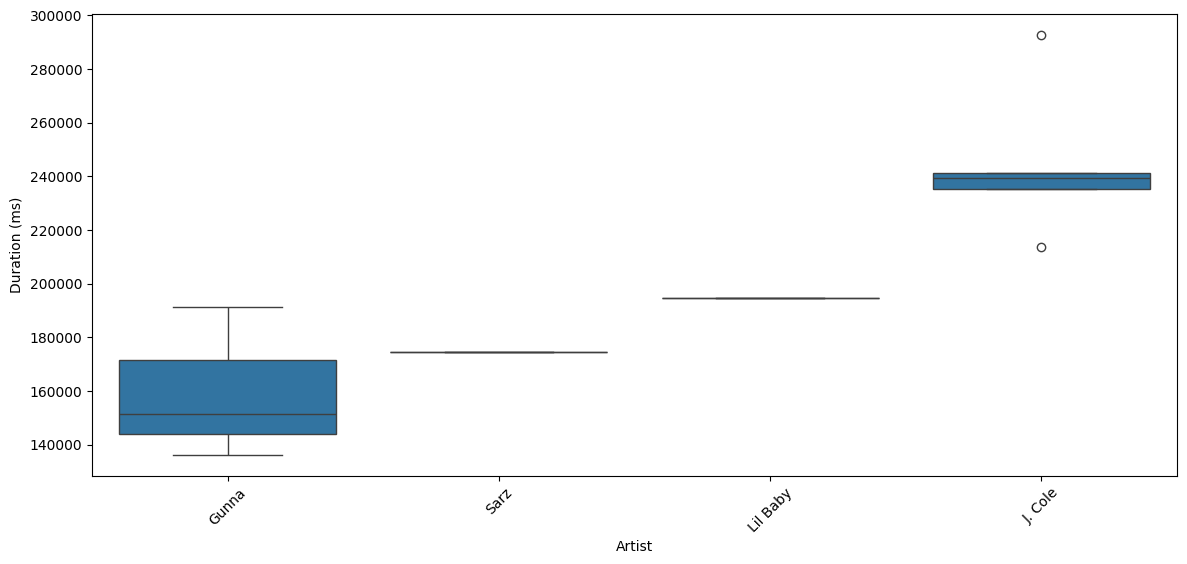

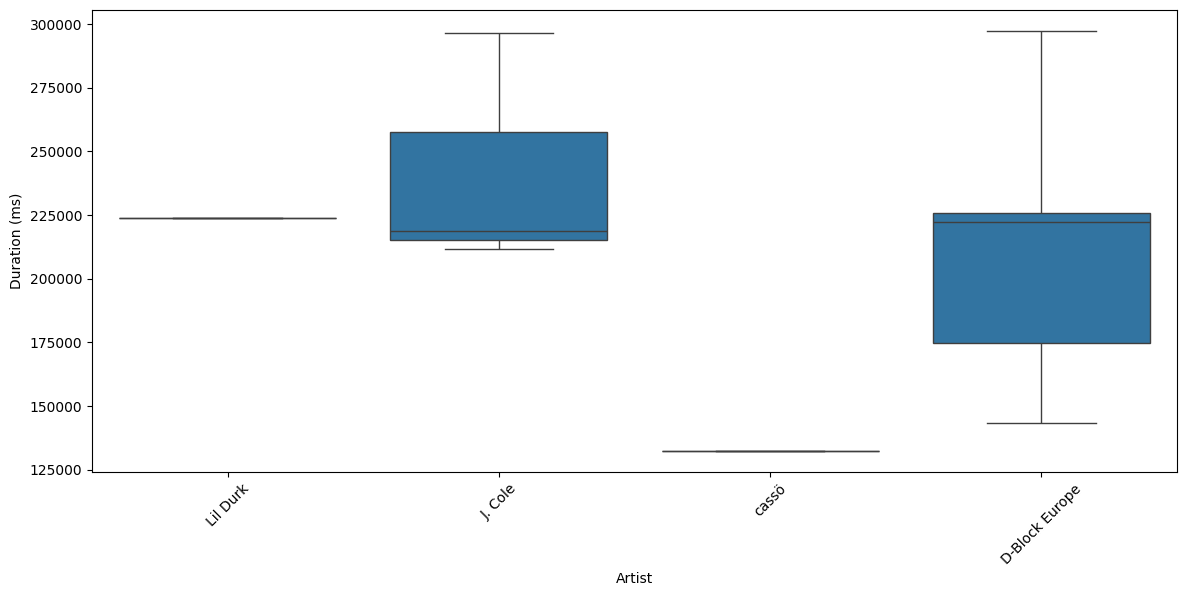

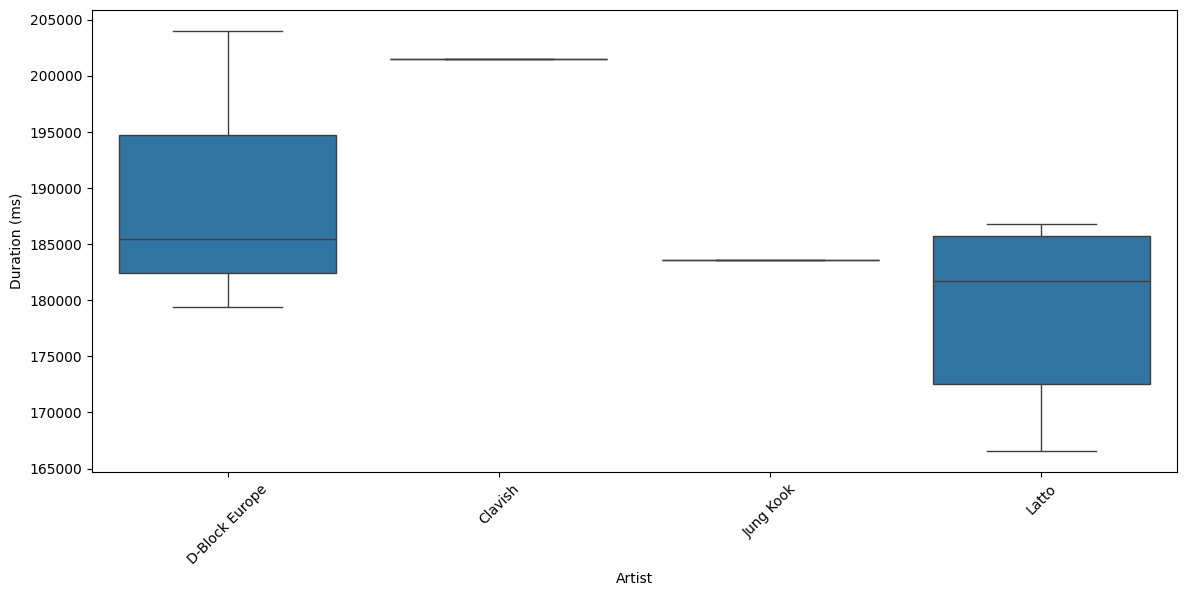

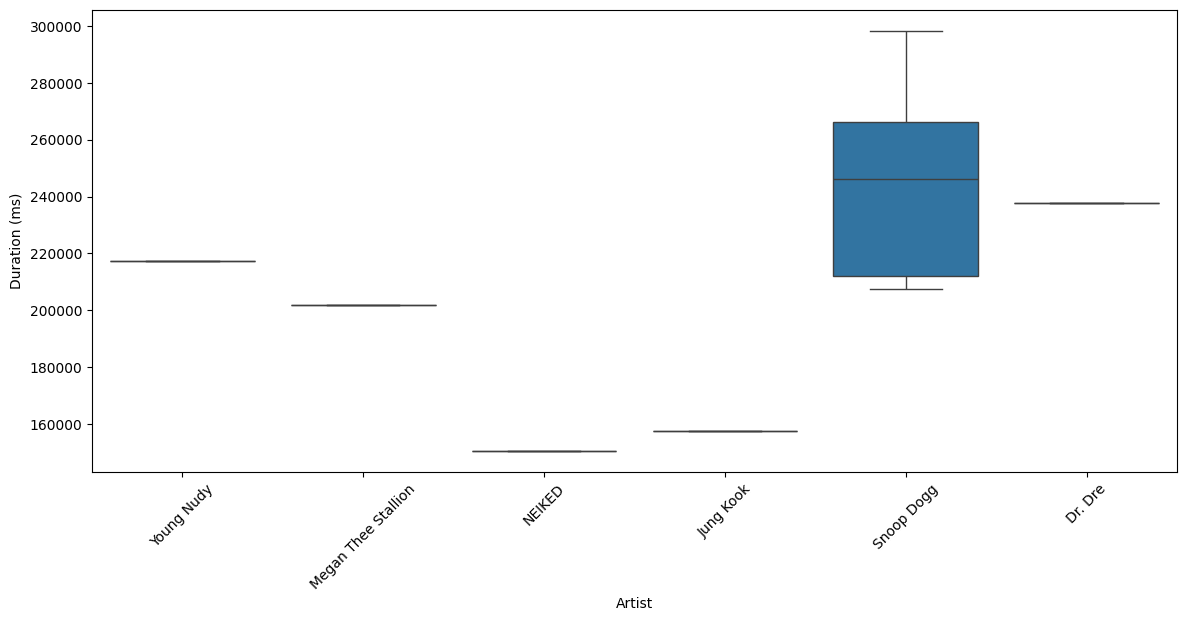

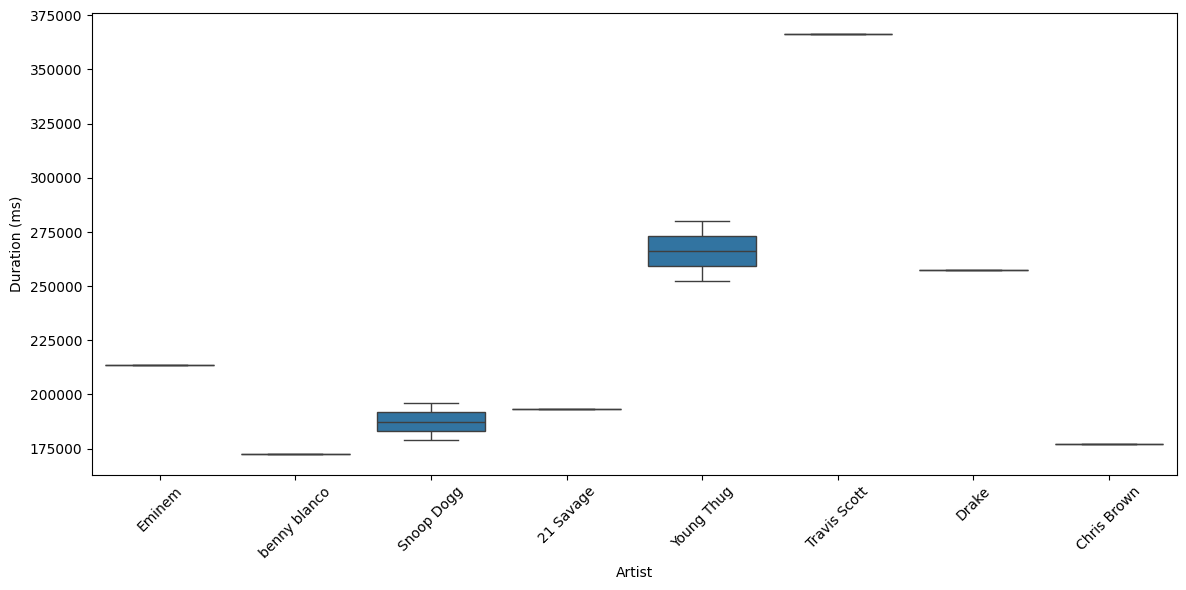

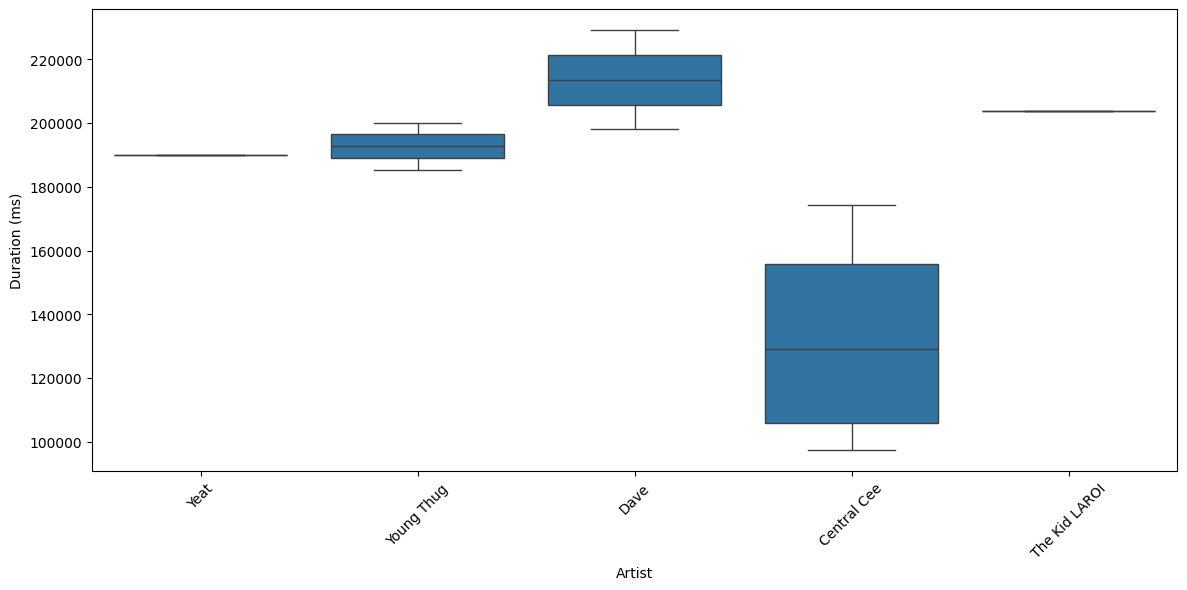

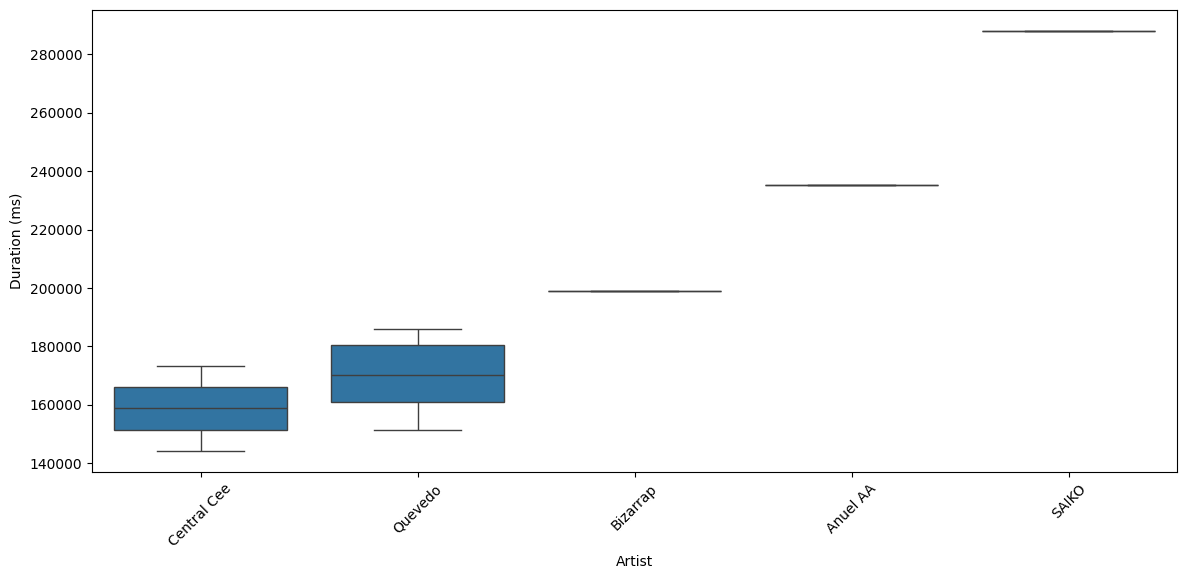

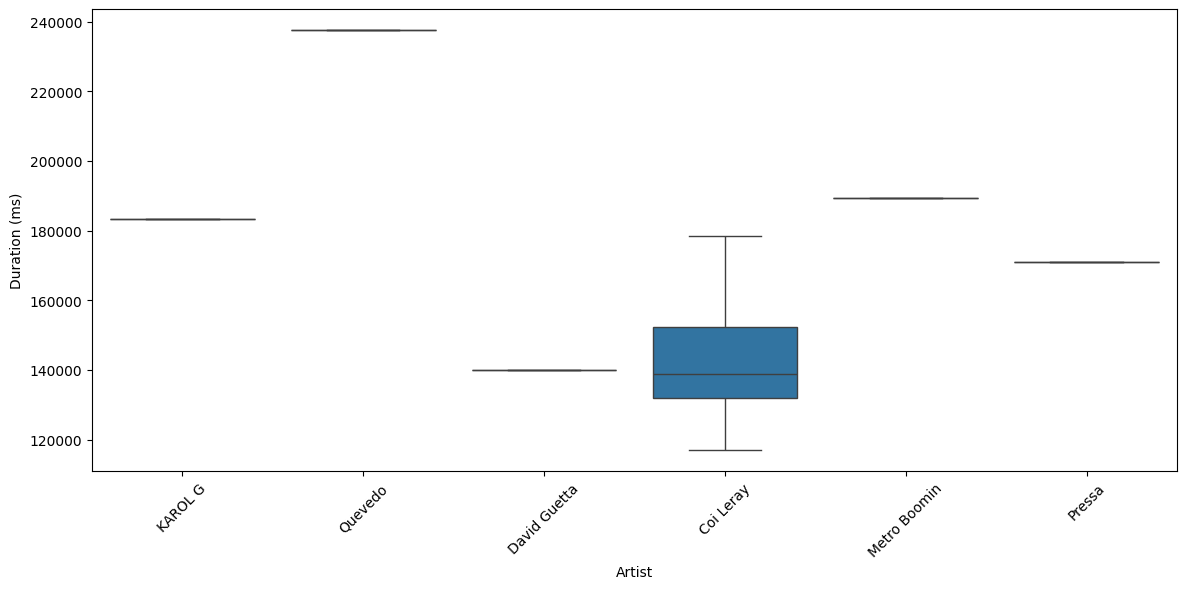

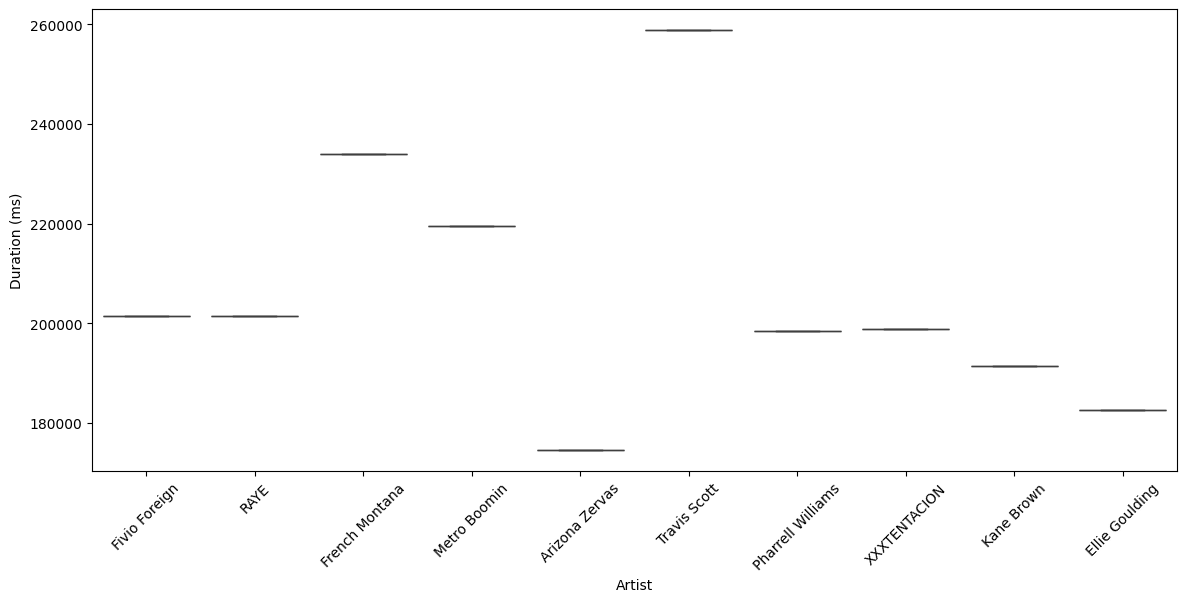

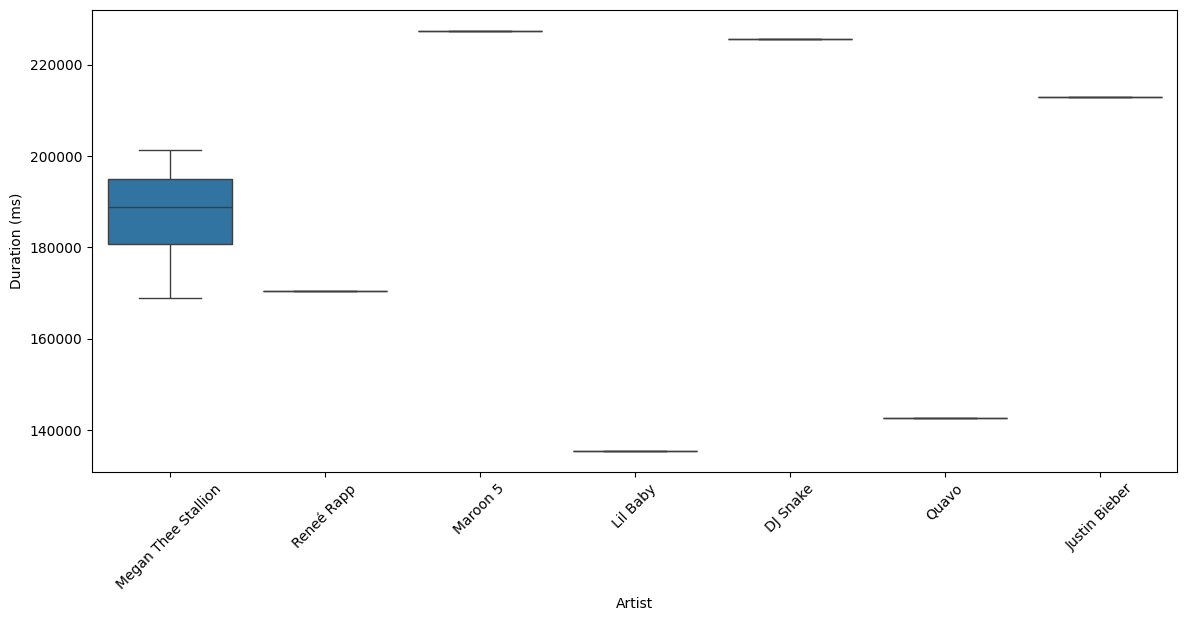

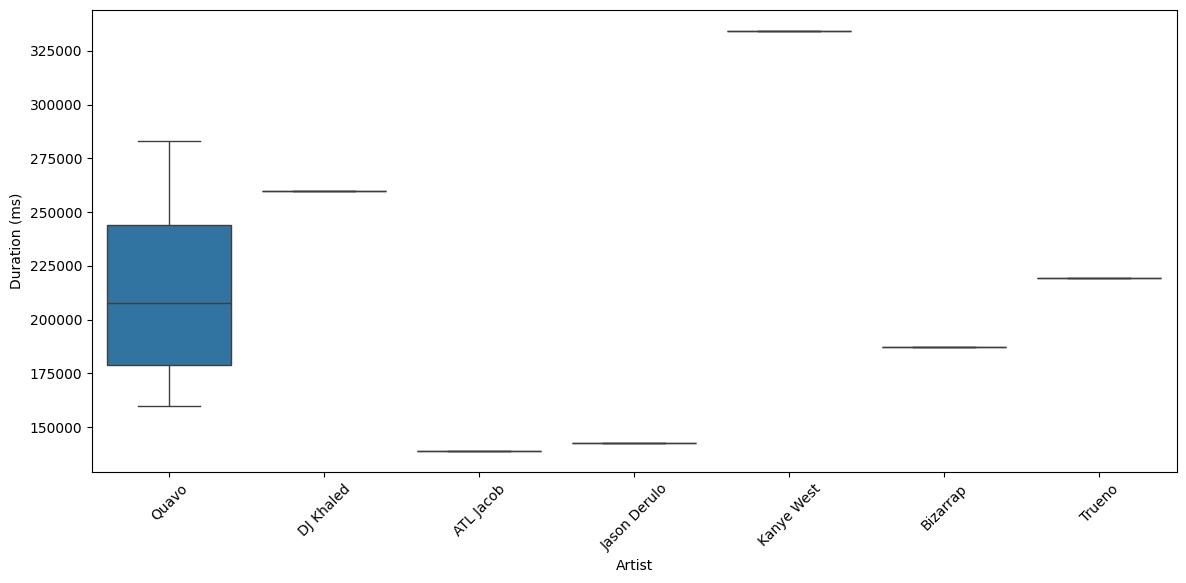

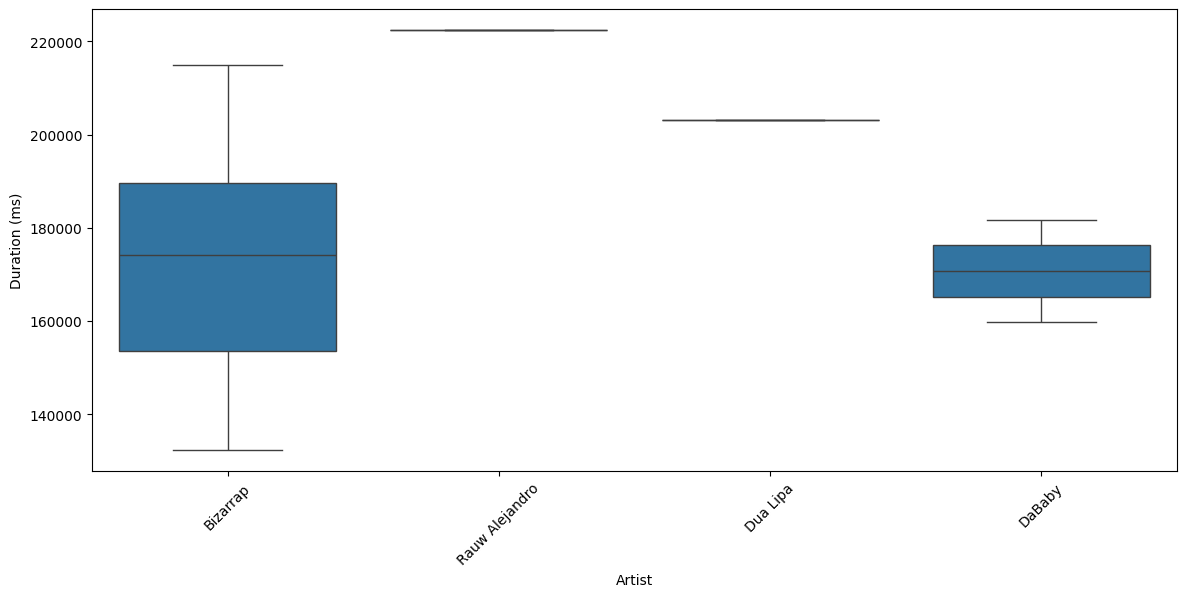

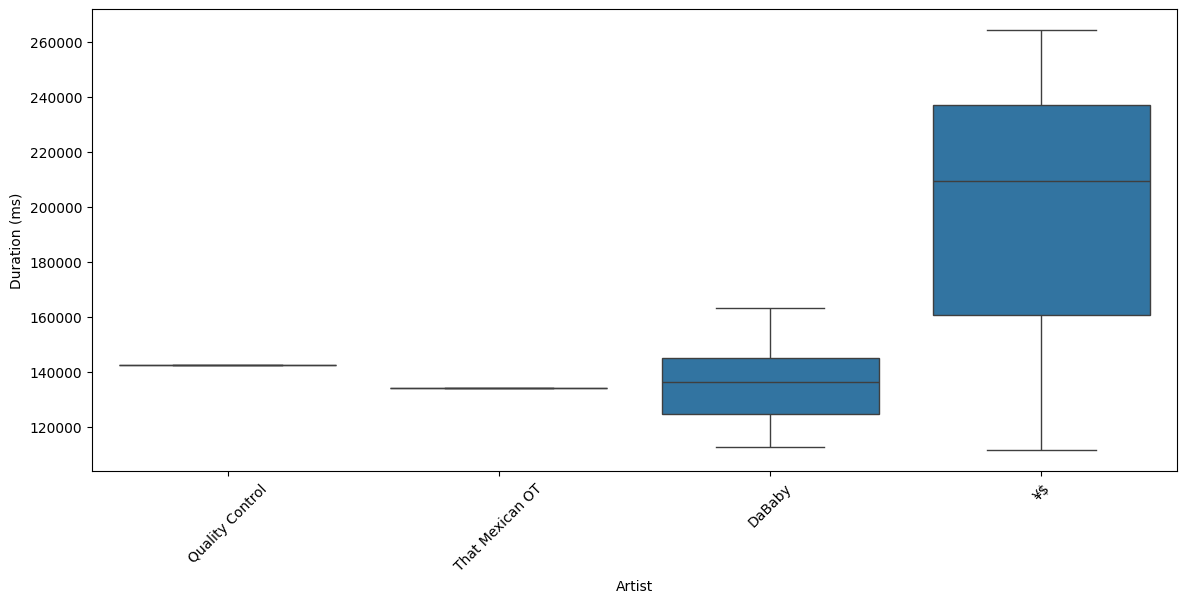

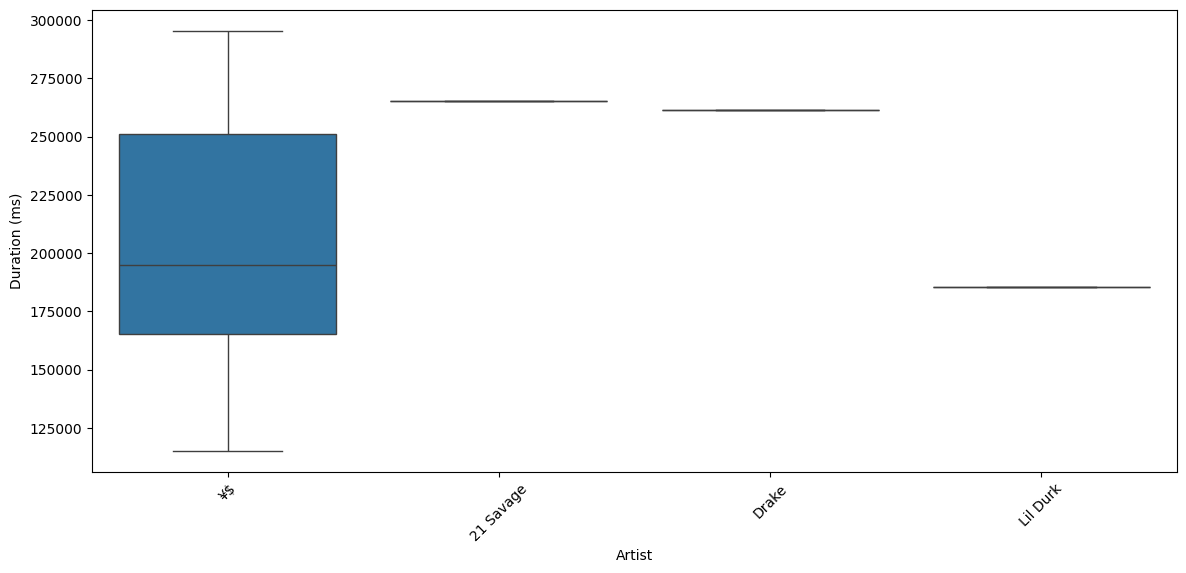

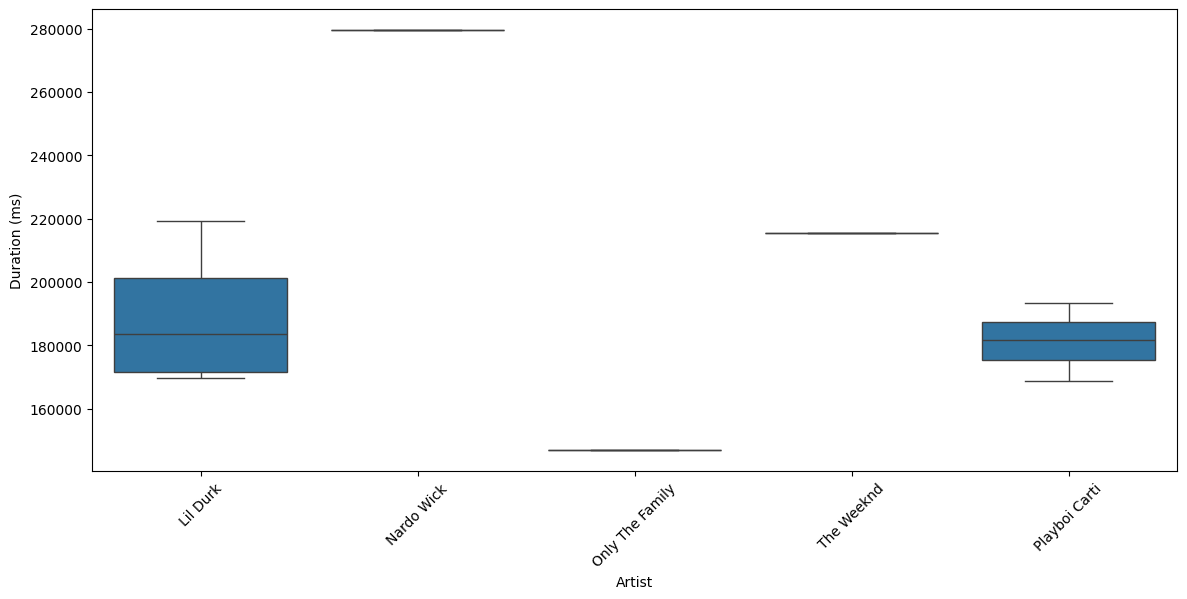

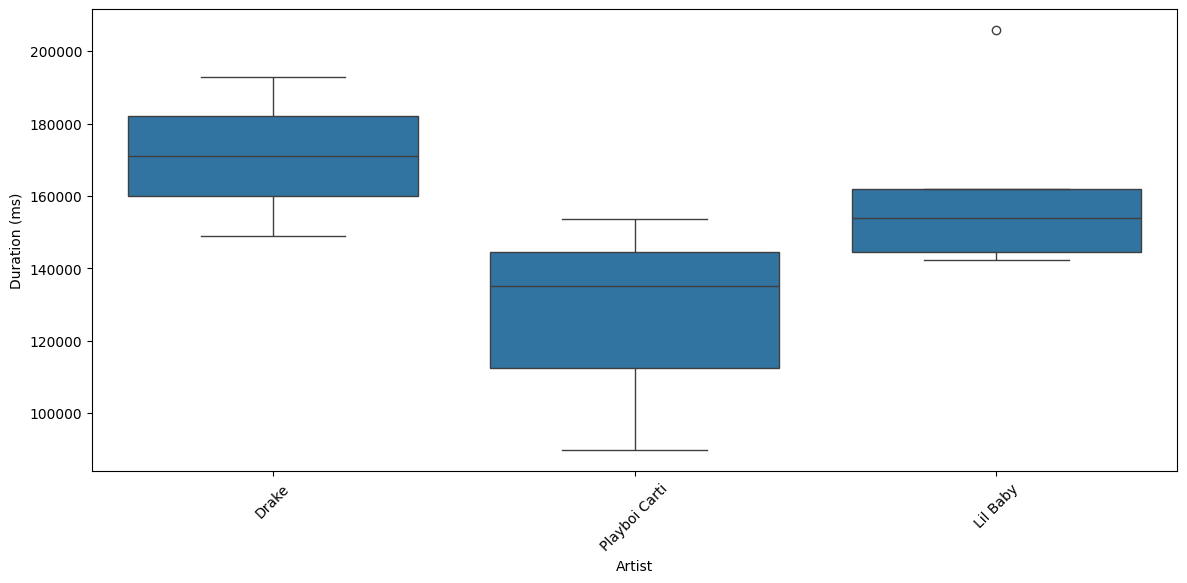

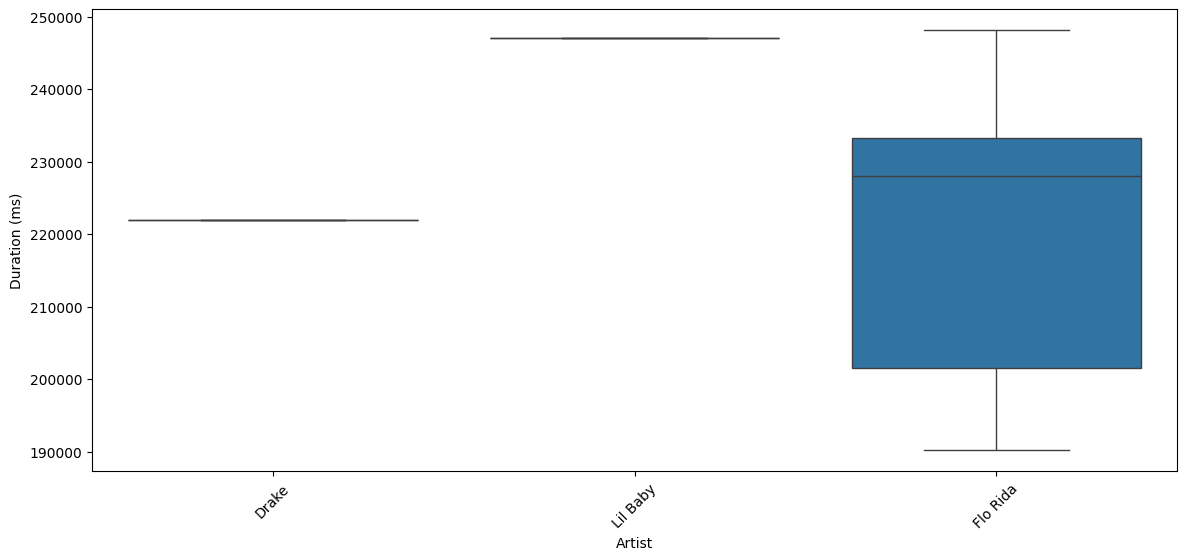

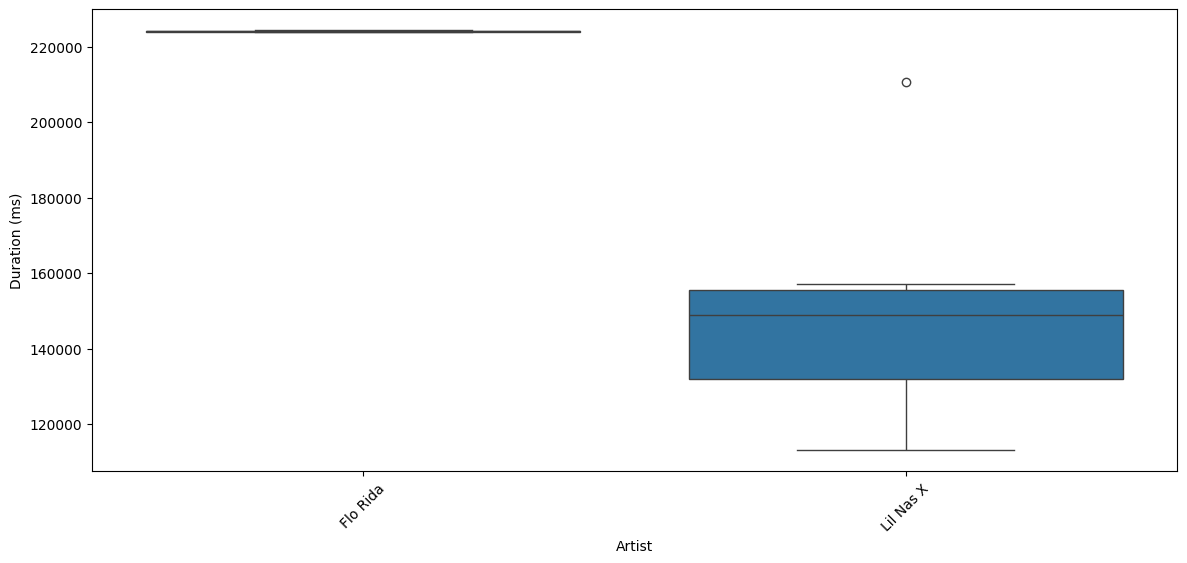

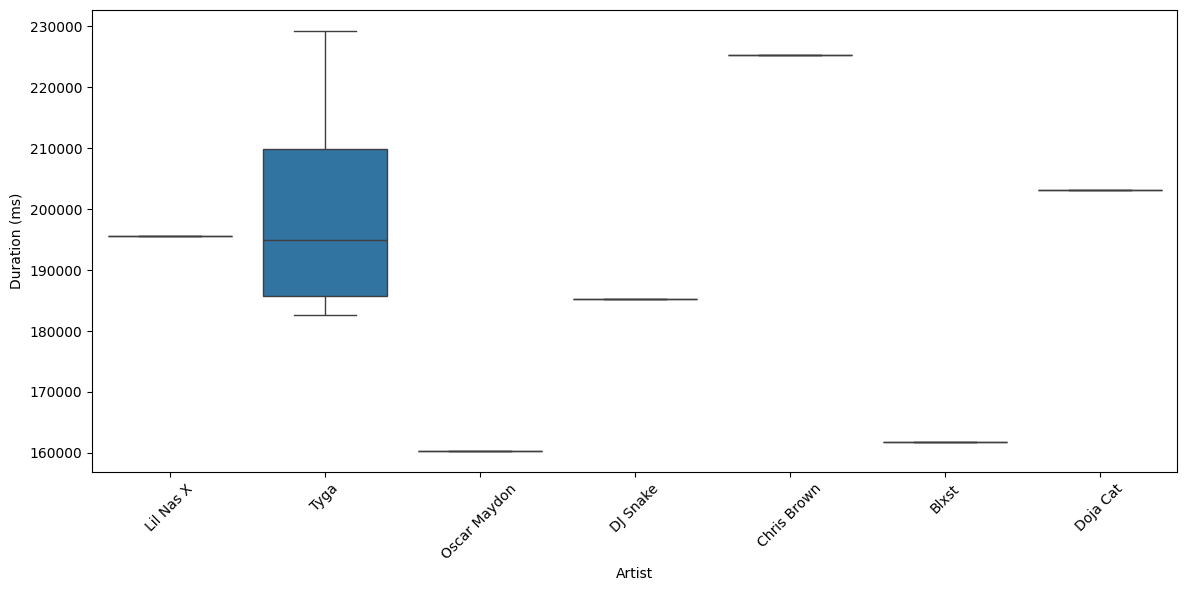

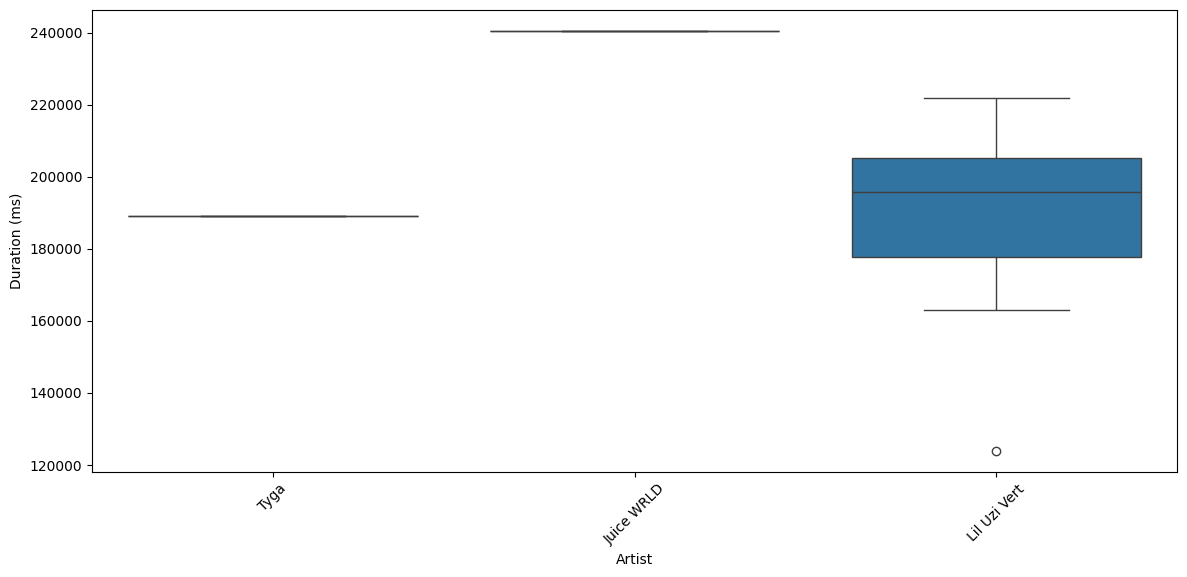

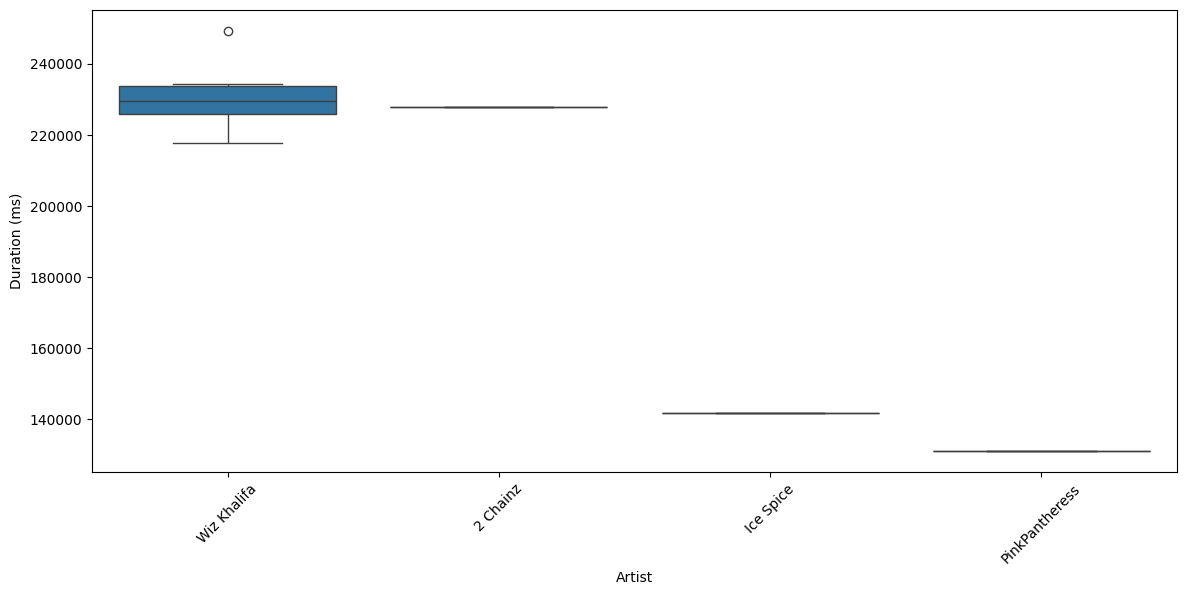

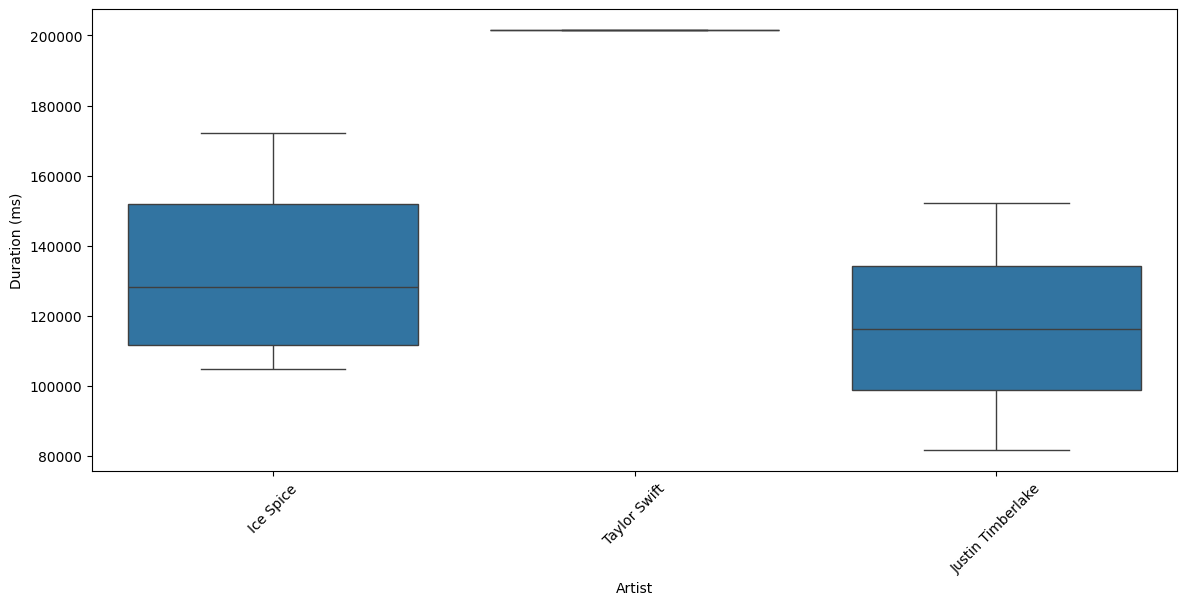

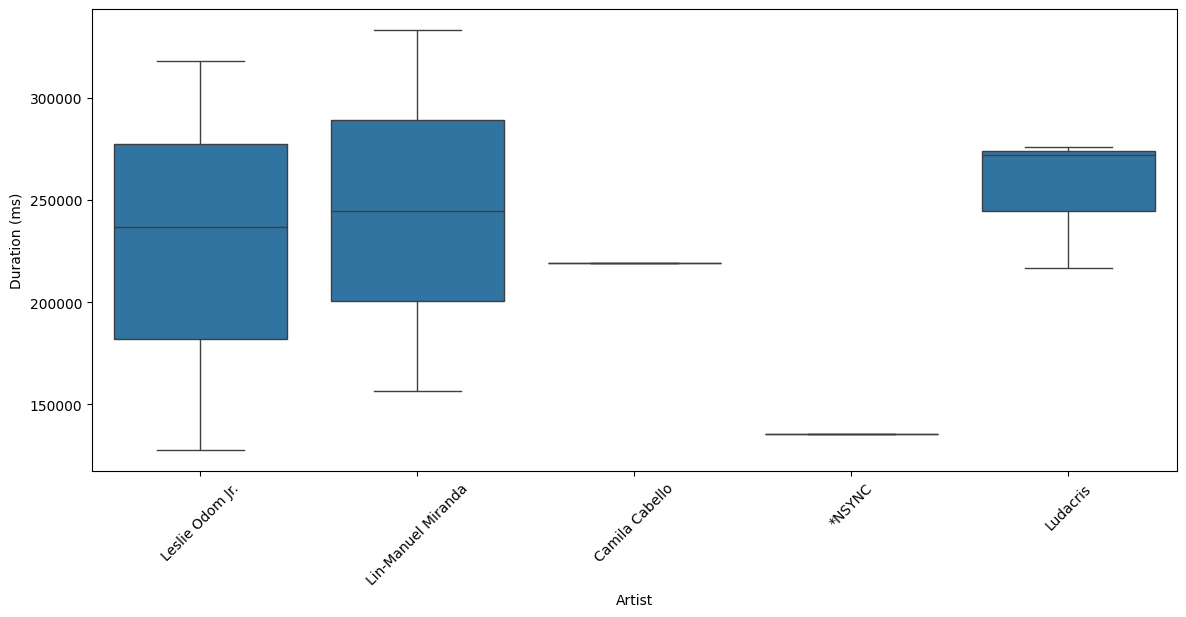

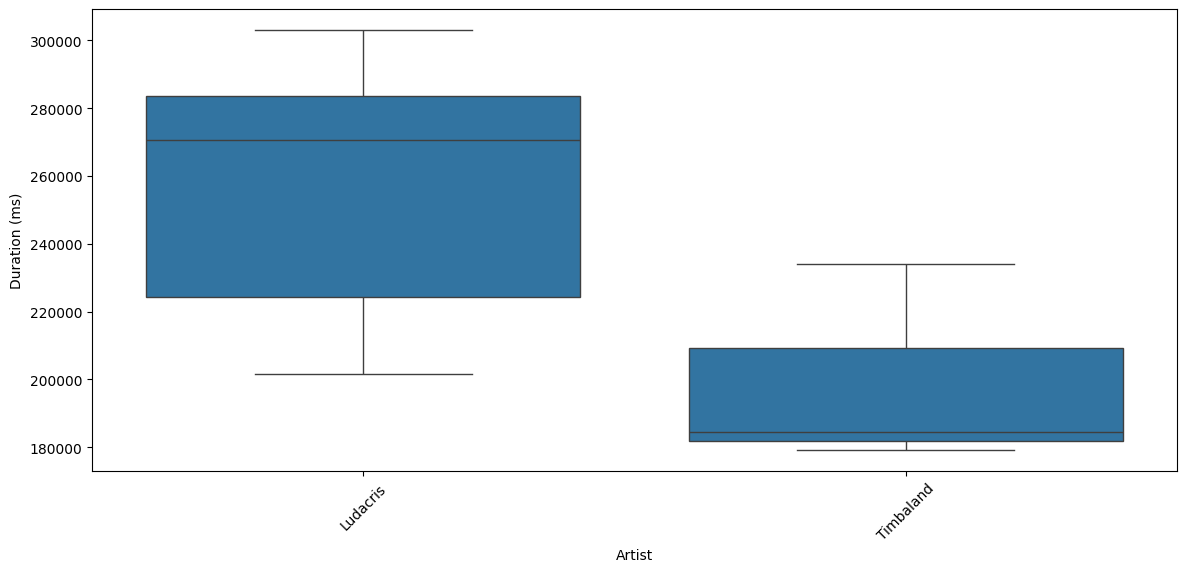

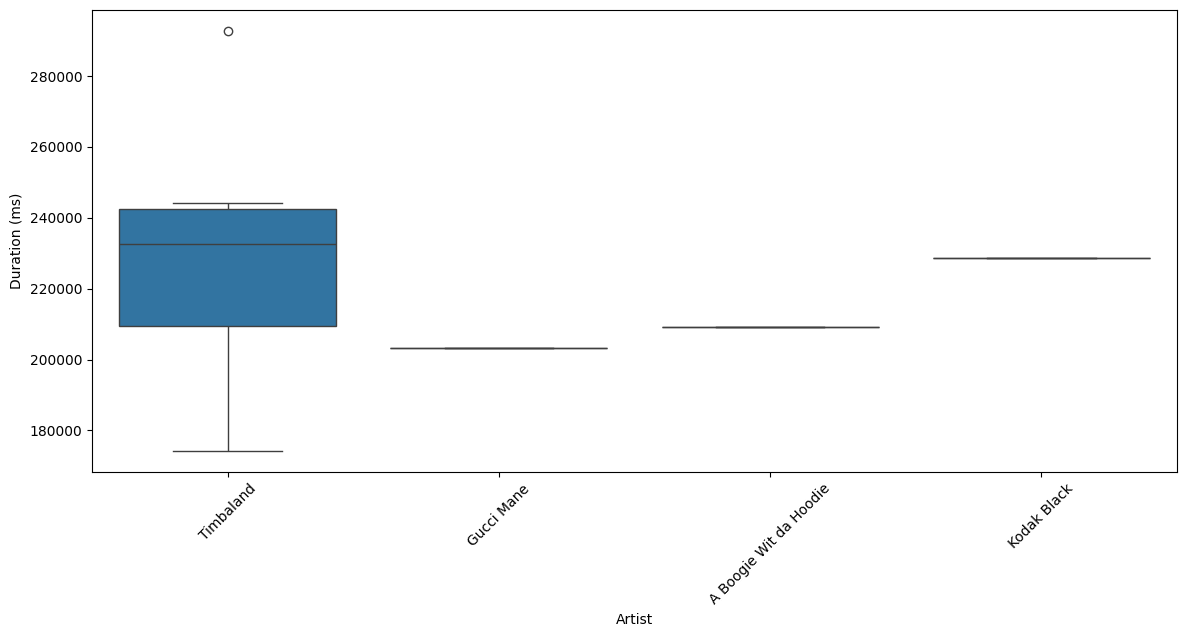

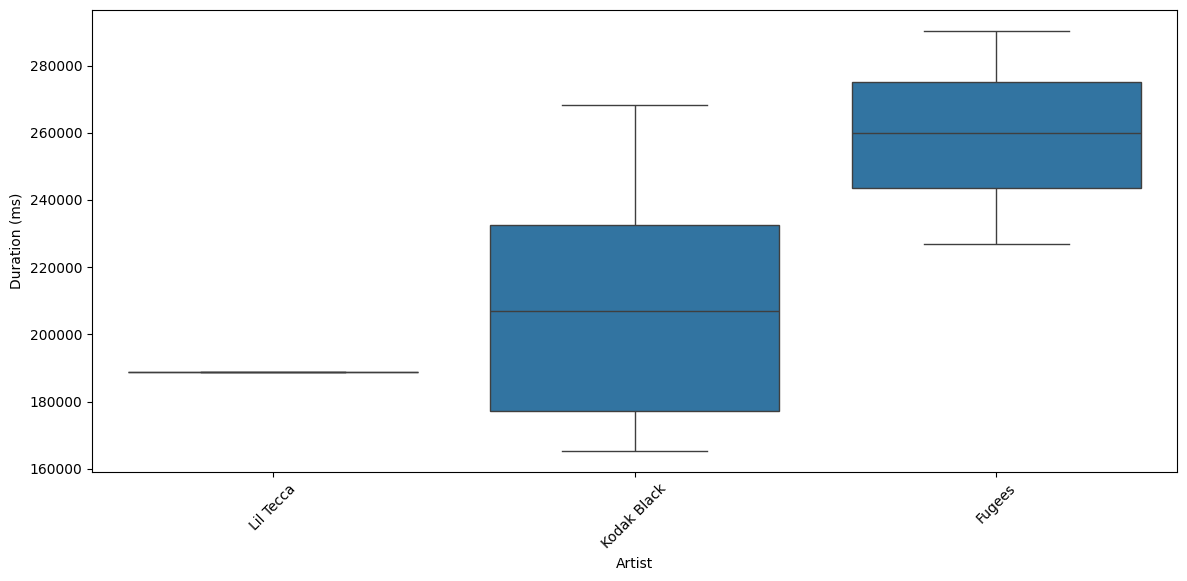

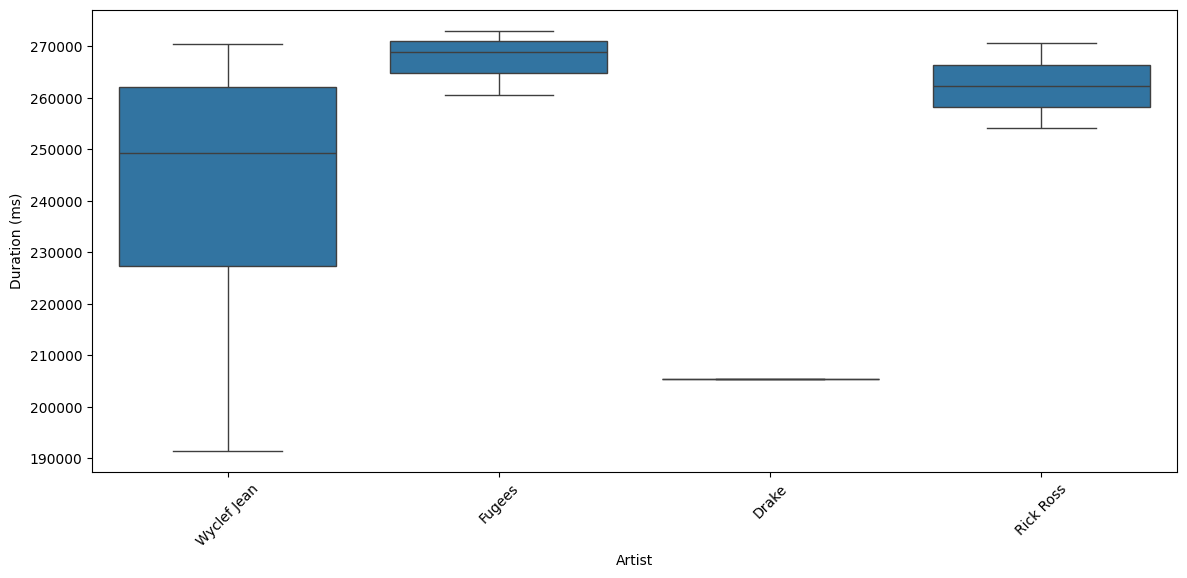

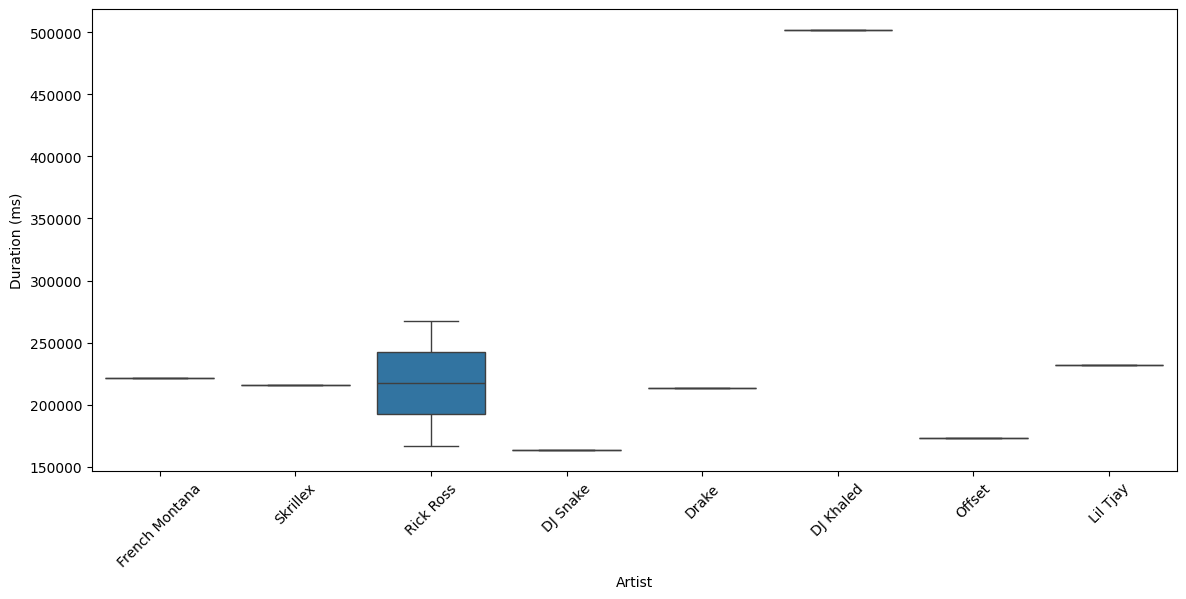

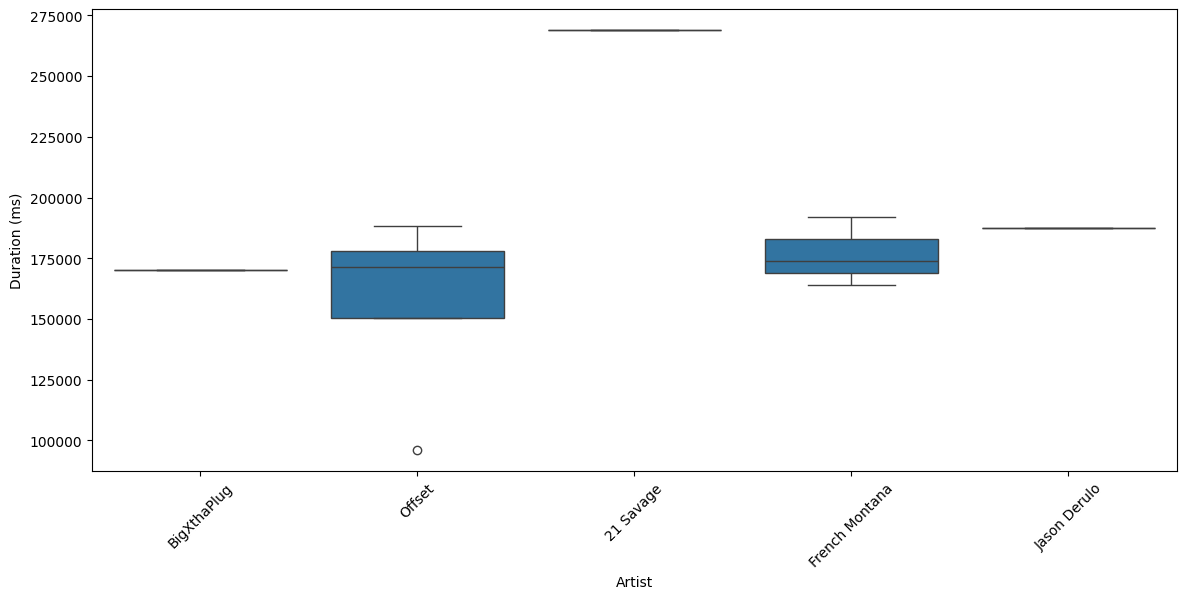

In [69]:
# 9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.
for i in range(int(len( spotify_df ) / 10 ) ):
  plt.figure(figsize=(14, 6))
  sns.boxplot(data=spotify_df[i*10: i*10+10], x="Artist", y="Duration (ms)")
  plt.xticks(rotation = 45)
  plt.show()

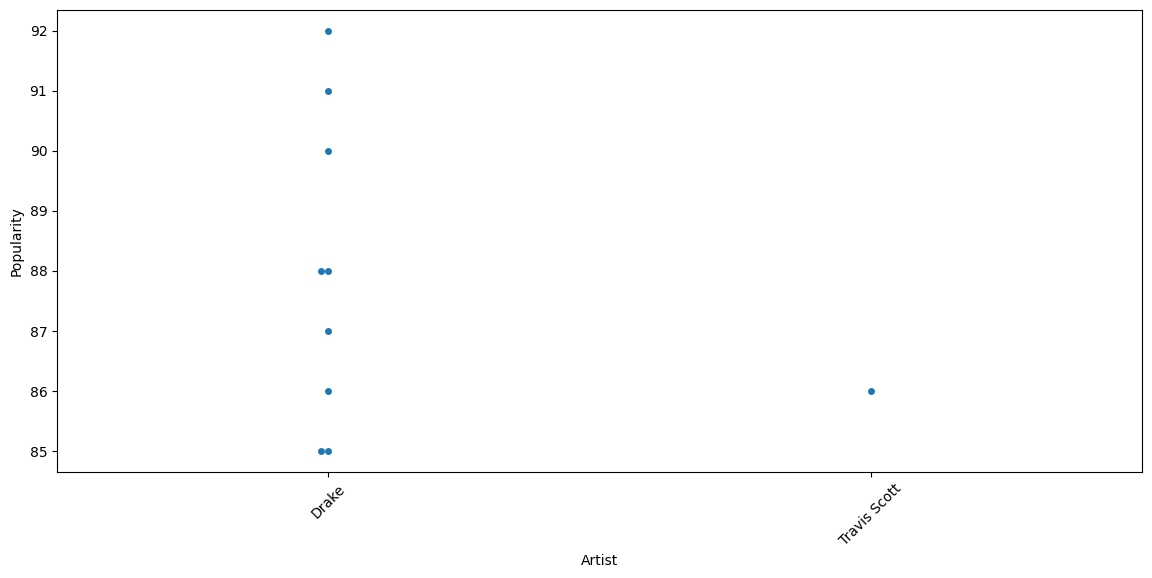

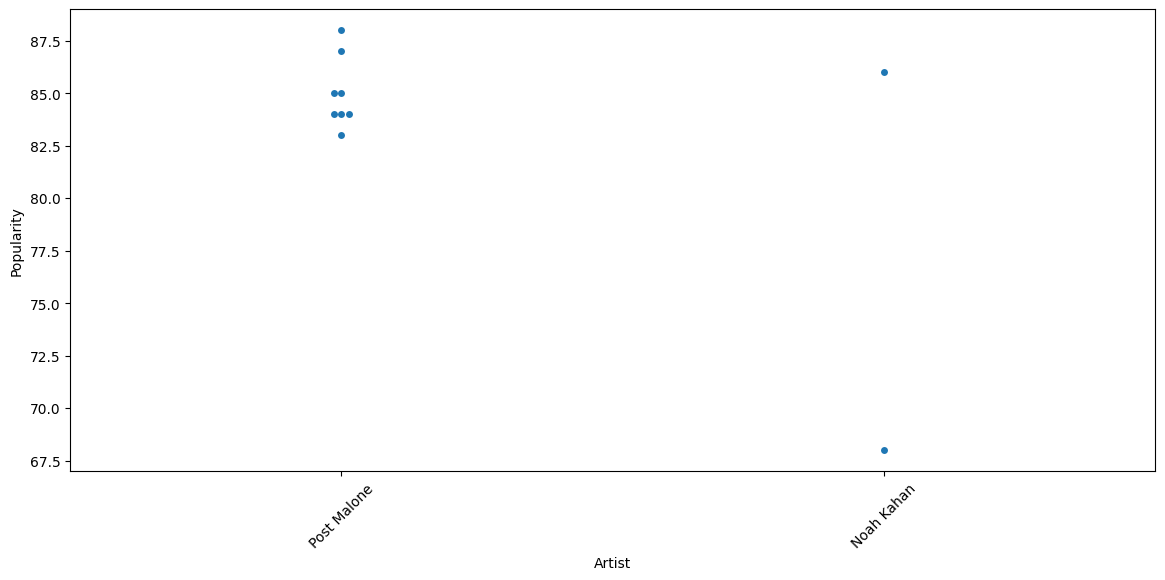

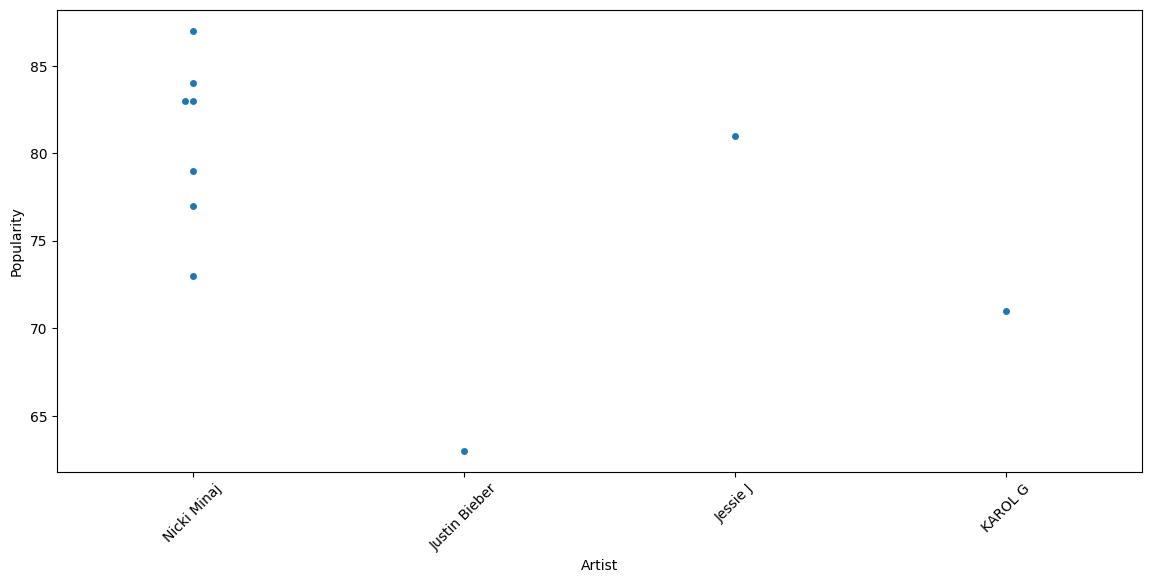

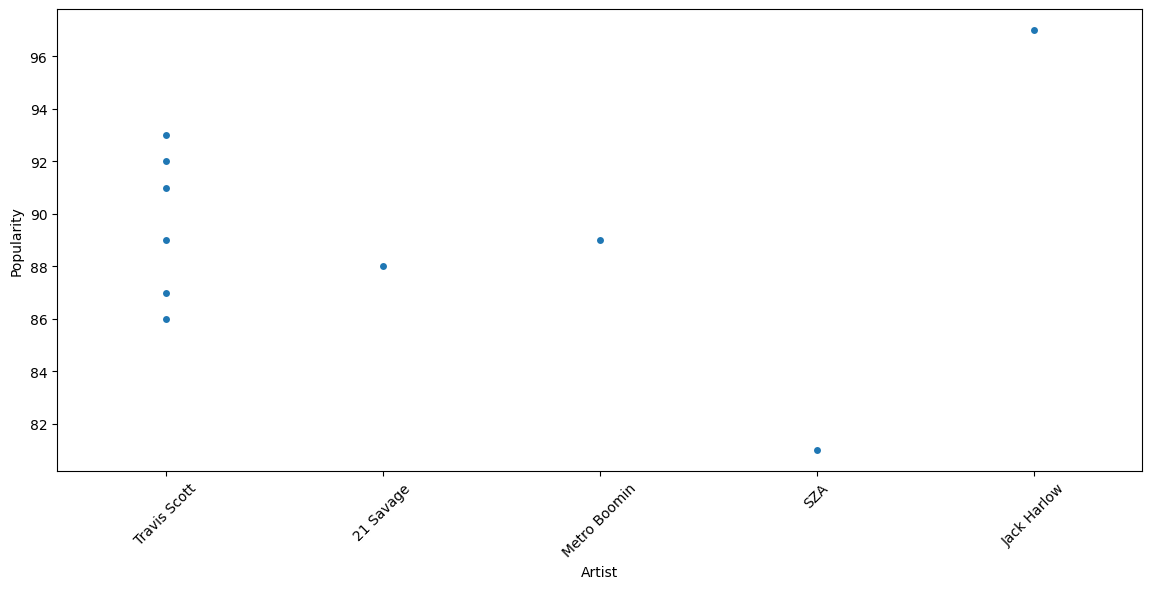

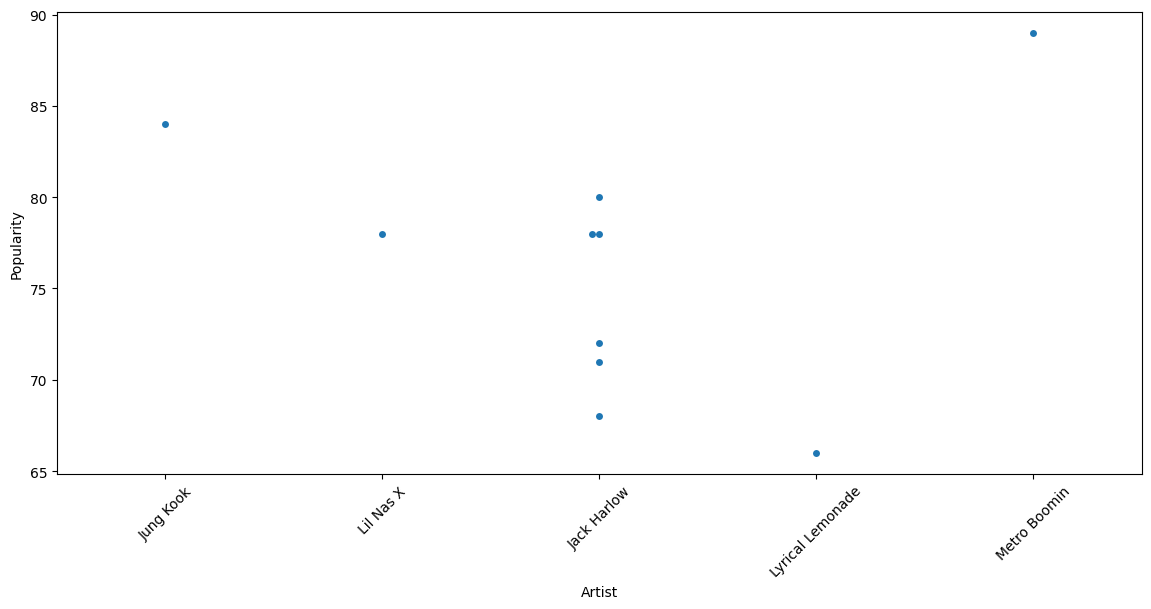

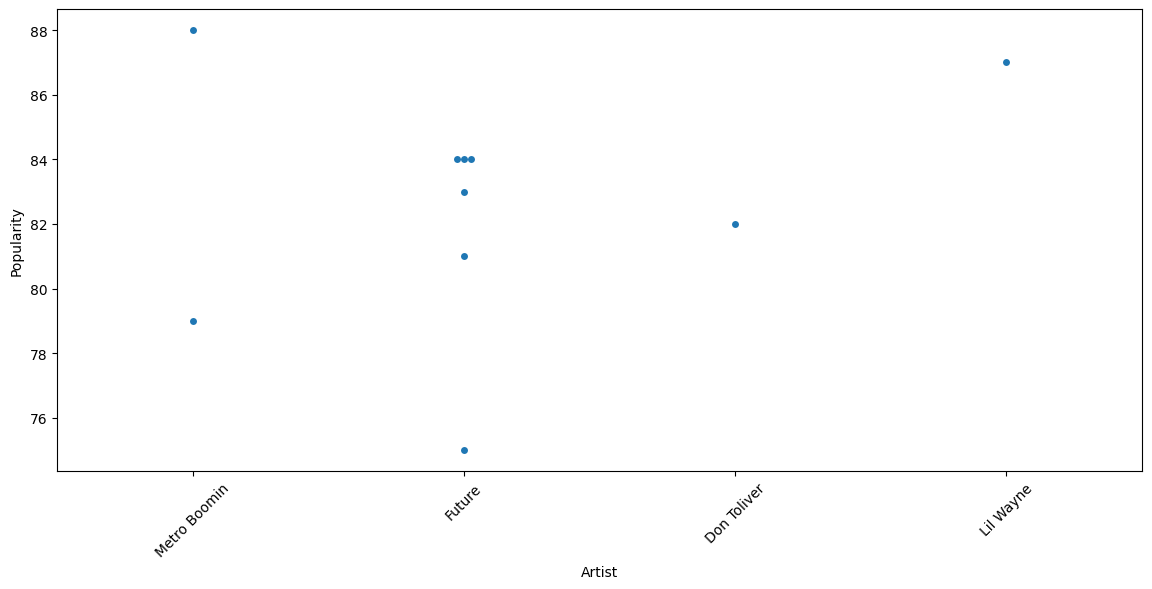

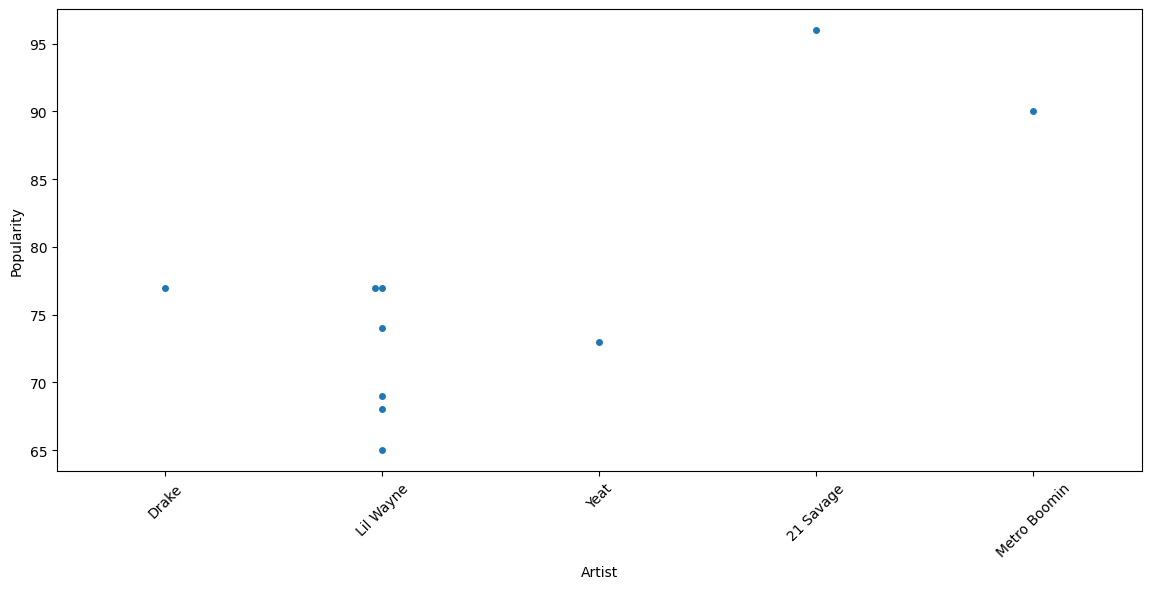

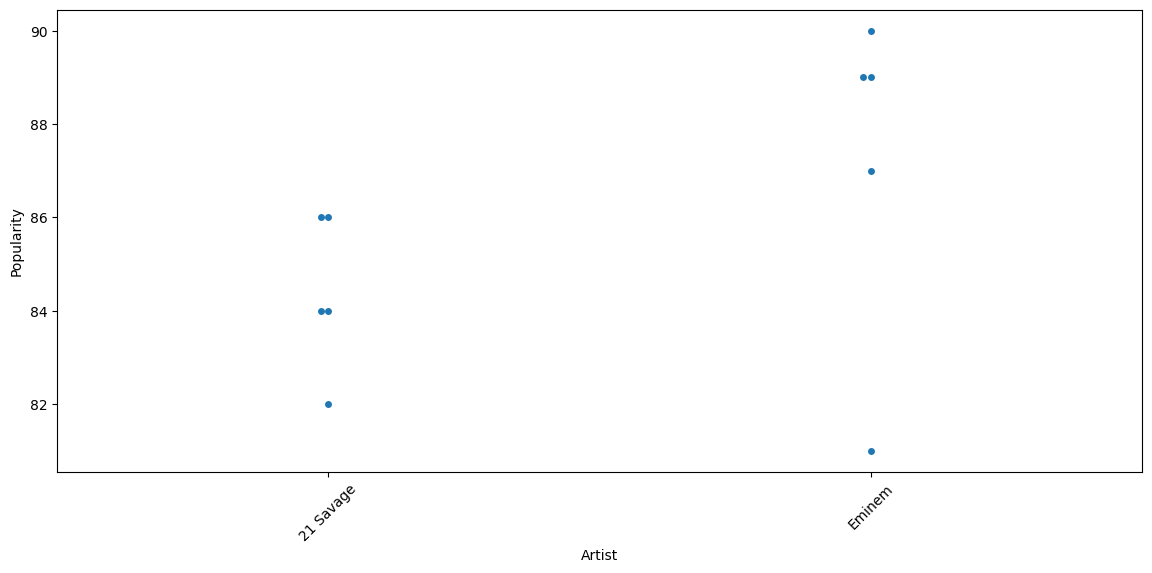

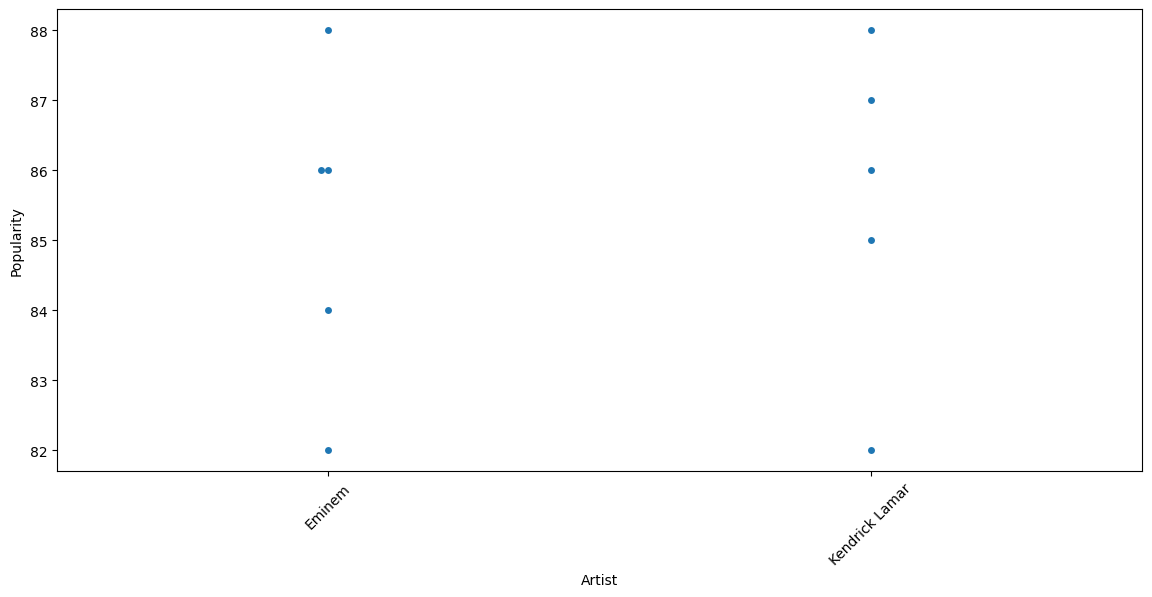

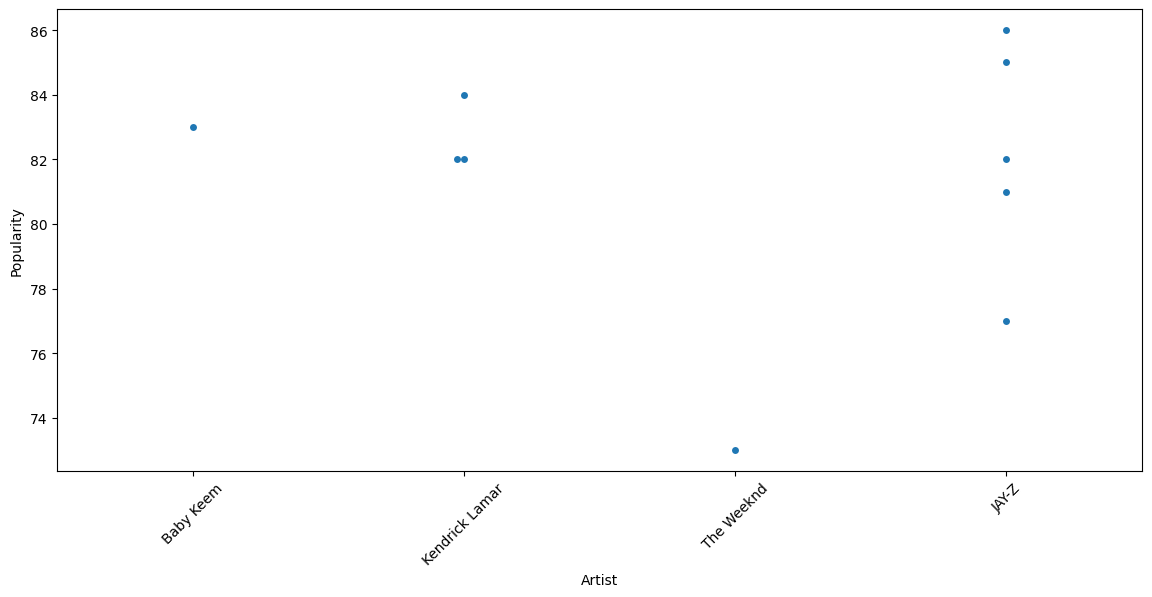

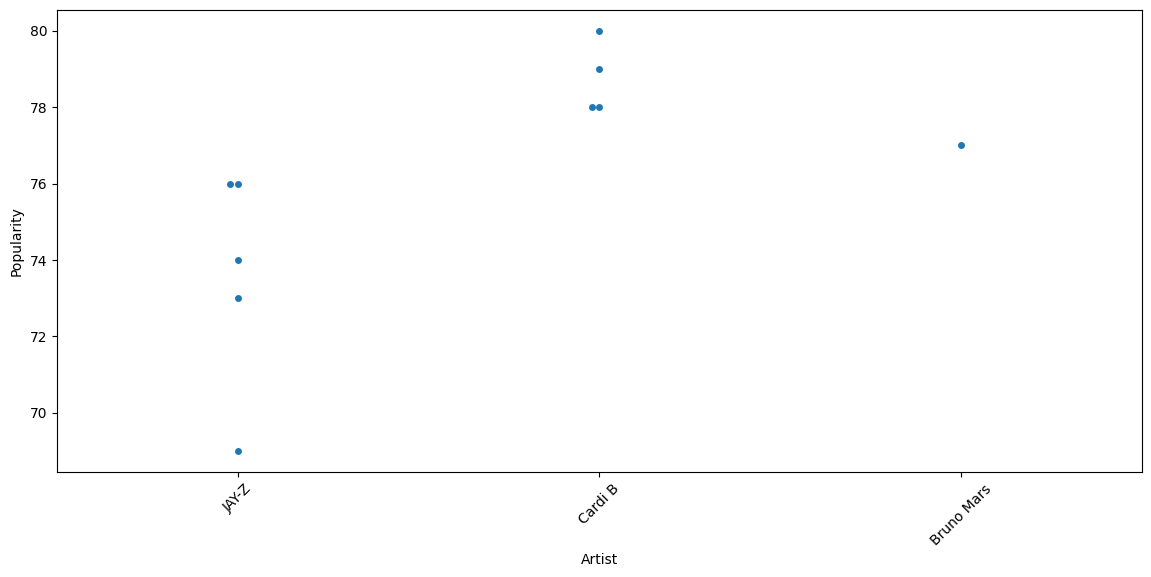

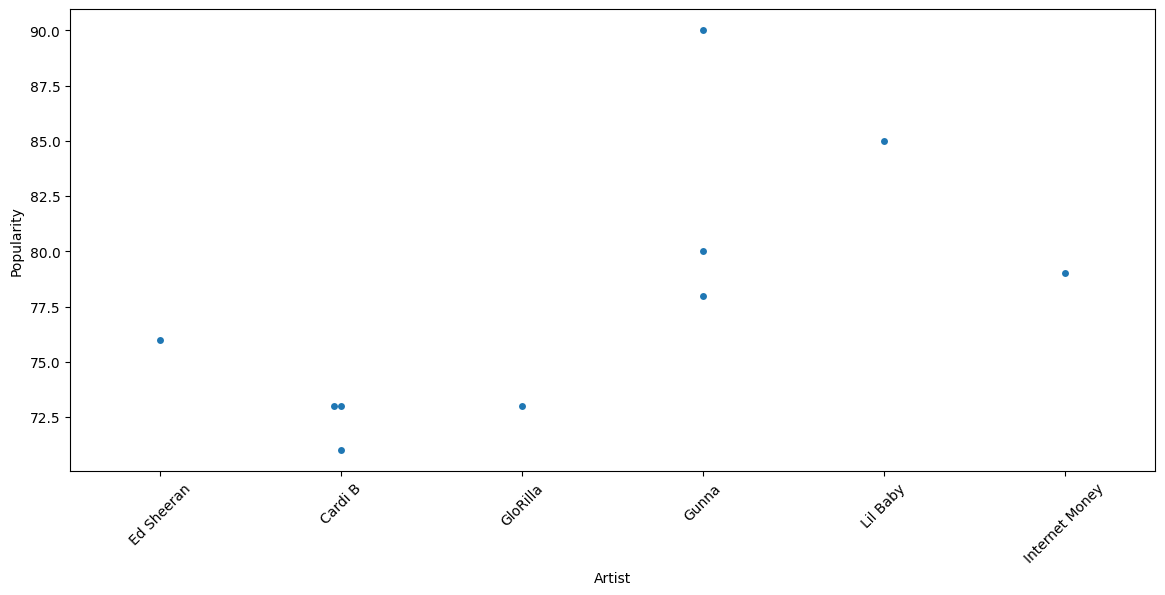

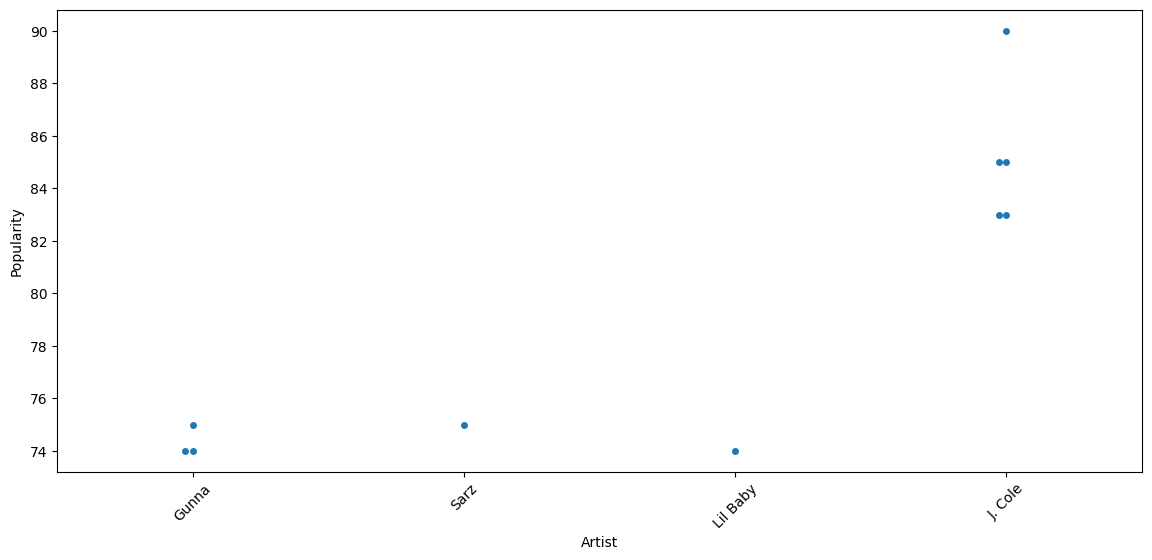

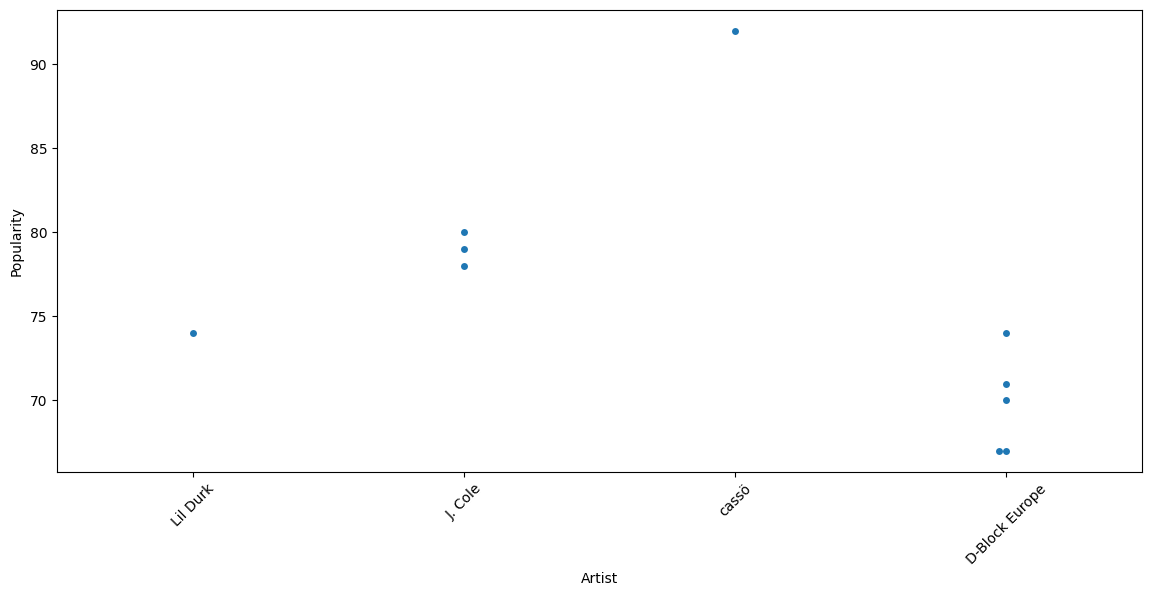

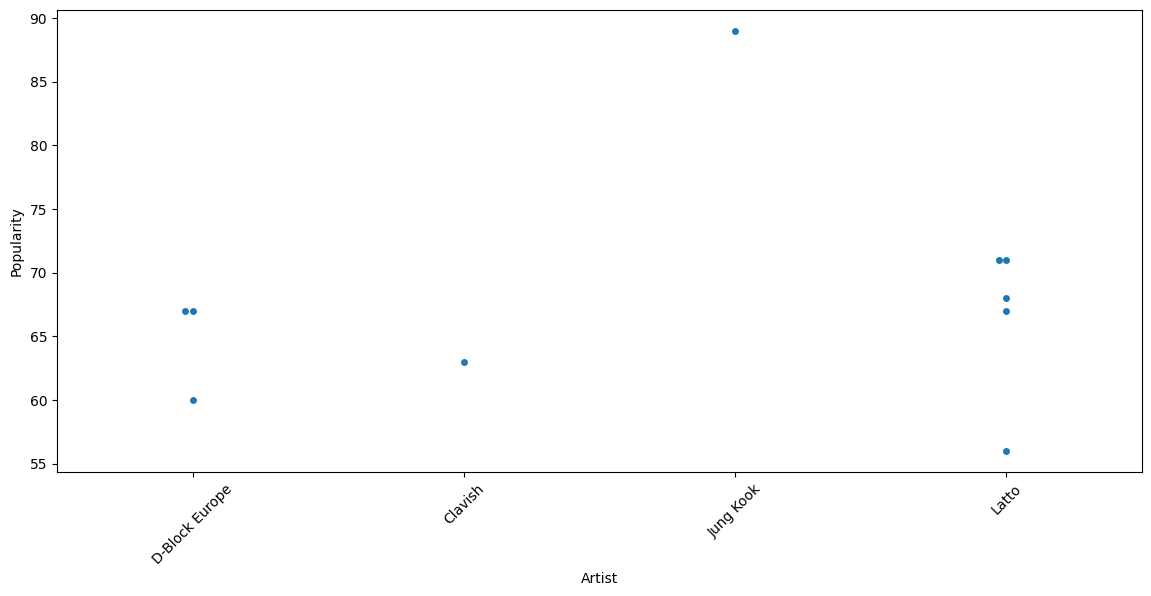

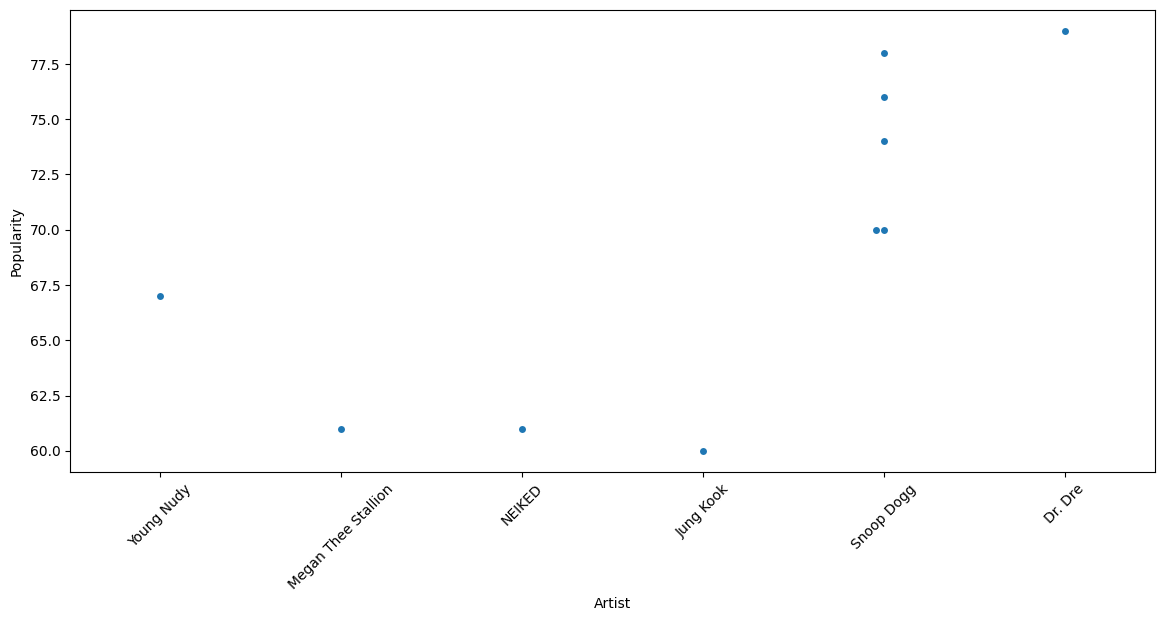

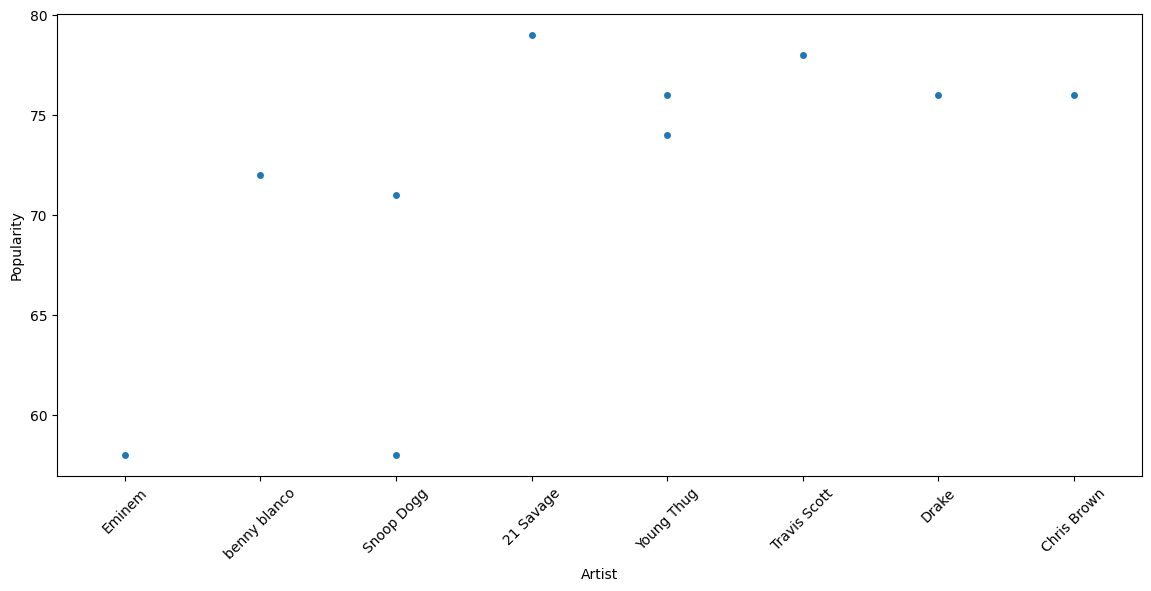

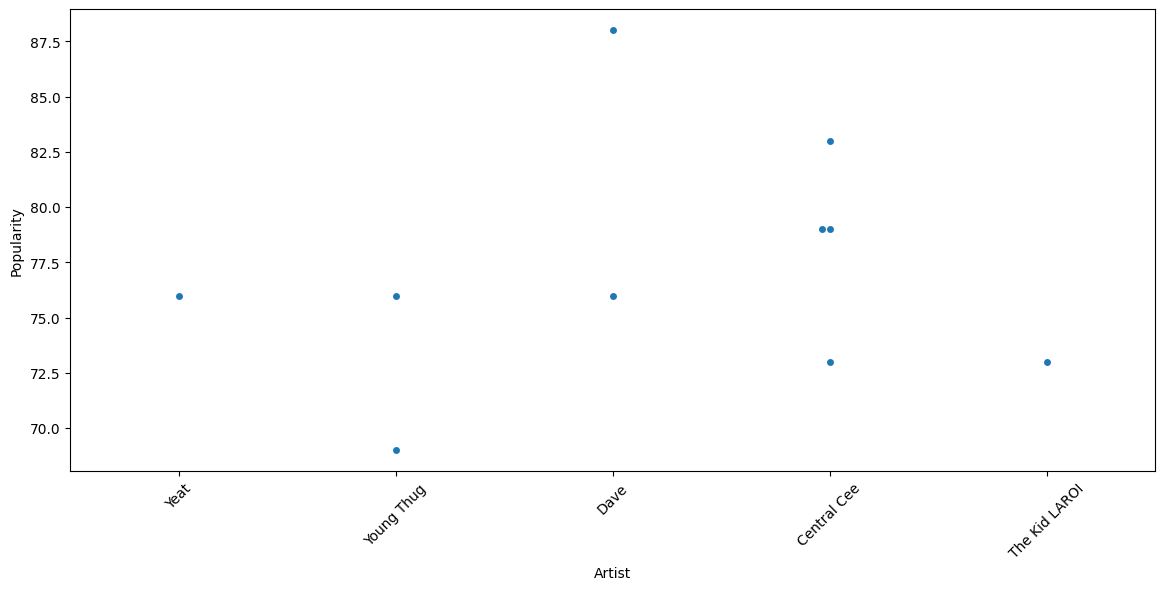

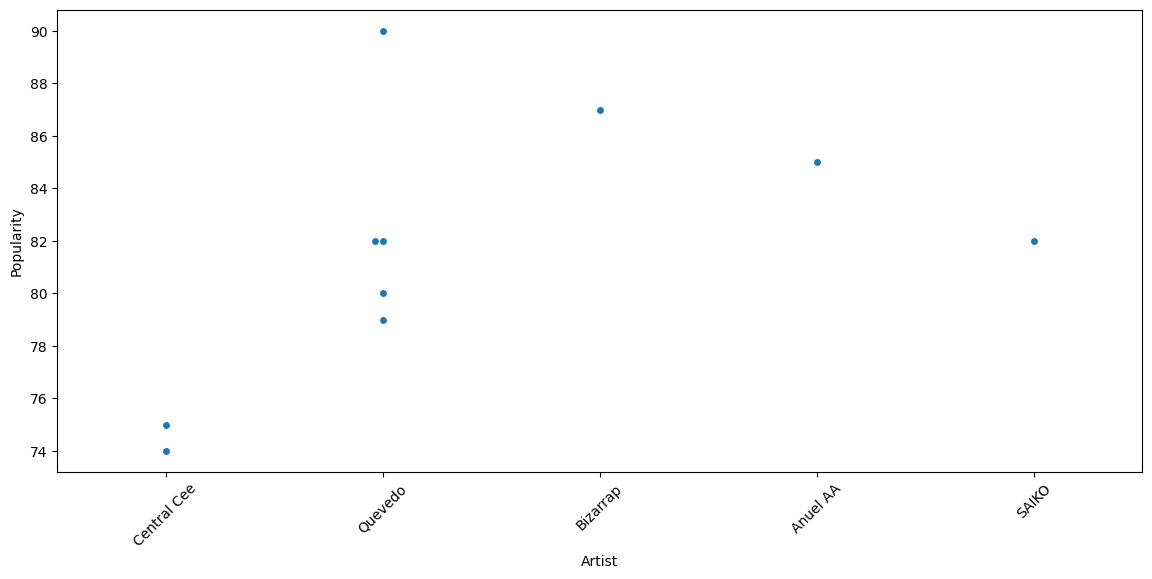

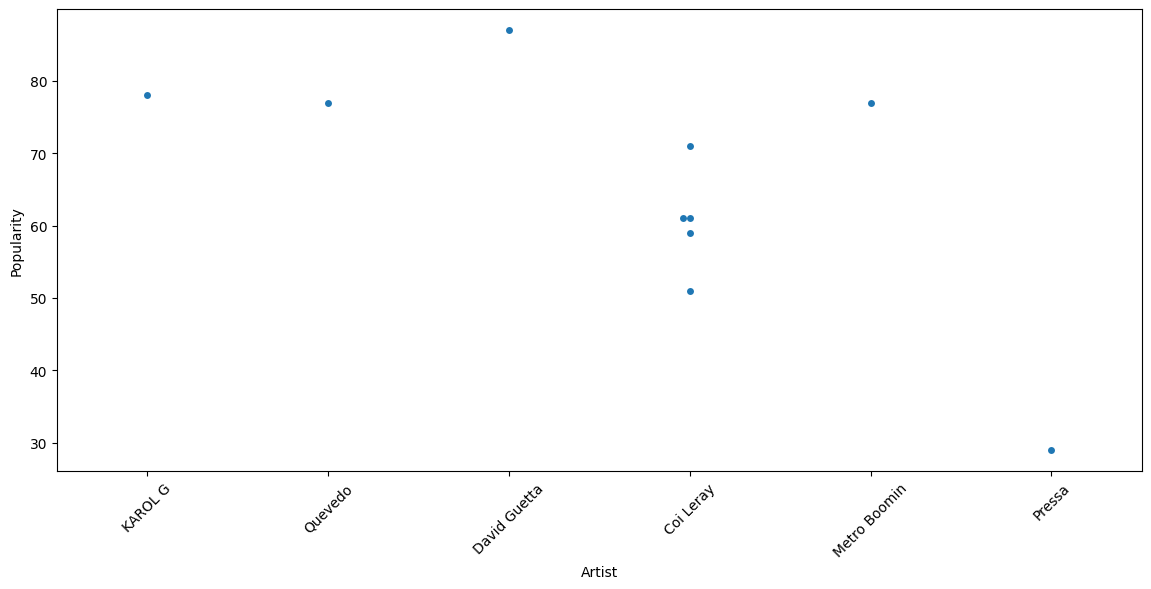

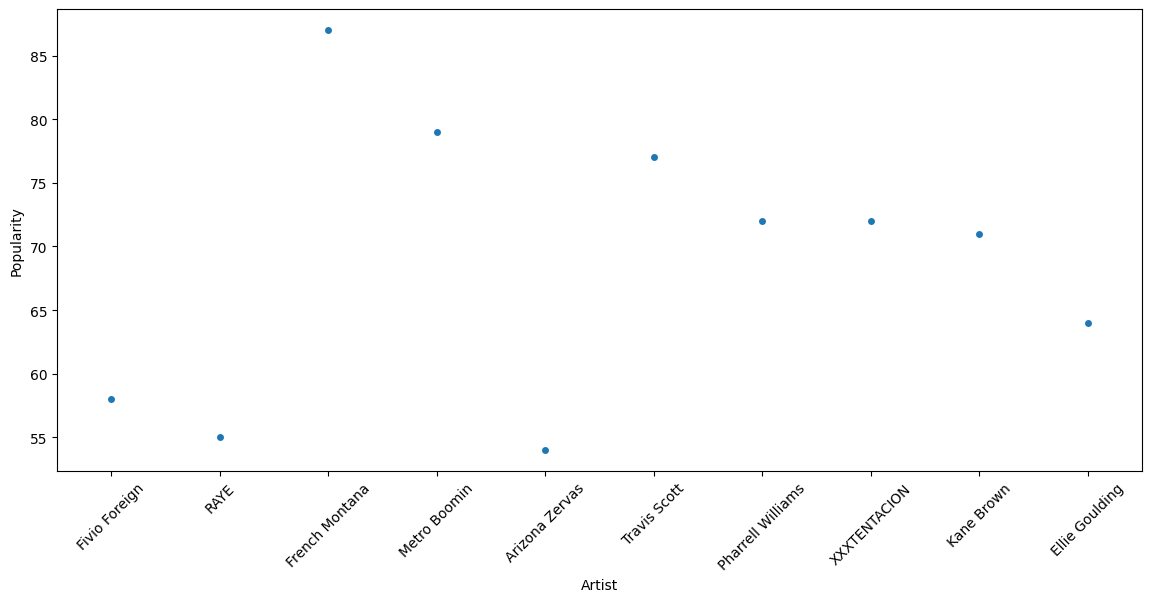

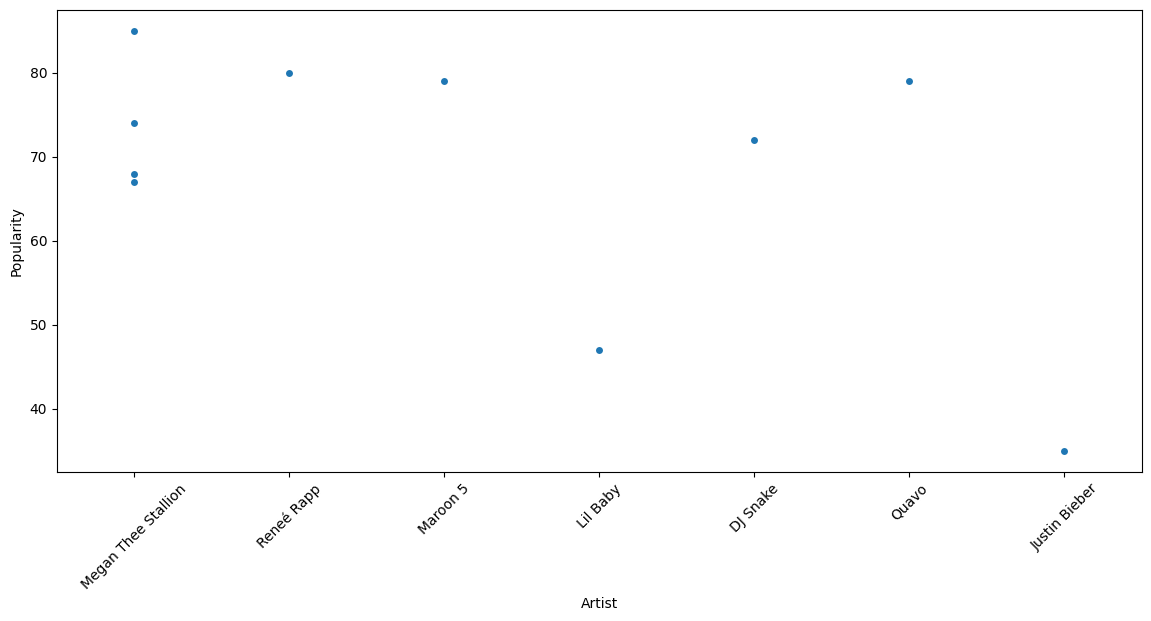

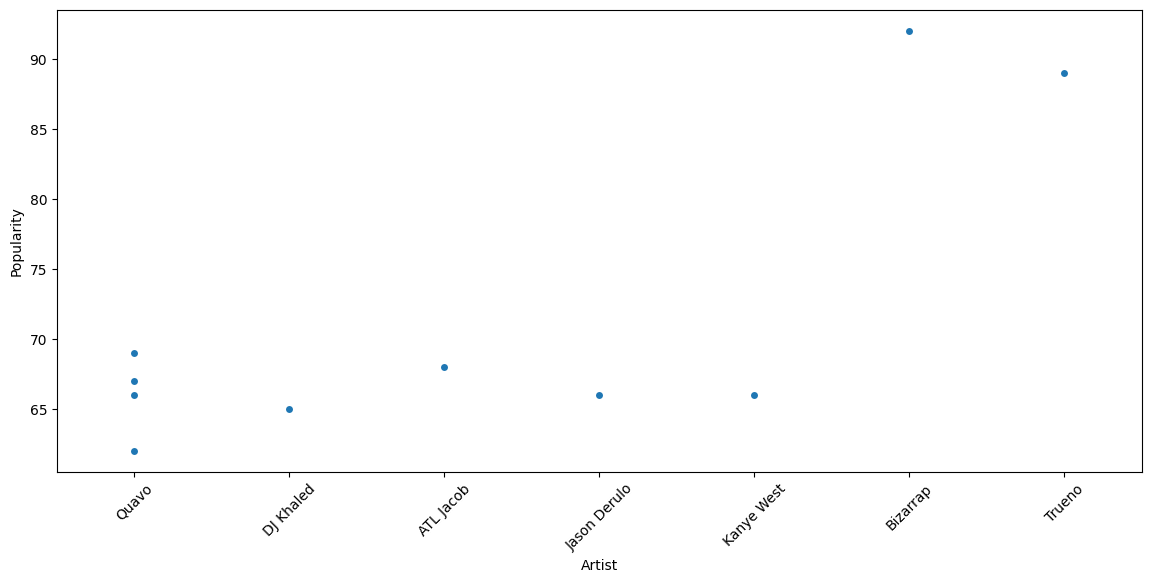

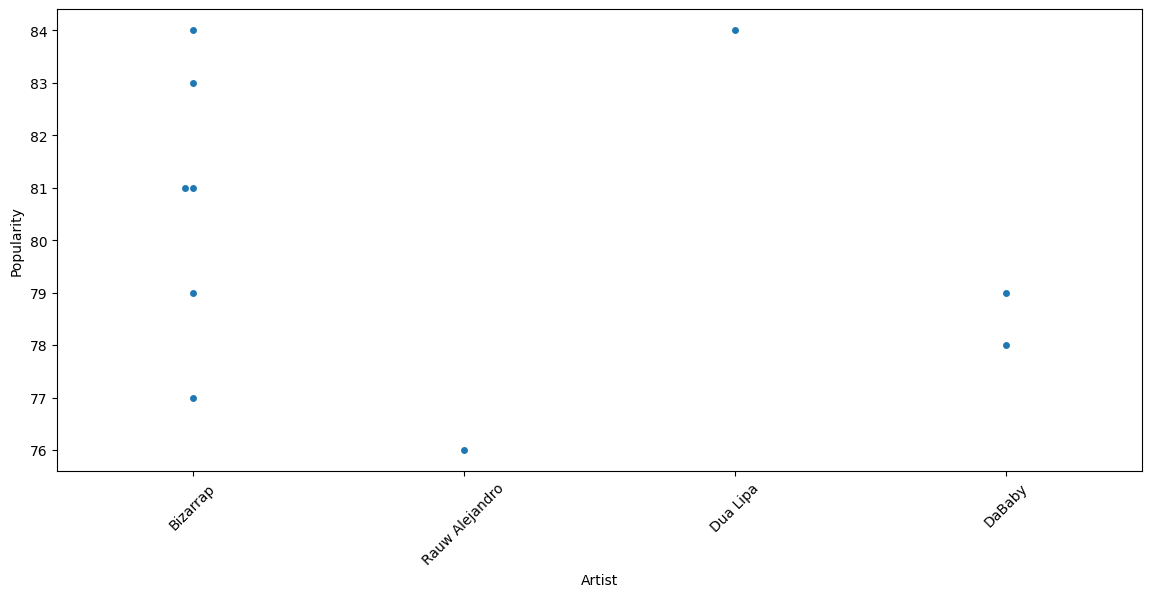

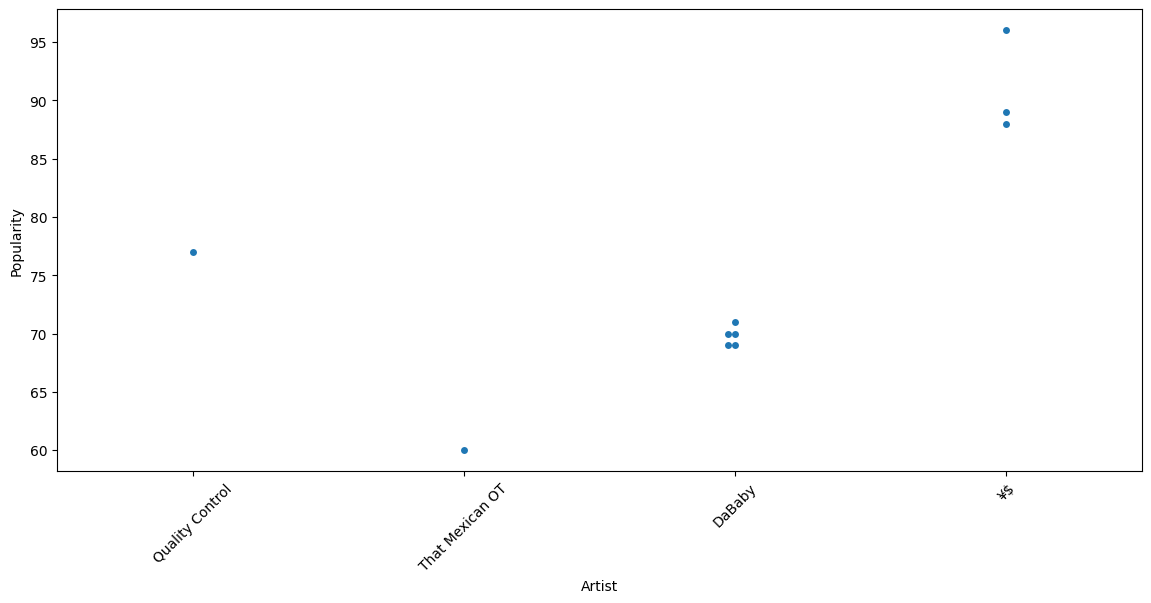

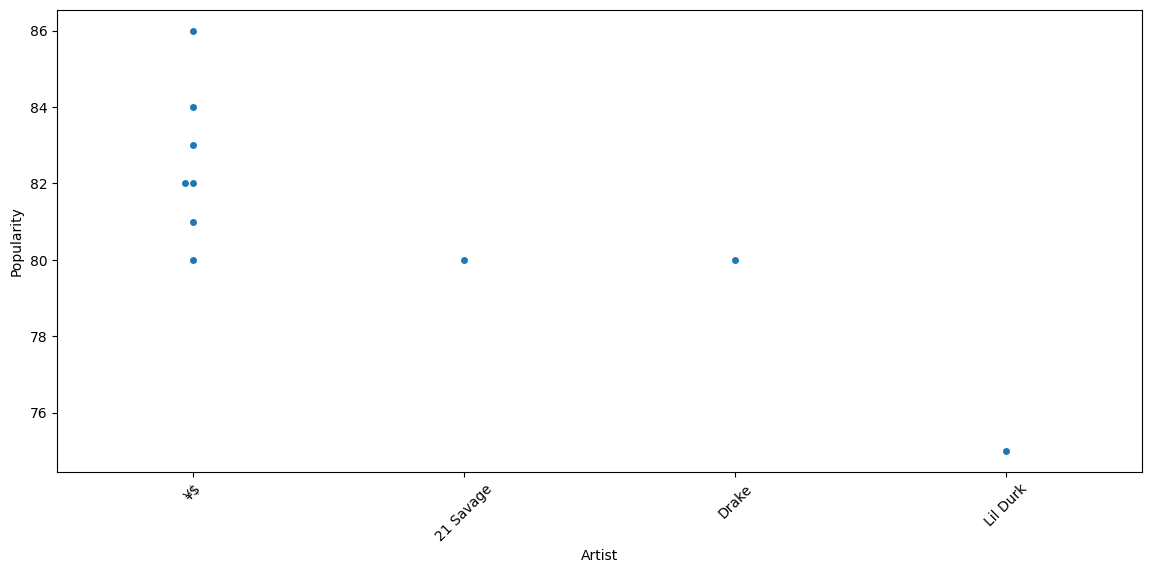

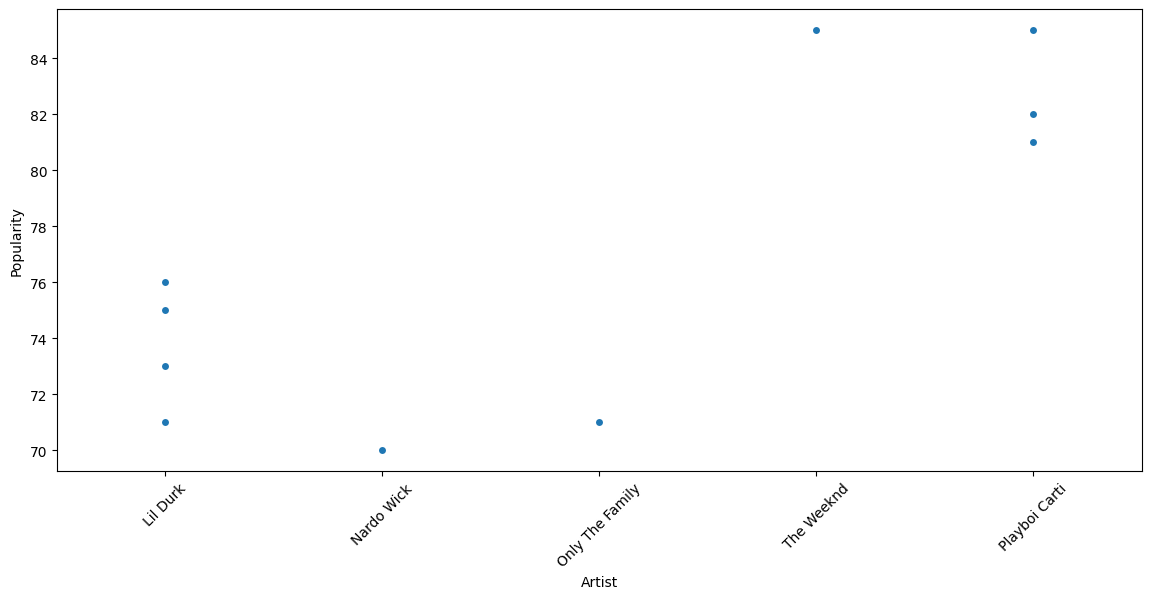

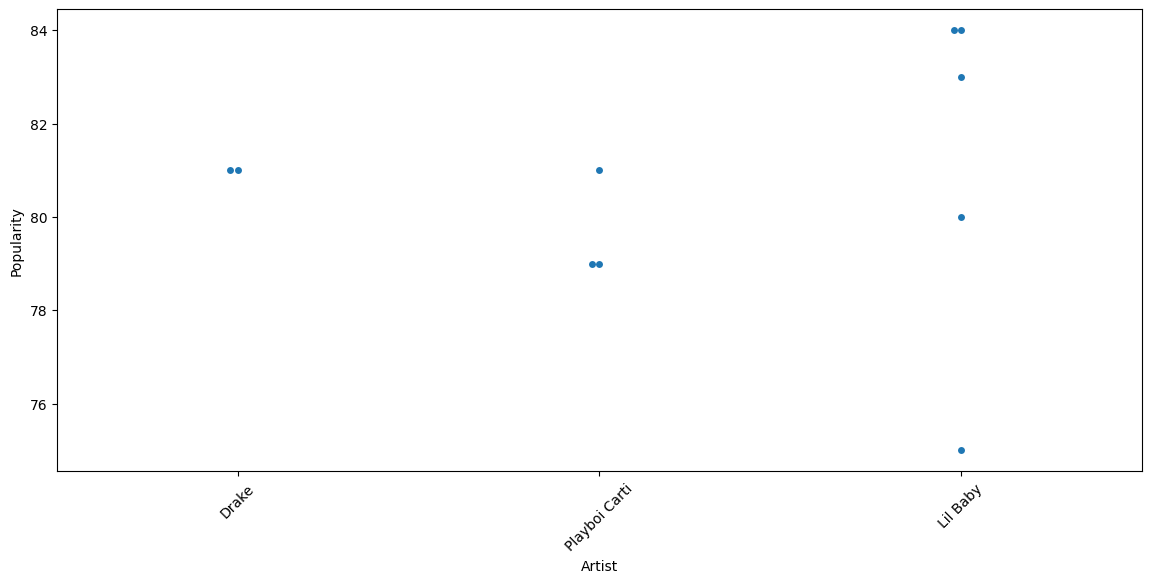

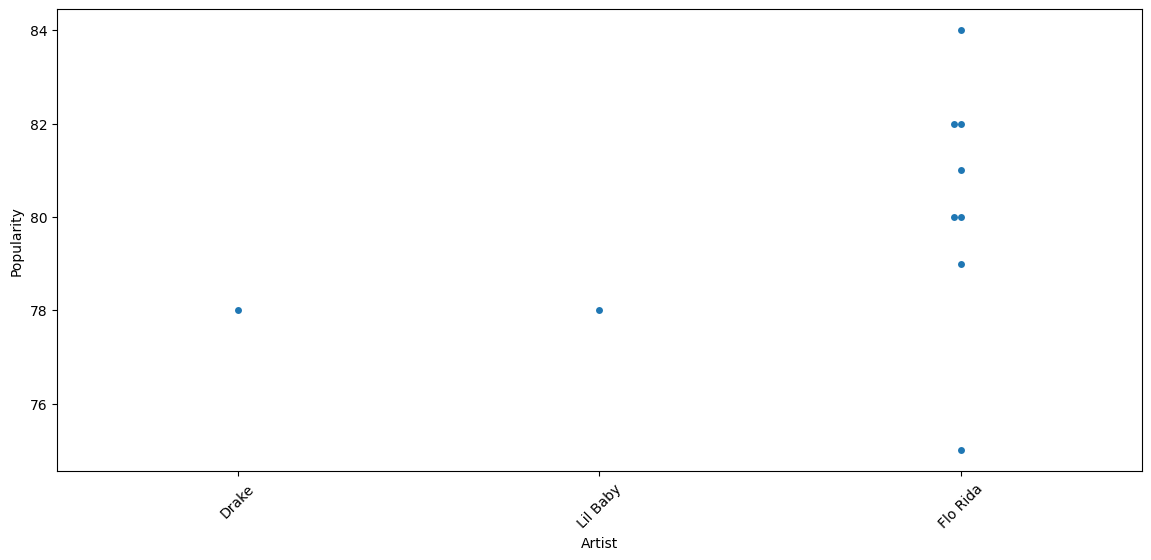

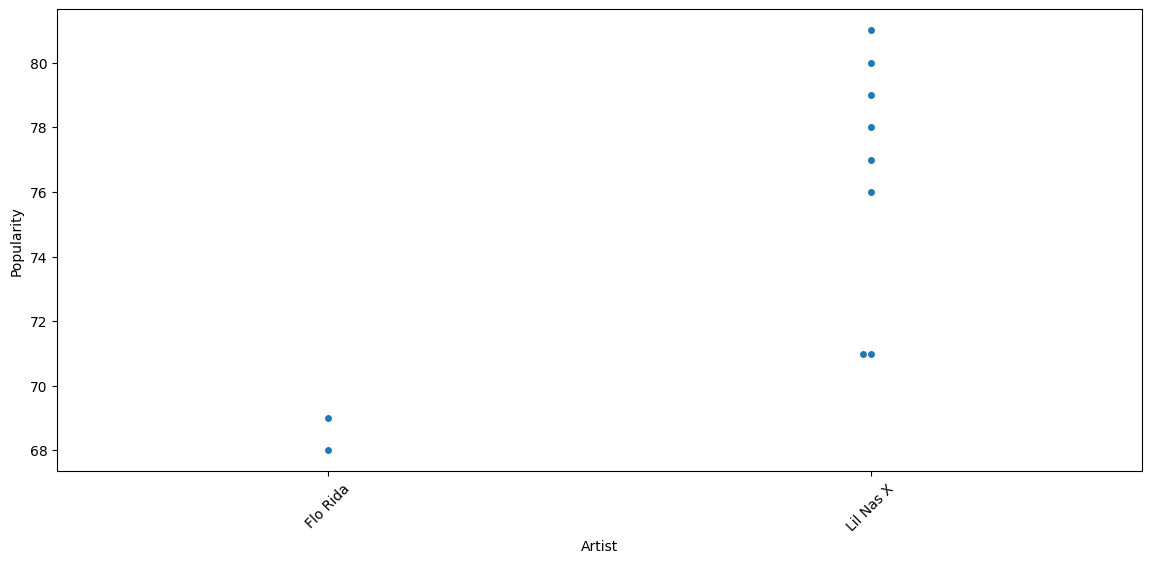

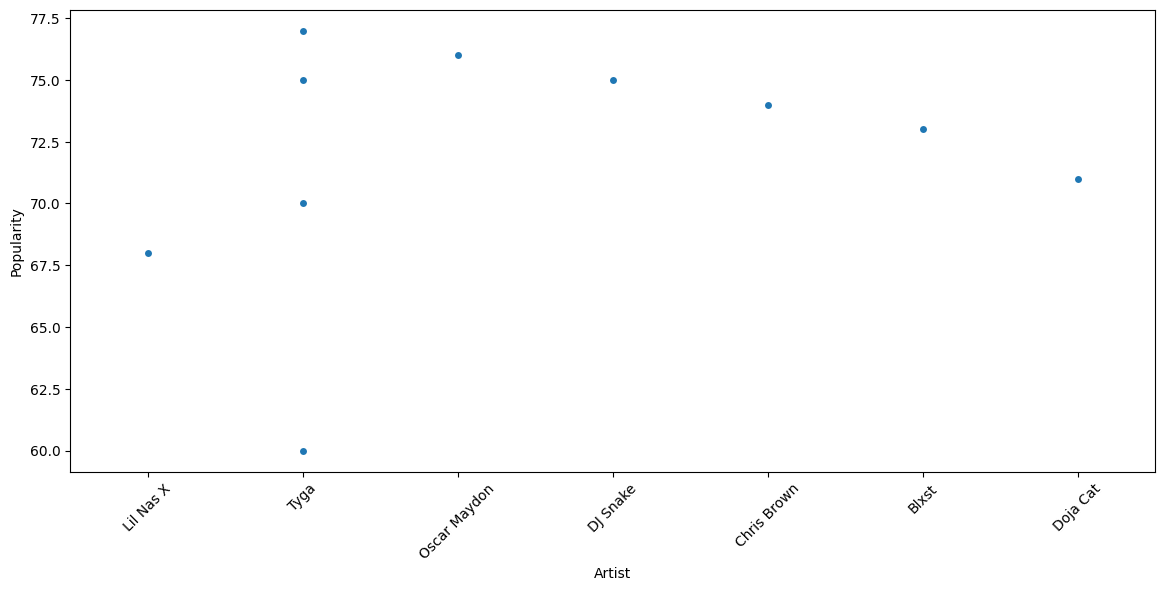

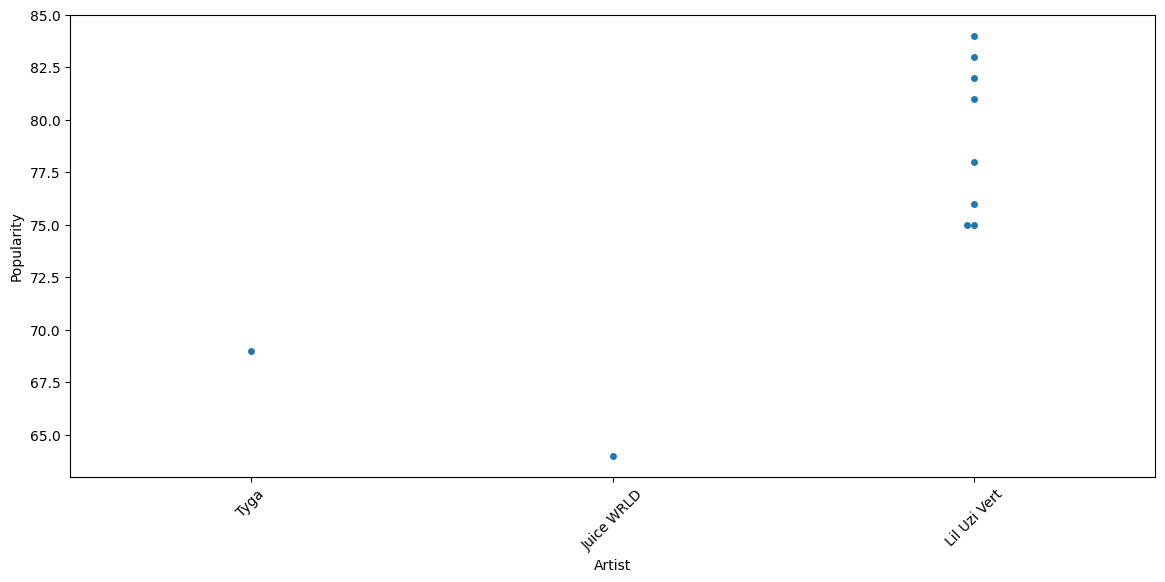

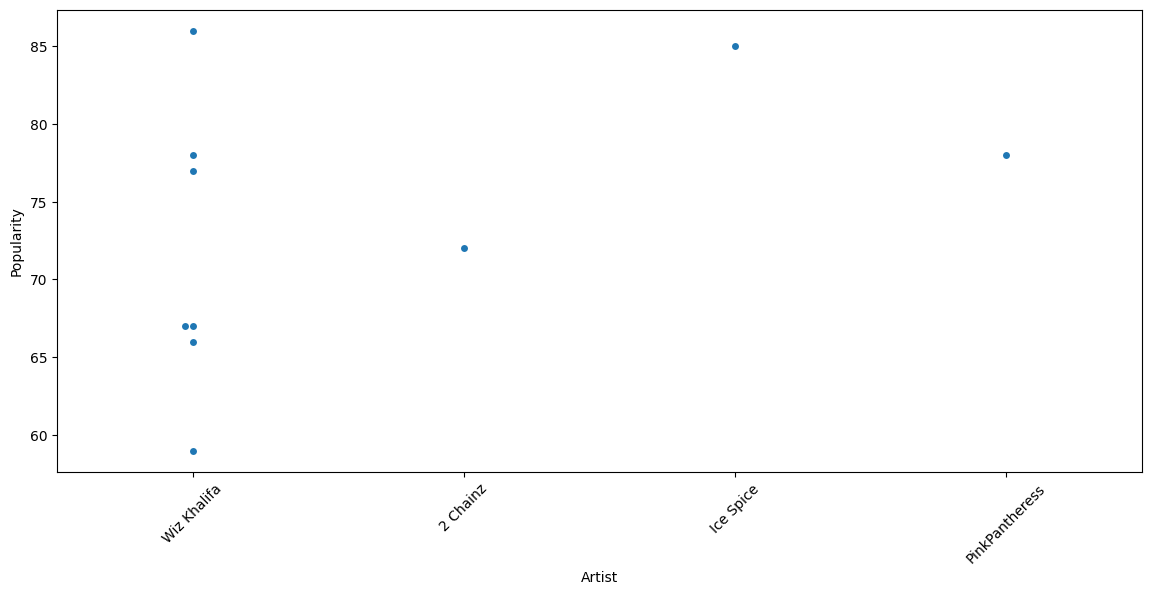

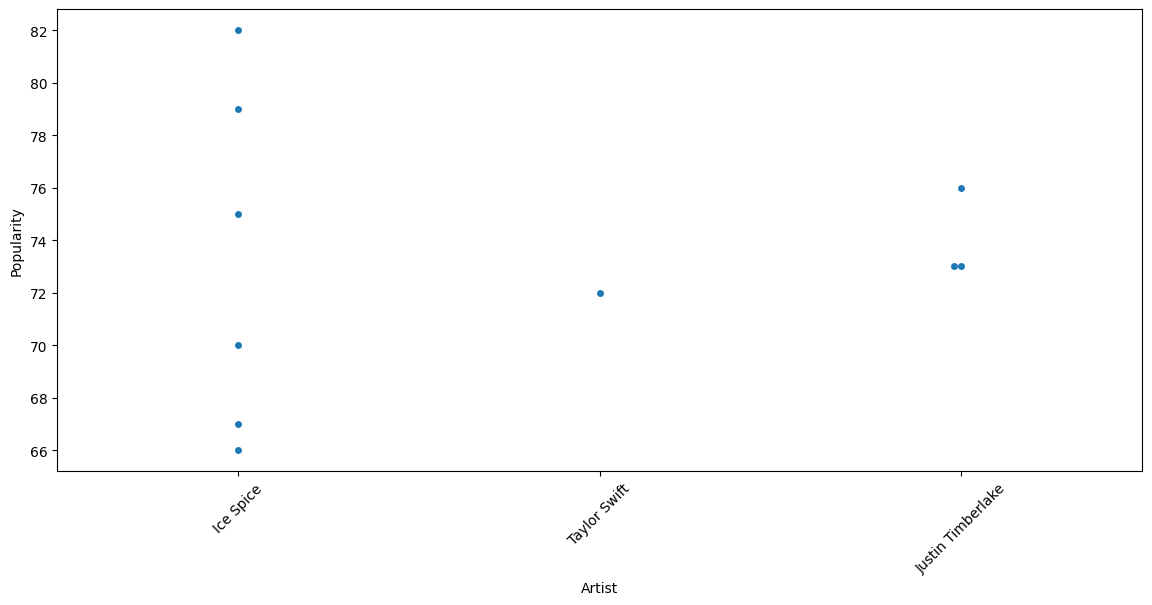

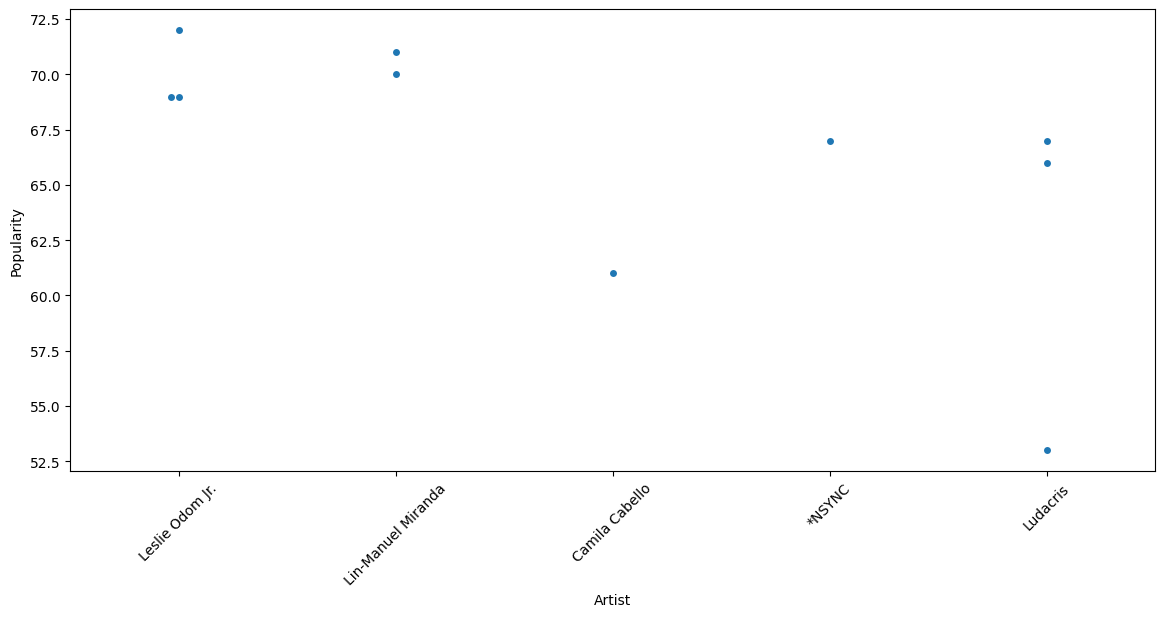

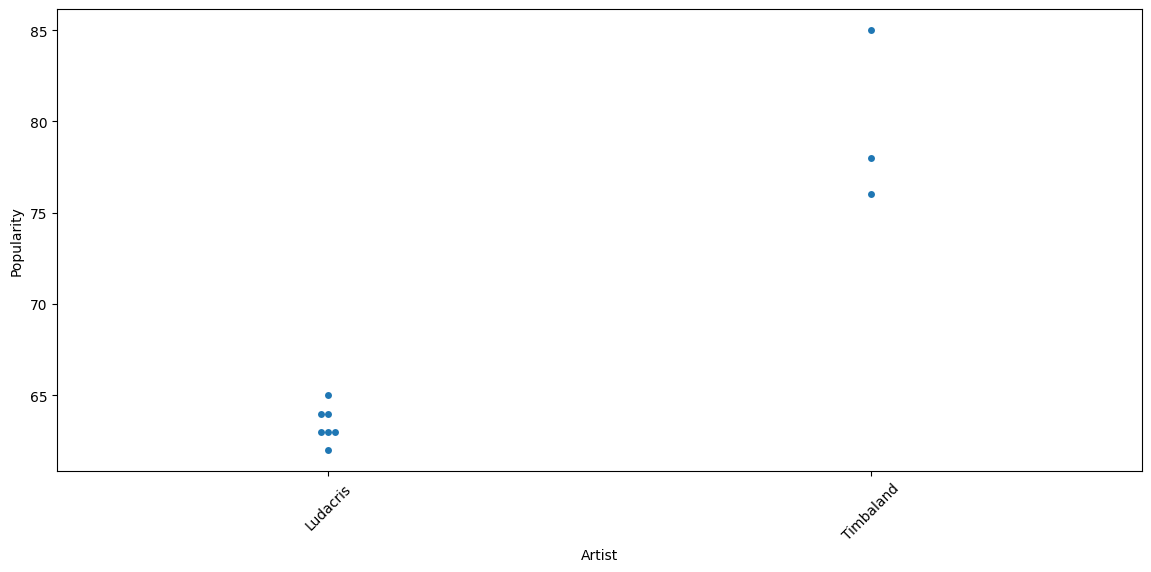

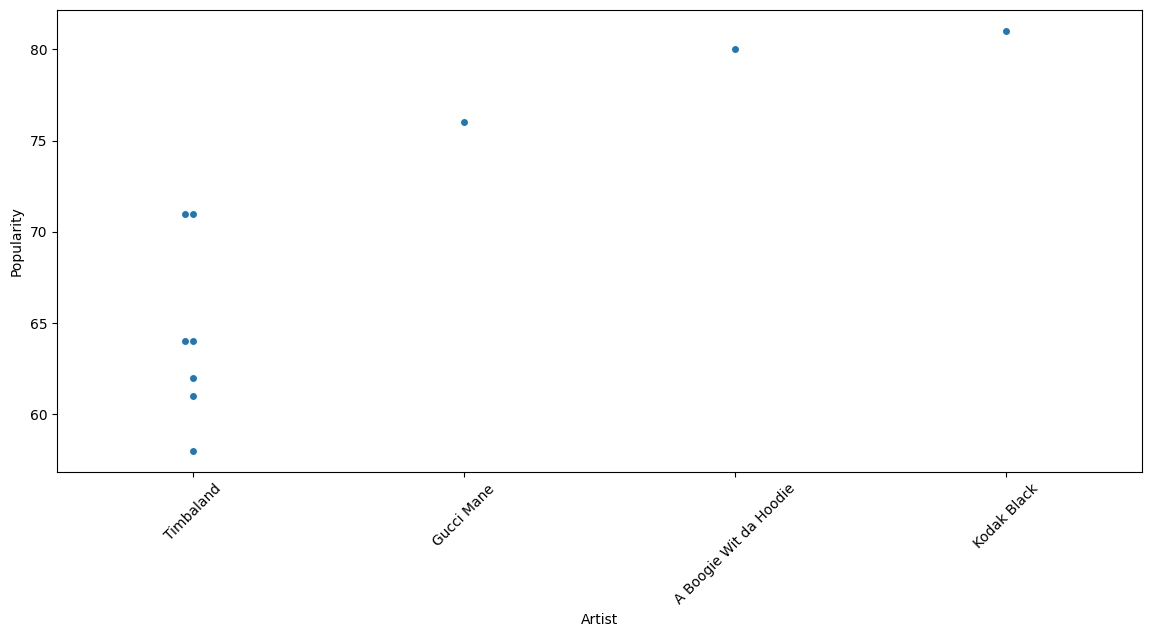

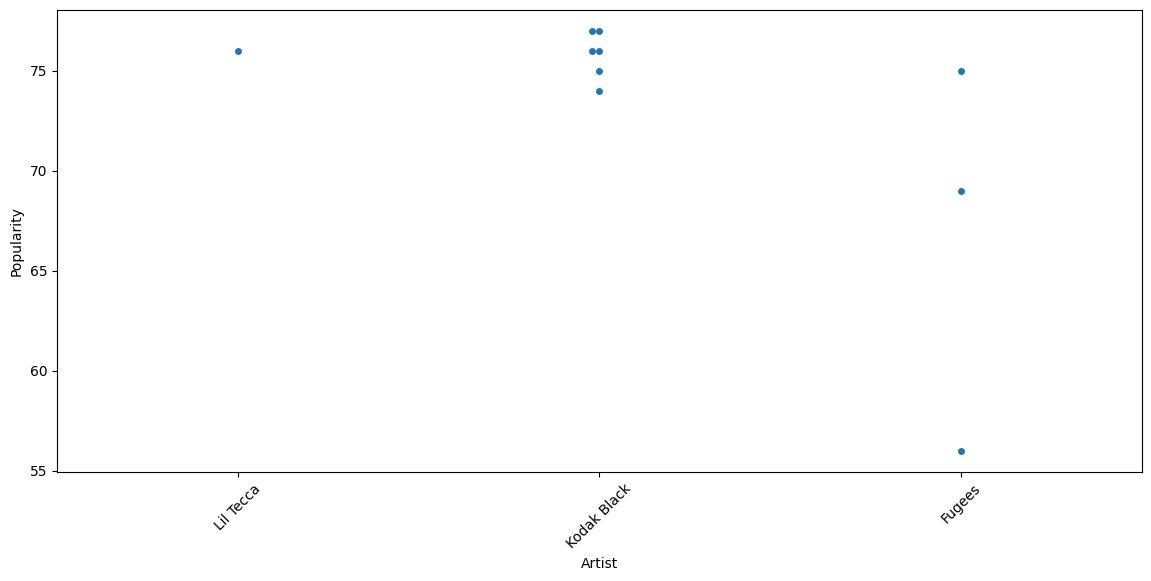

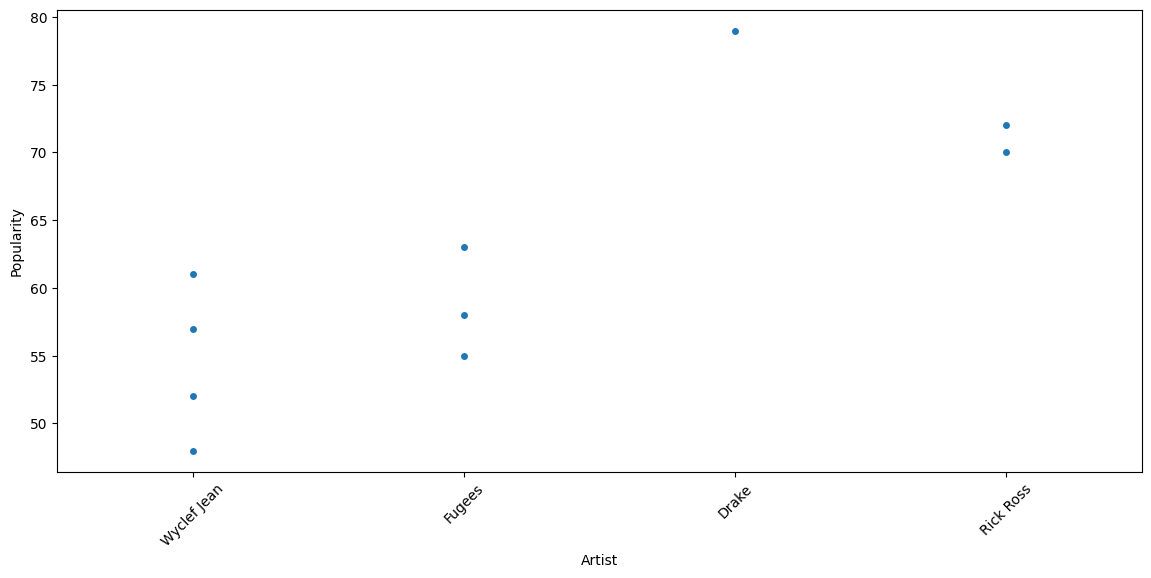

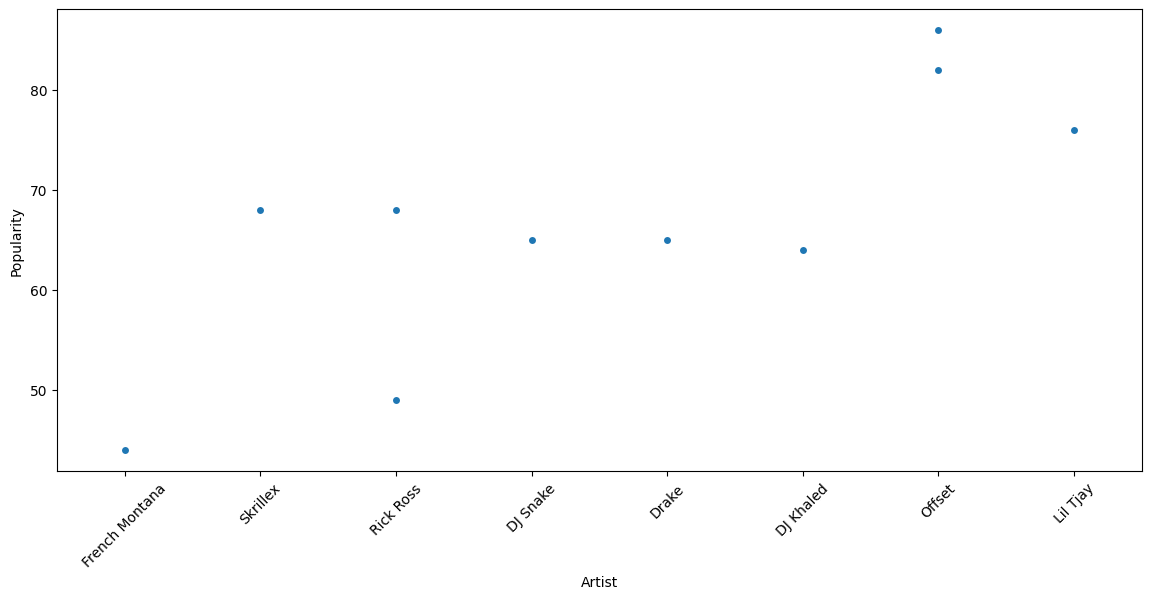

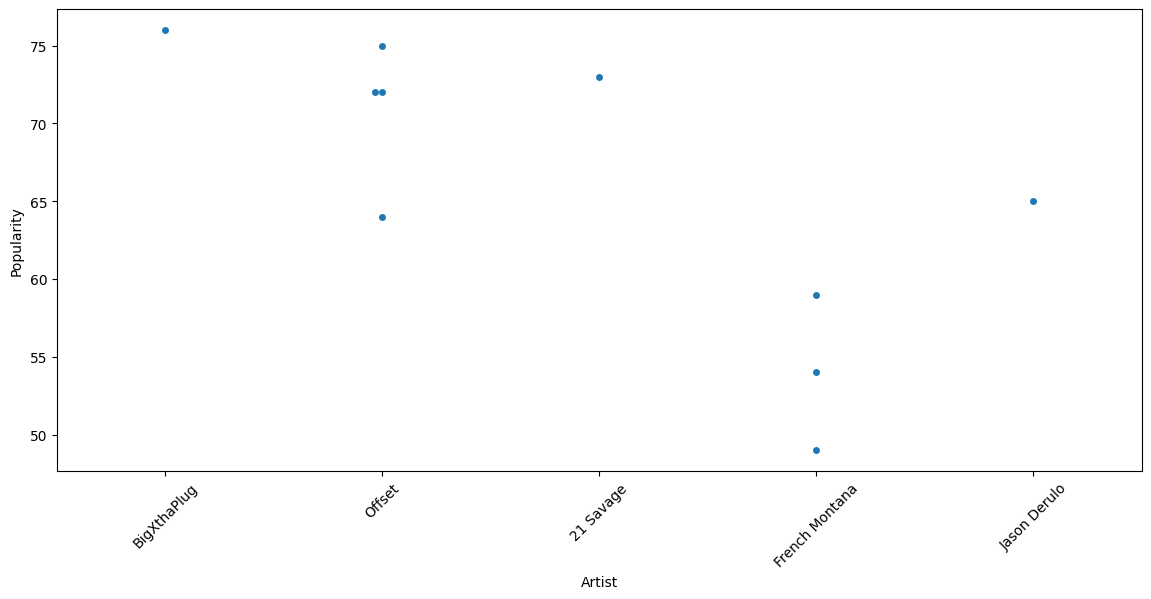

In [70]:
# 10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.
# artist_popularity = spotify_df.groupby("Artist")["Popularity"].mean().sort_values().reset_index()
for i in range(int(len( spotify_df ) / 10 ) ):
  plt.figure(figsize=(14, 6))
  sns.swarmplot(data=spotify_df[i*10: i*10+10], x="Artist", y="Popularity")
  plt.xticks(rotation = 45)
  plt.show()